<a href="https://colab.research.google.com/github/fiapostechfase1/tech-challenge/blob/Gabriel/An%C3%A1lise_exploratoria_de_vinhos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solicitação:

O Head de Dados pediu para que você construísse uma tabela contendo  as seguintes informações:

a. País de origem (Brasil).

b. País de destino.

c. Quantidade em litros de vinho exportado (utilize: 1KG =1L). d. Valor em US$.


# **Exploração das bases de dados da Vitivinicultura**

## Bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

## Funções

In [3]:
#busca nome variável
def nome_da_variavel(variavel):
  """Retorna o nome da variável como string."""
  for nome, valor in globals().items():  # Busca entre as variáveis globais
    if valor is variavel:
      return nome
  return "Variável não encontrada"  # Caso a variável não seja encontrada


In [4]:
#buscar colunas com valores nulos
def get_null_columns(df):
    """
    Returns a list of columns in the DataFrame that contain null values.

    Args:
        df: The input DataFrame.

    Returns:
        A list of column names with null values.
    """
    null_columns = df.columns[df.isnull().any()].tolist()
    return null_columns



In [5]:
#formatação padrão de saída
pd.options.display.float_format = "{:.2f}".format

In [6]:
#selecionando apenas vinho:
#vinho de mesa (elaborados com uvas americanas e/ou híbridas),
#vinho fino de mesa (elaborados com uvas Vitis Vinifera L.),
#vinho especial (corte de vinho de mesa e fino de mesa),

filtro_vinho = [
    'vinho_mesa_tinto',
    'vinho_mesa_branco',
    'vinho_mesa_rosado',
    'vinho_fino_mesa_tinto',
    'vinho_fino_mesa_branco',
    'vinho_fino_mesa_rosado',
    #'vinho_especial_tinto',
    #'vinho_especial_branco',
    #'vinho_especial_rosado',
    #'vinho_organico',
    ]



## Dados

In [7]:
#dataframe sobre a comercilização de vinhos e derivados
df_comercio = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/comercio.csv', sep = ';')
df_imp_espumantes = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/imp_espumantes.csv', sep = '\t')
df_imp_vinhos = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/imp_vinhos.csv', sep = '\t')
df_exp_espumantes = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/exp_espumantes.csv', sep = '\t')
df_exp_vinhos = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/exp_vinho.csv', sep = '\t')
df_producao = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/producao_vitibrasil.csv', sep = ';')


##Exploração base comércio

### Informações da Base

In [8]:
print(f'Tamanho do dataset {nome_da_variavel(df_comercio)}: {df_comercio.shape}')

Tamanho do dataset df_comercio: (62, 57)


In [9]:
df_comercio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 57 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       62 non-null     int64 
 1   control  61 non-null     object
 2   Produto  62 non-null     object
 3   1970     62 non-null     int64 
 4   1971     62 non-null     int64 
 5   1972     62 non-null     int64 
 6   1973     62 non-null     int64 
 7   1974     62 non-null     int64 
 8   1975     62 non-null     int64 
 9   1976     62 non-null     int64 
 10  1977     62 non-null     int64 
 11  1978     62 non-null     int64 
 12  1979     62 non-null     int64 
 13  1980     62 non-null     int64 
 14  1981     62 non-null     int64 
 15  1982     62 non-null     int64 
 16  1983     62 non-null     int64 
 17  1984     62 non-null     int64 
 18  1985     62 non-null     int64 
 19  1986     62 non-null     int64 
 20  1987     62 non-null     int64 
 21  1988     62 non-null     int64 
 22  1989

 Valores nulos

In [10]:
#Quantidade de valores nulos
print(f'Quantidade de dados nulos: {df_comercio.isnull().sum().sum()}')

Quantidade de dados nulos: 1


In [11]:
# Chama funcao para buscar as colunas com valores nulos
null_cols = get_null_columns(df_comercio)
print(f"Columns with null values: {null_cols}")

Columns with null values: ['control']


In [12]:
# Select rows with null values in specific columns
null_rows = df_comercio[df_comercio[null_cols].isnull().any(axis=1)]
print(null_rows)

    id control                          Produto      1970      1971      1972  \
25  26     NaN  OUTROS PRODUTOS COMERCIALIZADOS  19844550  20351384  23615205   

        1973      1974      1975      1976  ...      2014      2015      2016  \
25  25401454  24530878  23102540  28321777  ...  34963296  31922948  27120309   

        2017      2018      2019      2020      2021      2022      2023  
25  28027052  31246158  34794651  26547242  26657930  31704382  29889342  

[1 rows x 57 columns]


In [13]:
print(df_comercio)

    id               control                       Produto      1970  \
0    1         VINHO DE MESA                 VINHO DE MESA  98327606   
1    2              vm_Tinto                         Tinto  83300735   
2    3             vm_Rosado                        Rosado    107681   
3    4             vm_Branco                        Branco  14919190   
4    5   VINHO  FINO DE MESA           VINHO  FINO DE MESA   4430629   
..  ..                   ...                           ...       ...   
57  58         ou_Vinho_base    Vinho base para espumantes         0   
58  59     ou_Vinho_composto                Vinho composto   3386173   
59  60     ou_Vinho_licoroso                Vinho licoroso   3013056   
60  61         ou_Vinho_leve                    Vinho leve         0   
61  62  ou_Vinho_gaseificado             Vinho gaseificado         0   

         1971       1972       1973      1974       1975       1976  ...  \
0   114399031  118377367  116617910  94173324  108031792  1

Valores únicos

In [14]:
#valores únicos
df_comercio.nunique()

,0
id,62
control,58
Produto,56
1970,27
1971,27
1972,27
1973,27
1974,28
1975,28
1976,29


Estatistica Básica

In [15]:
df_comercio.describe().style.format("{:.2f}")

,id,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00,62.00
mean,31.50,4285389.69,4852291.68,5172138.81,5313005.58,4481220.48,5016925.63,6458908.94,6498990.21,6619527.85,7124848.24,5855982.89,5864327.79,7124695.48,8155435.39,7775441.66,8292166.34,9261813.74,6478938.42,7218360.39,8127394.66,7466606.69,8275585.19,7854117.08,9069200.56,8364186.21,7054136.81,7988111.19,8627906.69,8351866.87,9352617.21,9937120.84,9650371.74,9683786.32,9238406.79,9699084.47,11469609.39,10541473.53,9938908.74,9370096.47,10960489.56,10375917.13,10847644.94,10380151.44,11626082.74,11084658.15,11489827.16,9416294.85,9850568.58,10461880.74,13447368.79,14400380.56,14773220.19,14390021.53,14578660.32
std,18.04,16359754.09,19099153.93,19691291.58,19310934.04,15530421.21,17932187.64,22981715.98,23129220.19,23260127.88,24302577.35,20042938.87,20630348.27,26901134.26,31367464.54,27537395.77,29672554.91,32685323.19,21106907.25,24421968.42,28499873.44,26315270.86,30321320.38,29088941.39,32814903.54,29427555.62,23714702.93,26745856.37,28128409.20,28862743.00,32135877.82,35704670.31,35945079.82,36826315.33,35557614.74,36880523.13,44685145.37,40690898.98,37373993.90,33449072.43,38609159.55,36883602.37,38539834.08,34748250.96,37876890.36,36058896.55,37614328.08,30157122.12,32198775.72,34194519.73,38323443.64,42045619.34,41593781.74,39205023.74,40386573.01
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,16.25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,20.50,2856.75,1953.25,2379.75,4161.75,2377.50
50%,31.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9611.00,0.00,2560.50,0.00,0.00,0.00,19281.50,59406.50,200649.00,148336.50,122871.50,51040.50,29035.00,56751.00,124616.00,81295.00,96060.00,80673.00,119040.50,66048.50,55967.00,121457.00,338717.50,198860.50,328257.50,294542.00,378391.00
75%,46.75,1220419.75,1219804.50,1819606.50,2034499.75,1845616.50,2186431.75,3285852.50,3494149.50,3399996.75,3342688.25,3669343.50,2622074.50,2428982.00,2375446.75,2277346.00,2048252.25,2454831.25,2285322.00,2150472.75,1780204.25,1440876.25,1351680.75,1068522.75,1460518.75,1495391.50,1504792.75,1980298.75,2404674.75,2429900.75,2467302.25,3295309.25,1956150.50,2067700.25,2615149.75,3291636.75,3190139.50,2825585.25,2316665.75,2614861.25,2872296.00,3238676.00,3288837.50,3923090.75,3645965.75,3906140.25,3343750.00,2935857.50,2694804.50,3332817.50,5321690.00,5815971.25,5620649.50,5221489.25,4773561.00
max,62.00,98327606.00,114399031.00,118377367.00,116617910.00,94173324.00,108031792.00,139238614.00,140813114.00,141293379.00,149609112.00,122825298.00,128894580.00,166861772.00,195616620.00,171619507.00,185191837.00,203130018.00,131065191.00,150678647.00,172921267.00,164725646.00,190134895.00,180230431.00,201168480.00,180295366.00,146583828.00,165831436.00,174768638.00,181576649.00,200578746.00,221023603.00,221518224.00,227447392.00,217082959.00,225021830.00,271248493.00,245625614.00,226710045.00,200488612.00,234525979.00,221242945.00,230310468.0

In [16]:
df_comercio.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
id,62.00,31.50,18.04,1.00,16.25,31.50,46.75,62.00
1970,62.00,4285389.69,16359754.09,0.00,0.00,0.00,1220419.75,98327606.00
1971,62.00,4852291.68,19099153.93,0.00,0.00,0.00,1219804.50,114399031.00
1972,62.00,5172138.81,19691291.58,0.00,0.00,0.00,1819606.50,118377367.00
1973,62.00,5313005.58,19310934.04,0.00,0.00,0.00,2034499.75,116617910.00
1974,62.00,4481220.48,15530421.21,0.00,0.00,0.00,1845616.50,94173324.00
1975,62.00,5016925.63,17932187.64,0.00,0.00,0.00,2186431.75,108031792.00
1976,62.00,6458908.94,22981715.98,0.00,0.00,0.00,3285852.50,139238614.00
1977,62.00,6498990.21,23129220.19,0.00,0.00,0.00,3494149.50,140813114.00
1978,62.00,6619527.85,23260127.88,0.00,0.00,0.00,3399996.75,141293379.00


### Transformação base Comércio



In [17]:
df_comercio.tail()

,id,control,Produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
57,58,ou_Vinho_base,Vinho base para espumantes,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
58,59,ou_Vinho_composto,Vinho composto,3386173,3645774,3921573,4168841,3670736,3493104,5429800,...,450121,413735,377685,485944,249165,366549,63625,227116,32000,981
59,60,ou_Vinho_licoroso,Vinho licoroso,3013056,2475632,2407816,2443944,1921867,2205036,2474364,...,616904,510975,546189,496746,491165,465964,362340,376597,385006,421974
60,61,ou_Vinho_leve,Vinho leve,0,0,0,0,0,0,0,...,0,0,0,0,198,306,396,0,27,132064
61,62,ou_Vinho_gaseificado,Vinho gaseificado,0,0,0,0,0,0,0,...,0,0,0,0,143,136,4012,53495,14947,410215


In [18]:
# Pega as últimas 14 colunas
comercio_ultimas_colunas = df_comercio.columns[-14:]
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_comercio_v2 = df_comercio[['id','control','Produto']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_comercio_v2 = pd.concat([df_comercio_v2, df_comercio[comercio_ultimas_colunas]], axis=1)

#renomeia coluna pais
df_comercio_v2.rename(columns={'Produto': 'produto'}, inplace=True)





In [19]:
df_comercio_v2.head(15)

,id,control,produto,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,221242945,230310468,206969571,221590810,206404427,209198468,166769622,176059959,177186273,180446489,215557931,210012238,187939996,187016848
1,2,vm_Tinto,Tinto,188649074,196562722,173964776,188033494,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
2,3,vm_Rosado,Rosado,2036928,1668823,1738134,1777648,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
3,4,vm_Branco,Branco,30556943,32078923,31266661,31779668,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
4,5,VINHO FINO DE MESA,VINHO FINO DE MESA,21390159,19967310,22469950,27912934,20424983,20141631,19630158,15874354,14826143,15684588,24310834,27080445,21533487,18589310
5,6,vm_Tinto,Tinto,15184398,14876896,15443016,19121750,15354938,15572632,15228514,12021684,11150517,11433702,18202453,19337862,15258778,12450606
6,7,vm_Rosado,Rosado,236802,211484,150806,214269,164219,169185,172351,182080,262430,503524,993248,1603537,1318396,1214583
7,8,vm_Branco,Branco,5968959,4878930,6876128,8576915,4905826,4399814,4229293,3670590,3413196,3747362,5115133,6139046,4956314,4924121
8,9,VINHO FRIZANTE,VINHO FRIZANTE,1851136,1706679,1605767,1764851,1893469,1836167,1727386,1586985,1638337,1826433,2557585,3696762,2875864,2843600
9,10,VINHO ORGÂNICO,VINHO ORGÂNICO,0,0,0,0,0,0,0,0,0,2554,10718,18686,14947,9123


In [20]:
#Renomeia as linhas com índice 5, 6 e 7 na coluna 'control'
for index in [5, 6, 7]:

    if index < len(df_comercio_v2):
        current_value = df_comercio_v2['control'].iloc[index]

        if pd.notna(current_value) and '_' in current_value:
            parts = current_value.split('_', 1)
            novo_valor = 'vmf_' + parts[1] if len(parts) > 1 else 'vmf_'
            df_comercio_v2.loc[index, 'control'] = novo_valor

In [21]:
# Filtra as linhas onde a coluna 'control' contém "Vinho" ou "vm"
# usando o método str.contains com a opção case=False para ignorar maiúsculas/minúsculas
df_filtro_comercio_vinho_espumante = df_comercio_v2[df_comercio_v2['control'].str.contains('vinho|vm|espumante', case=False, na=False)]




In [22]:
df_filtro_comercio_vinho_espumante

,id,control,produto,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,221242945,230310468,206969571,221590810,206404427,209198468,166769622,176059959,177186273,180446489,215557931,210012238,187939996,187016848
1,2,vm_Tinto,Tinto,188649074,196562722,173964776,188033494,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
2,3,vm_Rosado,Rosado,2036928,1668823,1738134,1777648,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
3,4,vm_Branco,Branco,30556943,32078923,31266661,31779668,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
4,5,VINHO FINO DE MESA,VINHO FINO DE MESA,21390159,19967310,22469950,27912934,20424983,20141631,19630158,15874354,14826143,15684588,24310834,27080445,21533487,18589310
5,6,vmf_Tinto,Tinto,15184398,14876896,15443016,19121750,15354938,15572632,15228514,12021684,11150517,11433702,18202453,19337862,15258778,12450606
6,7,vmf_Rosado,Rosado,236802,211484,150806,214269,164219,169185,172351,182080,262430,503524,993248,1603537,1318396,1214583
7,8,vmf_Branco,Branco,5968959,4878930,6876128,8576915,4905826,4399814,4229293,3670590,3413196,3747362,5115133,6139046,4956314,4924121
8,9,VINHO FRIZANTE,VINHO FRIZANTE,1851136,1706679,1605767,1764851,1893469,1836167,1727386,1586985,1638337,1826433,2557585,3696762,2875864,2843600
9,10,VINHO ORGÂNICO,VINHO ORGÂNICO,0,0,0,0,0,0,0,0,0,2554,10718,18686,14947,9123


In [23]:
#deletando ilnhas de forma direta usando o indice
df_filtro_comercio_vinho_espumante = df_filtro_comercio_vinho_espumante.drop([0, 4, 14])
df_filtro_comercio_vinho_espumante


,id,control,produto,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,2,vm_Tinto,Tinto,188649074,196562722,173964776,188033494,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
2,3,vm_Rosado,Rosado,2036928,1668823,1738134,1777648,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
3,4,vm_Branco,Branco,30556943,32078923,31266661,31779668,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
5,6,vmf_Tinto,Tinto,15184398,14876896,15443016,19121750,15354938,15572632,15228514,12021684,11150517,11433702,18202453,19337862,15258778,12450606
6,7,vmf_Rosado,Rosado,236802,211484,150806,214269,164219,169185,172351,182080,262430,503524,993248,1603537,1318396,1214583
7,8,vmf_Branco,Branco,5968959,4878930,6876128,8576915,4905826,4399814,4229293,3670590,3413196,3747362,5115133,6139046,4956314,4924121
8,9,VINHO FRIZANTE,VINHO FRIZANTE,1851136,1706679,1605767,1764851,1893469,1836167,1727386,1586985,1638337,1826433,2557585,3696762,2875864,2843600
9,10,VINHO ORGÂNICO,VINHO ORGÂNICO,0,0,0,0,0,0,0,0,0,2554,10718,18686,14947,9123
10,11,VINHO ESPECIAL,VINHO ESPECIAL,293,699,239,2257,7231,593,331,0,0,0,0,0,0,0
15,16,es_Espumante_Moscatel,Espumante Moscatel,2946179,2996441,3610289,3783531,4588465,5010704,4507467,5561181,6526075,8997187,9298571,12240059,12204315,9771698


In [24]:
control_renomeada = [
    'vinho_mesa_tinto',
    'vinho_mesa_rosado',
    'vinho_mesa_branco',
    'vinho_fino_mesa_tinto',
    'vinho_fino_mesa_rosado',
    'vinho_fino_mesa_branco',
    'vinho_frizante',
    'vinho_organico',
    'vinho_especial_tinto',
    'vinho_especial_rosado',
    'vinho_especial_branco',
    'espumante_moscatel',
    'espumante',
    'espumante_organico',
    'vinhos_outros',
    'base_espumante_moscatel',
    'vinho_acetificado',
    'vinho_base_espumante',
    'vinho_composto',
    'vinho_licoroso',
    'vinho_leve',
    'vinho_gaseificado',
]

In [25]:
#criar um dicionario
control_dict = dict(zip(df_filtro_comercio_vinho_espumante['control'], control_renomeada))

# Usa o método map para renomear os valores da coluna 'control'
df_filtro_comercio_vinho_espumante['control'] = df_filtro_comercio_vinho_espumante['control'].map(control_dict)

df_filtro_comercio_vinho_espumante

,id,control,produto,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,2,vinho_mesa_tinto,Tinto,188649074,196562722,173964776,188033494,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
2,3,vinho_mesa_rosado,Rosado,2036928,1668823,1738134,1777648,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
3,4,vinho_mesa_branco,Branco,30556943,32078923,31266661,31779668,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
5,6,vinho_fino_mesa_tinto,Tinto,15184398,14876896,15443016,19121750,15354938,15572632,15228514,12021684,11150517,11433702,18202453,19337862,15258778,12450606
6,7,vinho_fino_mesa_rosado,Rosado,236802,211484,150806,214269,164219,169185,172351,182080,262430,503524,993248,1603537,1318396,1214583
7,8,vinho_fino_mesa_branco,Branco,5968959,4878930,6876128,8576915,4905826,4399814,4229293,3670590,3413196,3747362,5115133,6139046,4956314,4924121
8,9,vinho_frizante,VINHO FRIZANTE,1851136,1706679,1605767,1764851,1893469,1836167,1727386,1586985,1638337,1826433,2557585,3696762,2875864,2843600
9,10,vinho_organico,VINHO ORGÂNICO,0,0,0,0,0,0,0,0,0,2554,10718,18686,14947,9123
10,11,vinho_especial_tinto,VINHO ESPECIAL,293,699,239,2257,7231,593,331,0,0,0,0,0,0,0
15,16,vinho_especial_rosado,Espumante Moscatel,2946179,2996441,3610289,3783531,4588465,5010704,4507467,5561181,6526075,8997187,9298571,12240059,12204315,9771698


In [26]:
df_filtro_comercio_vinho_espumante.drop(['id', 'produto'], axis= 1, inplace = True)

In [27]:
# Renomeia a coluna 'control' para 'tipo_produto'
df_filtro_comercio_vinho_espumante = df_filtro_comercio_vinho_espumante.rename(columns={'control': 'tipo_produto'})

# Define 'tipo_produto' como índice
df_filtro_comercio_vinho_espumante = df_filtro_comercio_vinho_espumante.set_index('tipo_produto')

df_filtro_comercio_vinho_espumante


,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
tipo_produto,,,,,,,,,,,,,,
vinho_mesa_tinto,188649074,196562722,173964776,188033494,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
vinho_mesa_rosado,2036928,1668823,1738134,1777648,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
vinho_mesa_branco,30556943,32078923,31266661,31779668,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
vinho_fino_mesa_tinto,15184398,14876896,15443016,19121750,15354938,15572632,15228514,12021684,11150517,11433702,18202453,19337862,15258778,12450606
vinho_fino_mesa_rosado,236802,211484,150806,214269,164219,169185,172351,182080,262430,503524,993248,1603537,1318396,1214583
vinho_fino_mesa_branco,5968959,4878930,6876128,8576915,4905826,4399814,4229293,3670590,3413196,3747362,5115133,6139046,4956314,4924121
vinho_frizante,1851136,1706679,1605767,1764851,1893469,1836167,1727386,1586985,1638337,1826433,2557585,3696762,2875864,2843600
vinho_organico,0,0,0,0,0,0,0,0,0,2554,10718,18686,14947,9123
vinho_especial_tinto,293,699,239,2257,7231,593,331,0,0,0,0,0,0,0


###Comércio (Melt DataFrame)



df_melted_comercio_vinho_espumante

In [28]:
# Melt the DataFrame
df_melted_comercio_vinho_espumante = df_filtro_comercio_vinho_espumante.reset_index().melt(id_vars='tipo_produto', var_name='Ano', value_name='Valor')

df_melted_comercio_vinho_espumante


,tipo_produto,Ano,Valor
0,vinho_mesa_tinto,2010,188649074
1,vinho_mesa_rosado,2010,2036928
2,vinho_mesa_branco,2010,30556943
3,vinho_fino_mesa_tinto,2010,15184398
4,vinho_fino_mesa_rosado,2010,236802
...,...,...,...
275,base_espumante_moscatel,2023,0
276,vinho_acetificado,2023,981
277,vinho_base_espumante,2023,421974
278,vinho_composto,2023,132064


In [29]:
# Convert 'Ano' column to datetime objects
df_melted_comercio_vinho_espumante['Ano'] = pd.to_datetime(df_melted_comercio_vinho_espumante['Ano'], format='%Y')

# Extract only years from the datetime objects
df_melted_comercio_vinho_espumante['Ano'] = df_melted_comercio_vinho_espumante['Ano'].dt.year

df_melted_comercio_vinho_espumante = df_melted_comercio_vinho_espumante.rename(columns={'Ano': 'ano'})
df_melted_comercio_vinho_espumante = df_melted_comercio_vinho_espumante.rename(columns={'Valor': 'comercio_valor'})


In [30]:
df_melted_comercio_vinho_espumante

,tipo_produto,ano,comercio_valor
0,vinho_mesa_tinto,2010,188649074
1,vinho_mesa_rosado,2010,2036928
2,vinho_mesa_branco,2010,30556943
3,vinho_fino_mesa_tinto,2010,15184398
4,vinho_fino_mesa_rosado,2010,236802
...,...,...,...
275,base_espumante_moscatel,2023,0
276,vinho_acetificado,2023,981
277,vinho_base_espumante,2023,421974
278,vinho_composto,2023,132064


In [31]:
df_melted_comercio_vinho = df_melted_comercio_vinho_espumante.query("tipo_produto in @filtro_vinho")

In [32]:
df_melted_comercio_vinho.shape

(84, 3)

In [33]:
df_melted_comercio_vinho.head(5)

,tipo_produto,ano,comercio_valor
0,vinho_mesa_tinto,2010,188649074
1,vinho_mesa_rosado,2010,2036928
2,vinho_mesa_branco,2010,30556943
3,vinho_fino_mesa_tinto,2010,15184398
4,vinho_fino_mesa_rosado,2010,236802


### Transpondo a tabela

In [34]:
# Transpose o DataFrame para que os anos sejam as colunas
df_filtro_comercio_vinho_espumante_t = df_filtro_comercio_vinho_espumante.T

In [35]:
df_filtro_comercio_vinho_espumante_t

tipo_produto,vinho_mesa_tinto,vinho_mesa_rosado,vinho_mesa_branco,vinho_fino_mesa_tinto,vinho_fino_mesa_rosado,vinho_fino_mesa_branco,vinho_frizante,vinho_organico,vinho_especial_tinto,vinho_especial_rosado,vinho_especial_branco,espumante_moscatel,espumante,espumante_organico,vinhos_outros,base_espumante_moscatel,vinho_acetificado,vinho_base_espumante,vinho_composto,vinho_licoroso
2010,188649074,2036928,30556943,15184398,236802,5968959,1851136,0,293,2946179,9701727,0,0,18418,1123858,0,661586,638487,0,0
2011,196562722,1668823,32078923,14876896,211484,4878930,1706679,0,699,2996441,10308834,0,0,22162,983700,0,662965,593486,0,0
2012,173964776,1738134,31266661,15443016,150806,6876128,1605767,0,239,3610289,11278858,0,0,25921,2110450,0,510914,645341,0,0
2013,188033494,1777648,31779668,19121750,214269,8576915,1764851,0,2257,3783531,12194973,0,0,26483,3154800,0,595513,609153,0,0
2014,178250072,1419855,26734500,15354938,164219,4905826,1893469,0,7231,4588465,12602610,0,0,37395,4465675,0,450121,616904,0,0
2015,182028785,1409002,25760681,15572632,169185,4399814,1836167,0,593,5010704,13886440,0,0,77054,3359266,0,413735,510975,0,0
2016,146646365,1391942,18731315,15228514,172351,4229293,1727386,0,331,4507467,12438243,0,0,131739,3097566,0,377685,546189,0,0
2017,154309442,1097426,20653091,12021684,182080,3670590,1586985,0,0,5561181,12022102,0,0,139070,2769202,0,485944,496746,0,0
2018,155115499,1972944,20097830,11150517,262430,3413196,1638337,0,0,6526075,11692300,0,3734763,109200,2158993,0,249165,491165,198,143
2019,158519218,1265435,20661836,11433702,503524,3747362,1826433,2554,0,8997187,13762361,311,310886,115468,2592380,0,366549,465964,306,136


In [36]:
#Converteindex to a column called 'Ano'
df_filtro_comercio_vinho_espumante_t = df_filtro_comercio_vinho_espumante_t.reset_index().rename(columns={'index': 'Ano'})

#Converte 'Ano' column to datetime objects
df_filtro_comercio_vinho_espumante_t['Ano'] = pd.to_datetime(df_filtro_comercio_vinho_espumante_t['Ano'], format='%Y')

#Extraia apenas anos do datetime objects
df_filtro_comercio_vinho_espumante_t['Ano'] = df_filtro_comercio_vinho_espumante_t['Ano'].dt.year

In [37]:
df_filtro_comercio_vinho_espumante_t

tipo_produto,Ano,vinho_mesa_tinto,vinho_mesa_rosado,vinho_mesa_branco,vinho_fino_mesa_tinto,vinho_fino_mesa_rosado,vinho_fino_mesa_branco,vinho_frizante,vinho_organico,vinho_especial_tinto,...,vinho_especial_branco,espumante_moscatel,espumante,espumante_organico,vinhos_outros,base_espumante_moscatel,vinho_acetificado,vinho_base_espumante,vinho_composto,vinho_licoroso
0,2010,188649074,2036928,30556943,15184398,236802,5968959,1851136,0,293,...,9701727,0,0,18418,1123858,0,661586,638487,0,0
1,2011,196562722,1668823,32078923,14876896,211484,4878930,1706679,0,699,...,10308834,0,0,22162,983700,0,662965,593486,0,0
2,2012,173964776,1738134,31266661,15443016,150806,6876128,1605767,0,239,...,11278858,0,0,25921,2110450,0,510914,645341,0,0
3,2013,188033494,1777648,31779668,19121750,214269,8576915,1764851,0,2257,...,12194973,0,0,26483,3154800,0,595513,609153,0,0
4,2014,178250072,1419855,26734500,15354938,164219,4905826,1893469,0,7231,...,12602610,0,0,37395,4465675,0,450121,616904,0,0
5,2015,182028785,1409002,25760681,15572632,169185,4399814,1836167,0,593,...,13886440,0,0,77054,3359266,0,413735,510975,0,0
6,2016,146646365,1391942,18731315,15228514,172351,4229293,1727386,0,331,...,12438243,0,0,131739,3097566,0,377685,546189,0,0
7,2017,154309442,1097426,20653091,12021684,182080,3670590,1586985,0,0,...,12022102,0,0,139070,2769202,0,485944,496746,0,0
8,2018,155115499,1972944,20097830,11150517,262430,3413196,1638337,0,0,...,11692300,0,3734763,109200,2158993,0,249165,491165,198,143
9,2019,158519218,1265435,20661836,11433702,503524,3747362,1826433,2554,0,...,13762361,311,310886,115468,2592380,0,366549,465964,306,136


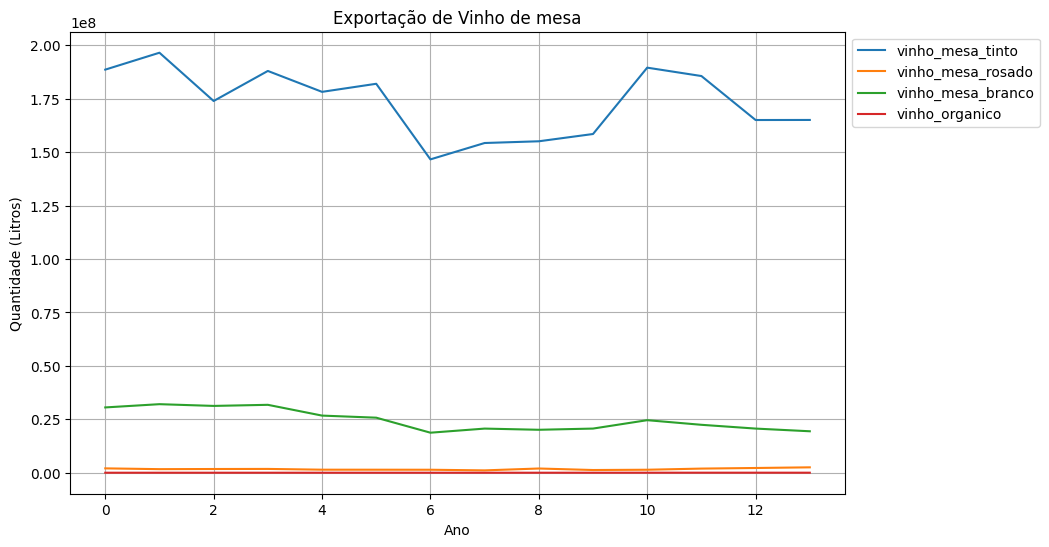

In [38]:
# Seleciona as colunas 'vinho_mesa_tinto', 'vinho_mesa_rosado' e 'vinho_mesa_branco'
df_plot = df_filtro_comercio_vinho_espumante_t[['vinho_mesa_tinto', 'vinho_mesa_rosado', 'vinho_mesa_branco', 'vinho_organico' ]]

# Plota o gráfico de linhas
df_plot.plot(kind='line', figsize=(10, 6))
plt.title('Exportação de Vinho de mesa')
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.grid(True)
plt.show()


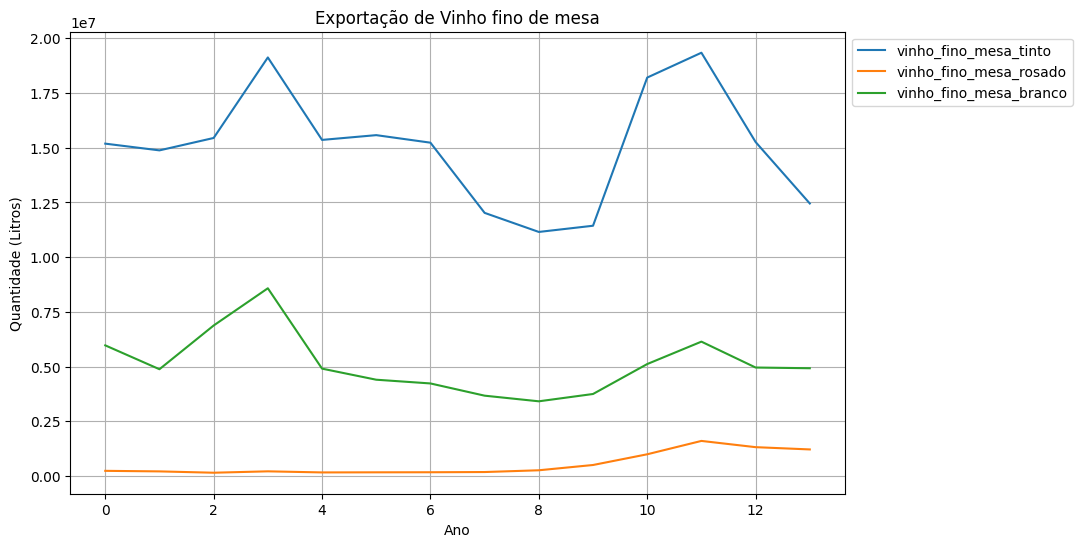

In [39]:
# Seleciona as colunas 'vinho_mesa_tinto', 'vinho_mesa_rosado' e 'vinho_mesa_branco'
df_plot = df_filtro_comercio_vinho_espumante_t[[ 'vinho_fino_mesa_tinto', 'vinho_fino_mesa_rosado', 'vinho_fino_mesa_branco']]

# Plota o gráfico de linhas
df_plot.plot(kind='line', figsize=(10, 6))
plt.title('Exportação de Vinho fino de mesa')
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.grid(True)
plt.show()


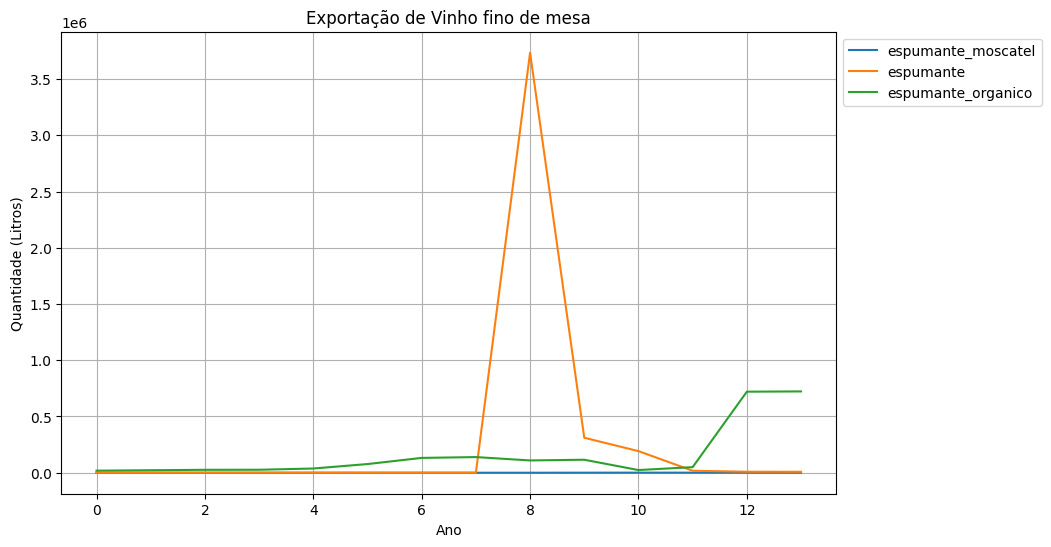

In [40]:
# Seleciona as colunas 'vinho_mesa_tinto', 'vinho_mesa_rosado' e 'vinho_mesa_branco'
df_plot = df_filtro_comercio_vinho_espumante_t[[ 'espumante_moscatel', 'espumante', 'espumante_organico']]

# Plota o gráfico de linhas
df_plot.plot(kind='line', figsize=(10, 6))
plt.title('Exportação de Vinho fino de mesa')
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.grid(True)
plt.show()


### Visualização dados comércio

##Exploração base producao

**dataframes**

Base:

df_filtro_producao_vinho_espumante

Melted:

df_melted_producao_vinho_espumante

Transposto:

df_filtro_producao_vinho_espumante_t

### Informações da Base

In [41]:
print(f'Tamanho do dataset {nome_da_variavel(df_producao)}: {df_producao.shape}')

Tamanho do dataset df_producao: (51, 57)


In [42]:
df_producao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 57 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       51 non-null     int64 
 1   control  51 non-null     object
 2   produto  51 non-null     object
 3   1970     51 non-null     int64 
 4   1971     51 non-null     int64 
 5   1972     51 non-null     int64 
 6   1973     51 non-null     int64 
 7   1974     51 non-null     int64 
 8   1975     51 non-null     int64 
 9   1976     51 non-null     int64 
 10  1977     51 non-null     int64 
 11  1978     51 non-null     int64 
 12  1979     51 non-null     int64 
 13  1980     51 non-null     int64 
 14  1981     51 non-null     int64 
 15  1982     51 non-null     int64 
 16  1983     51 non-null     int64 
 17  1984     51 non-null     int64 
 18  1985     51 non-null     int64 
 19  1986     51 non-null     int64 
 20  1987     51 non-null     int64 
 21  1988     51 non-null     int64 
 22  1989

 Valores nulos

In [43]:
#Quantidade de valores nulos
print(f'Quantidade de dados nulos: {df_producao.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [44]:
# Chama funcao para buscar as colunas com valores nulos
null_cols = get_null_columns(df_producao)
print(f"Columns with null values: {null_cols}")

Columns with null values: []


In [45]:
# Select rows with null values in specific columns
null_rows = df_producao[df_producao[null_cols].isnull().any(axis=1)]
print(null_rows)

Empty DataFrame
Columns: [id, control, produto, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Index: []

[0 rows x 57 columns]


In [46]:
print(df_producao)

    id                                       control  \
0    1                                 VINHO DE MESA   
1    2                                      vm_Tinto   
2    3                                     vm_Branco   
3    4                                     vm_Rosado   
4    5                 VINHO FINO DE MESA (VINIFERA)   
5    6                                      vv_Tinto   
6    7                                     vv_Branco   
7    8                                     vv_Rosado   
8    9                                          SUCO   
9   10                        su_Suco de uva simples   
10  11                           su_Suco concentrado   
11  12                        su_Suco de uva adoçado   
12  13                       su_Suco de uva orgânico   
13  14                  su_Suco de uva reconstituído   
14  15                                     DERIVADOS   
15  16                                  de_Espumante   
16  17                         de_Espumante mosc

Valores únicos

In [47]:
#valores únicos
df_producao.nunique()

,0
id,51
control,51
produto,48
1970,17
1971,18
1972,18
1973,16
1974,16
1975,15
1976,17


Estatistica Básica

In [48]:
df_producao.describe().style.format("{:.2f}")

,id,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,26.00,10053727.45,7585407.25,7210039.88,6172418.59,10722525.61,10606233.02,7921217.25,10221200.20,10918132.51,11480530.90,7827539.69,11294424.00,12929996.67,7380117.02,9541229.57,14366369.96,8838043.73,8554640.31,13669932.43,10725563.22,12190282.20,7998599.25,10044265.14,9977022.47,11380563.41,11703748.71,8634804.98,10500658.51,8365141.57,12208073.80,14624200.39,11630500.35,13317490.39,10534363.84,16055484.78,12746530.63,10838568.27,15318150.55,16867121.53,13404775.06,12604329.14,18060873.22,16815749.02,14574065.45,14677186.47,17360851.53,7864719.37,19052227.02,16382465.22,15801539.53,12490674.16,19111323.53,17523675.04,17952661.57
std,14.87,38808961.58,27449669.38,26280823.84,20892288.87,34808449.02,33176881.52,26426390.91,35088826.02,36545146.66,37363076.84,24107570.42,33610487.58,42291021.12,21814307.46,30728706.73,49281763.58,28222370.80,26014378.55,43191599.67,33413489.44,37763688.00,22790188.34,29277494.70,30579453.64,36724219.21,38253020.27,27365191.91,31148636.70,25842173.30,39627701.09,48132780.94,40229311.19,46799276.40,35683185.04,56207366.15,40629753.98,33510926.68,50004962.78,52887906.63,38037817.54,36181490.27,49003037.74,42960744.41,38089760.21,37982768.38,43530934.32,19403148.50,50842599.71,43798130.95,38338729.81,29146188.05,45710748.97,43520443.24,44266361.21
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,13.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,221.00,0.00,0.00
50%,26.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5817.00,0.00,0.00,100.00,2700.00,922.00,0.00,3000.00,2000.00,32519.00,46000.00,30000.00,5000.00,17200.00
75%,38.50,895660.00,865800.00,1182465.00,378400.00,279810.00,123500.00,246750.00,268750.00,158575.00,27000.00,0.00,0.00,0.00,0.00,0.00,3047445.50,1799287.50,1605444.50,1690944.00,2037552.00,2065470.50,1285265.00,853350.00,436971.00,2275600.00,1723350.00,481363.00,1745284.50,2032090.50,2323651.50,2127889.50,2736264.50,6105688.00,2249276.50,967526.00,1347424.50,684294.50,1589537.50,1434017.50,1271458.50,1548057.00,2100003.50,2380510.50,1598361.00,1504279.00,1536993.00,1033047.50,1759016.00,1533595.00,1757118.50,2747322.00,3824399.50,3138015.50,3974682.00
max,51.00,217208604.00,154264651.00,146953297.00,116710345.00,193875345.00,177401209.00,144565438.00,195359778.00,200053669.00,211252982.00,130308185.00,186129728.00,234754564.00,120261544.00,177680331.00,275338955.00,157711522.00,150467184.00,244791058.00,181801961.00,210548199.00,126768254.00,163248419.00,171754995.00,202073263.00,214788304.00,152917771.00,182816047.00,150814943.00,226520776.00,273025576.00,228932458.00,259589740.00,202545724.00,313962284.00,226080432.00,185100887.00,275287908.00,287506811.00,205418206.00,195267980.00,257840749.00,212777037.00,196904222.00,196173123.00,210308560.00,86319015.00,255015187.00,218375636.00,144629

### Transformação base Produção



In [49]:
df_producao.tail()

,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
46,47,de_Espumante orgânico,Espumante orgânico,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2412,0,1365
47,48,de_Destilado alcoólico simples de bagaceira,Destilado alcoólico simples de bagaceira,0,0,0,0,0,0,0,...,0,0,0,0,0,0,500,3000,4300,0
48,49,de_Vinho acidificado,Vinho acidificado,0,0,0,0,0,0,0,...,0,0,0,0,0,0,65000,0,0,2500
49,50,de_Mosto parcialmente fermentado,Mosto parcialmente fermentado,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,543510,0,0
50,51,de_Outros derivados,Outros derivados,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,322,247228,652301


In [50]:
df_producao.columns

Index(['id', 'control', 'produto', '1970', '1971', '1972', '1973', '1974',
       '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023'],
      dtype='object')

In [51]:
df_producao['control']

,control
0,VINHO DE MESA
1,vm_Tinto
2,vm_Branco
3,vm_Rosado
4,VINHO FINO DE MESA (VINIFERA)
5,vv_Tinto
6,vv_Branco
7,vv_Rosado
8,SUCO
9,su_Suco de uva simples


In [52]:
df_producao

,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,217208604,154264651,146953297,116710345,193875345,177401209,144565438,...,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429
1,2,vm_Tinto,Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,3,vm_Branco,Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,4,vm_Rosado,Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
4,5,VINHO FINO DE MESA (VINIFERA),VINHO FINO DE MESA (VINIFERA),23899346,23586062,21078771,12368410,31644124,39424590,34500590,...,38464314,37148982,18070626,44537870,38707220,37615422,32516686,43474998,47511796,46268556
5,6,vv_Tinto,Tinto,7591557,7265666,6782837,3419625,10047658,14731106,12405154,...,17208996,16745896,8774847,21442212,19118254,17389377,15451883,20433249,24417918,23615783
6,7,vv_Branco,Branco,15562889,15655709,13289304,7930070,18927471,21933695,19874659,...,20054804,19561966,8705066,21928400,18297257,18193055,15487915,20867999,20896613,20693437
7,8,vv_Rosado,Rosado,744900,664687,1006630,1018715,2668995,2759789,2220777,...,1200514,841120,590713,1167258,1291709,2032990,1576888,2173750,2197265,1959336
8,9,SUCO,SUCO,1097771,2296654,3509440,0,0,0,0,...,76723537,87894468,42210389,77161971,65467906,77805352,69261287,100932264,65809079,67045238
9,10,su_Suco de uva simples,Suco de uva integral,1097771,2296654,3509440,0,0,0,0,...,43331223,52233155,31117869,46865626,34367996,50239767,40718523,68038479,35248305,38122173


In [53]:
# Filtra as linhas onde a coluna 'control' contém "Vinho" ou "vm"
# usando o método str.contains com a opção case=False para ignorar maiúsculas/minúsculas
df_filtro_producao_vinho_espumante = df_producao[df_producao['control'].str.contains('vinho|vm|ve|vv|espumante', case=False, na=False)]




In [54]:
df_filtro_producao_vinho_espumante['control']

,control
0,VINHO DE MESA
1,vm_Tinto
2,vm_Branco
3,vm_Rosado
4,VINHO FINO DE MESA (VINIFERA)
5,vv_Tinto
6,vv_Branco
7,vv_Rosado
15,de_Espumante
16,de_Espumante moscatel


In [55]:
#deletando ilnhas de forma direta usando o indice
df_filtro_producao_vinho_espumante = df_filtro_producao_vinho_espumante.drop([0, 4])
df_filtro_producao_vinho_espumante


,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,2,vm_Tinto,Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,3,vm_Branco,Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,4,vm_Rosado,Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
5,6,vv_Tinto,Tinto,7591557,7265666,6782837,3419625,10047658,14731106,12405154,...,17208996,16745896,8774847,21442212,19118254,17389377,15451883,20433249,24417918,23615783
6,7,vv_Branco,Branco,15562889,15655709,13289304,7930070,18927471,21933695,19874659,...,20054804,19561966,8705066,21928400,18297257,18193055,15487915,20867999,20896613,20693437
7,8,vv_Rosado,Rosado,744900,664687,1006630,1018715,2668995,2759789,2220777,...,1200514,841120,590713,1167258,1291709,2032990,1576888,2173750,2197265,1959336
15,16,de_Espumante,Espumante,0,0,0,0,0,0,0,...,2700,23750,1500,11280,68500,52176,32399,70091,70759,65525
16,17,de_Espumante moscatel,Espumante moscatel,0,0,0,0,0,0,0,...,100000,110100,100000,152375,326200,515800,689139,11950,27200,14744
17,18,de_Base espumante,Base espumante,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5475049,0,0
18,19,de_Base espumante moscatel,Base espumante moscatel,0,0,0,0,0,0,0,...,1808044,1607727,1325700,1965629,1320650,1962443,3006705,5549471,6308043,6734590


In [56]:
control_producao_renomeada = [
    'vinho_mesa_tinto',
    'vinho_mesa_rosado',
    'vinho_mesa_branco',
    'vinho_fino_mesa_tinto',
    'vinho_fino_mesa_rosado',
    'vinho_fino_mesa_branco',
    'espumante',
    'espumante_moscatel',
    'base_espumante',
    'base_espumante_moscatel',
    'vinho_leve',
    'vinho_licoroso',
    'vinho_composto',
    'vinho_organico',
    'espumante_organico',
    'vinho_acetificado',
]

In [57]:
len(control_producao_renomeada)

16

In [58]:
#criar um dicionario
control_dict = dict(zip(df_filtro_producao_vinho_espumante['control'], control_producao_renomeada))

# Usa o método map para renomear os valores da coluna 'control'
df_filtro_producao_vinho_espumante['control'] = df_filtro_producao_vinho_espumante['control'].map(control_dict)

df_filtro_producao_vinho_espumante

,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,2,vinho_mesa_tinto,Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,3,vinho_mesa_rosado,Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,4,vinho_mesa_branco,Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
5,6,vinho_fino_mesa_tinto,Tinto,7591557,7265666,6782837,3419625,10047658,14731106,12405154,...,17208996,16745896,8774847,21442212,19118254,17389377,15451883,20433249,24417918,23615783
6,7,vinho_fino_mesa_rosado,Branco,15562889,15655709,13289304,7930070,18927471,21933695,19874659,...,20054804,19561966,8705066,21928400,18297257,18193055,15487915,20867999,20896613,20693437
7,8,vinho_fino_mesa_branco,Rosado,744900,664687,1006630,1018715,2668995,2759789,2220777,...,1200514,841120,590713,1167258,1291709,2032990,1576888,2173750,2197265,1959336
15,16,espumante,Espumante,0,0,0,0,0,0,0,...,2700,23750,1500,11280,68500,52176,32399,70091,70759,65525
16,17,espumante_moscatel,Espumante moscatel,0,0,0,0,0,0,0,...,100000,110100,100000,152375,326200,515800,689139,11950,27200,14744
17,18,base_espumante,Base espumante,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5475049,0,0
18,19,base_espumante_moscatel,Base espumante moscatel,0,0,0,0,0,0,0,...,1808044,1607727,1325700,1965629,1320650,1962443,3006705,5549471,6308043,6734590


In [59]:
df_filtro_producao_vinho_espumante.columns

Index(['id', 'control', 'produto', '1970', '1971', '1972', '1973', '1974',
       '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023'],
      dtype='object')

In [60]:
# Pega as últimas 14 colunas
producao_ultimas_colunas = df_filtro_producao_vinho_espumante.columns[-14:]
# Cria o novo dataframe
#seleciona a primeira coluna
df_filtro_producao_vinho_espumante_v2 = df_filtro_producao_vinho_espumante[['control']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_filtro_producao_vinho_espumante = pd.concat([df_filtro_producao_vinho_espumante_v2, df_filtro_producao_vinho_espumante[producao_ultimas_colunas]], axis=1)


In [61]:
df_filtro_producao_vinho_espumante

,control,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,vinho_mesa_tinto,157290088,210113358,175875432,163111797,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,vinho_mesa_rosado,35408083,46007504,34938249,32066403,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,vinho_mesa_branco,2569809,1719887,1963356,1726022,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
5,vinho_fino_mesa_tinto,11401406,24104740,24027589,23156458,17208996,16745896,8774847,21442212,19118254,17389377,15451883,20433249,24417918,23615783
6,vinho_fino_mesa_rosado,13013027,22739426,20647238,21906349,20054804,19561966,8705066,21928400,18297257,18193055,15487915,20867999,20896613,20693437
7,vinho_fino_mesa_branco,391280,754305,525903,719723,1200514,841120,590713,1167258,1291709,2032990,1576888,2173750,2197265,1959336
15,espumante,10125,26361,17200,30275,2700,23750,1500,11280,68500,52176,32399,70091,70759,65525
16,espumante_moscatel,703393,219100,139775,159781,100000,110100,100000,152375,326200,515800,689139,11950,27200,14744
17,base_espumante,0,0,0,0,0,0,0,0,0,0,0,5475049,0,0
18,base_espumante_moscatel,1144508,2749540,2798908,1470700,1808044,1607727,1325700,1965629,1320650,1962443,3006705,5549471,6308043,6734590


In [62]:
# Renomeia a coluna 'control' para 'tipo_produto'
df_filtro_producao_vinho_espumante = df_filtro_producao_vinho_espumante.rename(columns={'control': 'tipo_produto'})

# Define 'tipo_produto' como índice
df_filtro_producao_vinho_espumante = df_filtro_producao_vinho_espumante.set_index('tipo_produto')


In [63]:
df_filtro_producao_vinho_espumante

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
tipo_produto,,,,,,,,,,,,,,
vinho_mesa_tinto,157290088,210113358,175875432,163111797,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
vinho_mesa_rosado,35408083,46007504,34938249,32066403,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
vinho_mesa_branco,2569809,1719887,1963356,1726022,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
vinho_fino_mesa_tinto,11401406,24104740,24027589,23156458,17208996,16745896,8774847,21442212,19118254,17389377,15451883,20433249,24417918,23615783
vinho_fino_mesa_rosado,13013027,22739426,20647238,21906349,20054804,19561966,8705066,21928400,18297257,18193055,15487915,20867999,20896613,20693437
vinho_fino_mesa_branco,391280,754305,525903,719723,1200514,841120,590713,1167258,1291709,2032990,1576888,2173750,2197265,1959336
espumante,10125,26361,17200,30275,2700,23750,1500,11280,68500,52176,32399,70091,70759,65525
espumante_moscatel,703393,219100,139775,159781,100000,110100,100000,152375,326200,515800,689139,11950,27200,14744
base_espumante,0,0,0,0,0,0,0,0,0,0,0,5475049,0,0


### dataframe melted producão

df_melted_producao_vinho_espumante

In [64]:
df_melted_producao_vinho_espumante = df_filtro_producao_vinho_espumante.reset_index().melt(id_vars='tipo_produto', var_name='ano', value_name='producao')


In [65]:
df_melted_producao_vinho_espumante

,tipo_produto,ano,producao
0,vinho_mesa_tinto,2010,157290088
1,vinho_mesa_rosado,2010,35408083
2,vinho_mesa_branco,2010,2569809
3,vinho_fino_mesa_tinto,2010,11401406
4,vinho_fino_mesa_rosado,2010,13013027
...,...,...,...
219,vinho_licoroso,2023,73600
220,vinho_composto,2023,0
221,vinho_organico,2023,94150
222,espumante_organico,2023,1365


In [66]:
# Convert 'Ano' column to datetime objects
df_melted_producao_vinho_espumante['ano'] = pd.to_datetime(df_melted_producao_vinho_espumante['ano'], format='%Y')

# Extract only years from the datetime objects
df_melted_producao_vinho_espumante['ano'] = df_melted_producao_vinho_espumante['ano'].dt.year




In [67]:
df_melted_producao_vinho_espumante

,tipo_produto,ano,producao
0,vinho_mesa_tinto,2010,157290088
1,vinho_mesa_rosado,2010,35408083
2,vinho_mesa_branco,2010,2569809
3,vinho_fino_mesa_tinto,2010,11401406
4,vinho_fino_mesa_rosado,2010,13013027
...,...,...,...
219,vinho_licoroso,2023,73600
220,vinho_composto,2023,0
221,vinho_organico,2023,94150
222,espumante_organico,2023,1365


In [68]:
df_melted_producao_vinho = df_melted_producao_vinho_espumante.query("tipo_produto in @filtro_vinho")

In [69]:
df_melted_producao_vinho.shape

(84, 3)

In [70]:
df_melted_producao_vinho.tipo_produto.unique()

array(['vinho_mesa_tinto', 'vinho_mesa_rosado', 'vinho_mesa_branco',
       'vinho_fino_mesa_tinto', 'vinho_fino_mesa_rosado',
       'vinho_fino_mesa_branco'], dtype=object)

In [71]:
df_melted_producao_vinho.head(5)

,tipo_produto,ano,producao
0,vinho_mesa_tinto,2010,157290088
1,vinho_mesa_rosado,2010,35408083
2,vinho_mesa_branco,2010,2569809
3,vinho_fino_mesa_tinto,2010,11401406
4,vinho_fino_mesa_rosado,2010,13013027


### Transpondo a tabela

In [72]:
# Transpose o DataFrame para que os anos sejam as colunas
df_filtro_producao_vinho_espumante_t = df_filtro_producao_vinho_espumante.T

In [73]:
df_filtro_producao_vinho_espumante_t

tipo_produto,vinho_mesa_tinto,vinho_mesa_rosado,vinho_mesa_branco,vinho_fino_mesa_tinto,vinho_fino_mesa_rosado,vinho_fino_mesa_branco,espumante,espumante_moscatel,base_espumante,base_espumante_moscatel,vinho_leve,vinho_licoroso,vinho_composto,vinho_organico,espumante_organico,vinho_acetificado
2010,157290088,35408083,2569809,11401406,13013027,391280,10125,703393,0,1144508,0,15000,0,0,0,0
2011,210113358,46007504,1719887,24104740,22739426,754305,26361,219100,0,2749540,0,0,0,5600,0,0
2012,175875432,34938249,1963356,24027589,20647238,525903,17200,139775,0,2798908,0,0,0,0,0,0
2013,163111797,32066403,1726022,23156458,21906349,719723,30275,159781,0,1470700,0,100,0,0,0,0
2014,157776363,37438069,958691,17208996,20054804,1200514,2700,100000,0,1808044,0,36000,3000,0,0,0
2015,169811472,39557250,939838,16745896,19561966,841120,23750,110100,0,1607727,0,56000,0,0,0,0
2016,75279191,10727099,312725,8774847,8705066,590713,1500,100000,0,1325700,0,24200,0,0,0,0
2017,1365957,217527985,36121245,21442212,21928400,1167258,11280,152375,0,1965629,0,110820,0,0,0,0
2018,188270142,29229970,875524,19118254,18297257,1291709,68500,326200,0,1320650,8000,124303,0,0,0,0
2019,121045115,22032828,1551794,17389377,18193055,2032990,52176,515800,0,1962443,0,99485,0,0,0,0


In [74]:
#Converteindex to a column called 'Ano'
df_filtro_producao_vinho_espumante_t = df_filtro_producao_vinho_espumante_t.reset_index().rename(columns={'index': 'Ano'})

#Converte 'Ano' column to datetime objects
df_filtro_producao_vinho_espumante_t['Ano'] = pd.to_datetime(df_filtro_producao_vinho_espumante_t['Ano'], format='%Y')

#Extraia apenas anos do datetime objects
df_filtro_producao_vinho_espumante_t['Ano'] = df_filtro_producao_vinho_espumante_t['Ano'].dt.year

In [75]:
df_filtro_producao_vinho_espumante_t

tipo_produto,Ano,vinho_mesa_tinto,vinho_mesa_rosado,vinho_mesa_branco,vinho_fino_mesa_tinto,vinho_fino_mesa_rosado,vinho_fino_mesa_branco,espumante,espumante_moscatel,base_espumante,base_espumante_moscatel,vinho_leve,vinho_licoroso,vinho_composto,vinho_organico,espumante_organico,vinho_acetificado
0,2010,157290088,35408083,2569809,11401406,13013027,391280,10125,703393,0,1144508,0,15000,0,0,0,0
1,2011,210113358,46007504,1719887,24104740,22739426,754305,26361,219100,0,2749540,0,0,0,5600,0,0
2,2012,175875432,34938249,1963356,24027589,20647238,525903,17200,139775,0,2798908,0,0,0,0,0,0
3,2013,163111797,32066403,1726022,23156458,21906349,719723,30275,159781,0,1470700,0,100,0,0,0,0
4,2014,157776363,37438069,958691,17208996,20054804,1200514,2700,100000,0,1808044,0,36000,3000,0,0,0
5,2015,169811472,39557250,939838,16745896,19561966,841120,23750,110100,0,1607727,0,56000,0,0,0,0
6,2016,75279191,10727099,312725,8774847,8705066,590713,1500,100000,0,1325700,0,24200,0,0,0,0
7,2017,1365957,217527985,36121245,21442212,21928400,1167258,11280,152375,0,1965629,0,110820,0,0,0,0
8,2018,188270142,29229970,875524,19118254,18297257,1291709,68500,326200,0,1320650,8000,124303,0,0,0,0
9,2019,121045115,22032828,1551794,17389377,18193055,2032990,52176,515800,0,1962443,0,99485,0,0,0,0


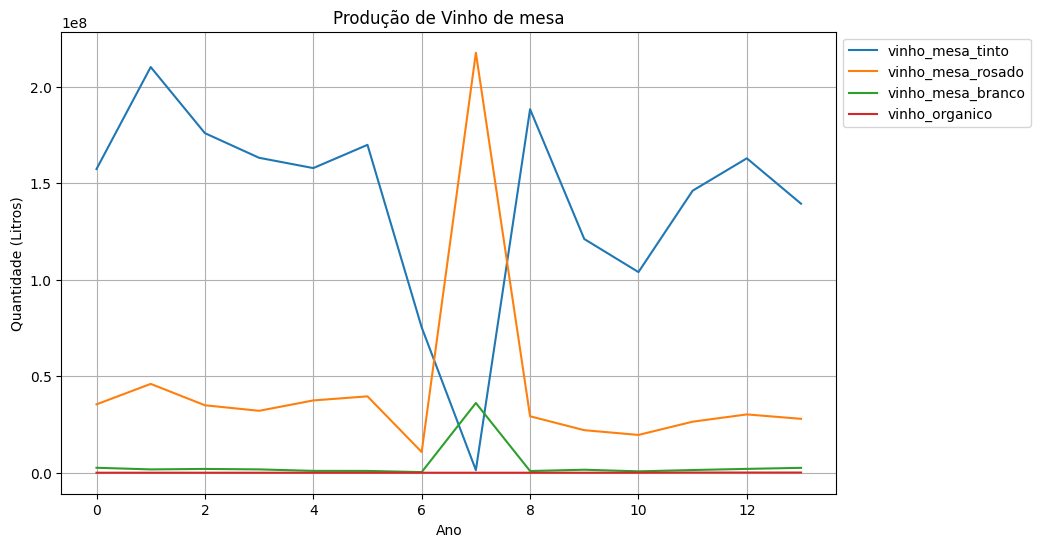

In [76]:
# Seleciona as colunas 'vinho_mesa_tinto', 'vinho_mesa_rosado' e 'vinho_mesa_branco'
df_plot = df_filtro_producao_vinho_espumante_t[['vinho_mesa_tinto', 'vinho_mesa_rosado', 'vinho_mesa_branco', 'vinho_organico' ]]

# Plota o gráfico de linhas
df_plot.plot(kind='line', figsize=(10, 6))
plt.title('Produção de Vinho de mesa')
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.grid(True)
plt.show()


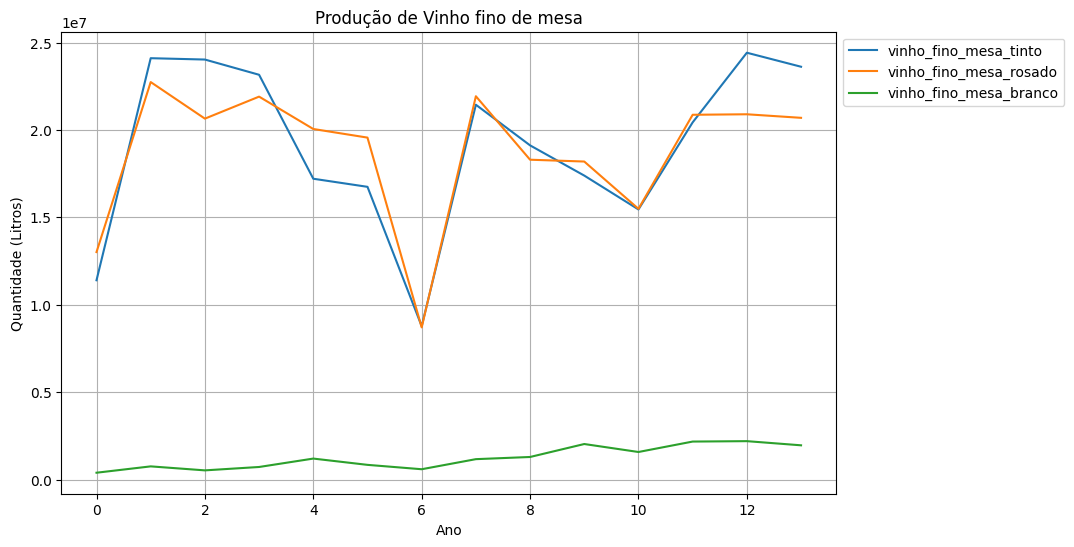

In [77]:
# Seleciona as colunas 'vinho_mesa_tinto', 'vinho_mesa_rosado' e 'vinho_mesa_branco'
df_plot = df_filtro_producao_vinho_espumante_t[[ 'vinho_fino_mesa_tinto', 'vinho_fino_mesa_rosado', 'vinho_fino_mesa_branco']]

# Plota o gráfico de linhas
df_plot.plot(kind='line', figsize=(10, 6))
plt.title('Produção de Vinho fino de mesa')
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.grid(True)
plt.show()


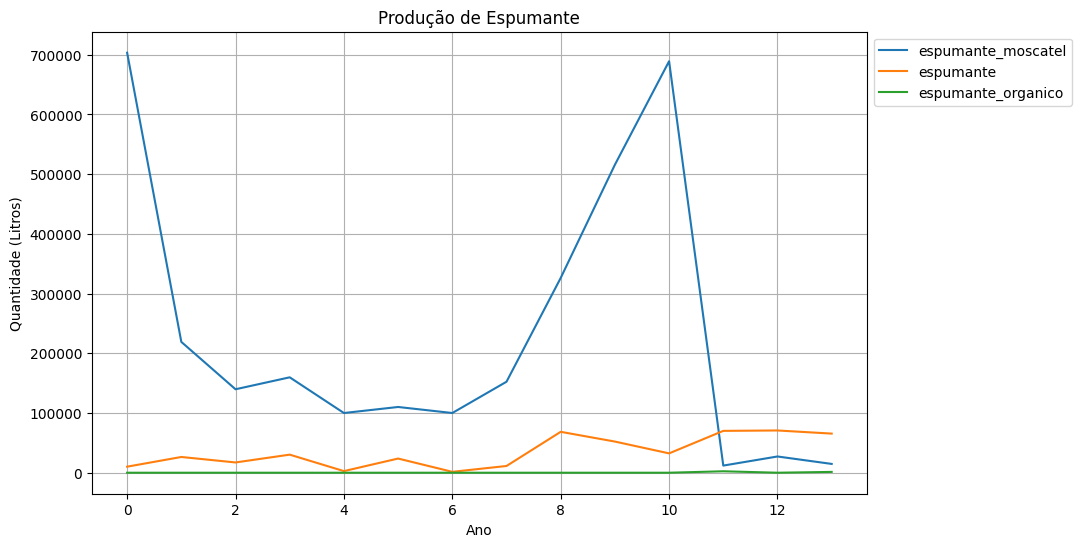

In [78]:
# Seleciona as colunas 'vinho_mesa_tinto', 'vinho_mesa_rosado' e 'vinho_mesa_branco'
df_plot = df_filtro_producao_vinho_espumante_t[[ 'espumante_moscatel', 'espumante', 'espumante_organico']]

# Plota o gráfico de linhas
df_plot.plot(kind='line', figsize=(10, 6))
plt.title('Produção de Espumante')
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
plt.grid(True)
plt.show()


In [79]:
df_melted_producao_vinho_espumante['tipo_produto'].unique()

array(['vinho_mesa_tinto', 'vinho_mesa_rosado', 'vinho_mesa_branco',
       'vinho_fino_mesa_tinto', 'vinho_fino_mesa_rosado',
       'vinho_fino_mesa_branco', 'espumante', 'espumante_moscatel',
       'base_espumante', 'base_espumante_moscatel', 'vinho_leve',
       'vinho_licoroso', 'vinho_composto', 'vinho_organico',
       'espumante_organico', 'vinho_acetificado'], dtype=object)

### Visualização dados produção

In [80]:
selecao = ['vinho_mesa_tinto','vinho_mesa_branco','vinho_mesa_rosado','vinho_fino_mesa_tinto','vinho_fino_mesa_branco','vinho_fino_mesa_rosado']
df_melted_producao_vinho_visual = df_melted_producao_vinho_espumante.query("tipo_produto in @selecao")
df_melted_producao_vinho.head()

,tipo_produto,ano,producao
0,vinho_mesa_tinto,2010,157290088
1,vinho_mesa_rosado,2010,35408083
2,vinho_mesa_branco,2010,2569809
3,vinho_fino_mesa_tinto,2010,11401406
4,vinho_fino_mesa_rosado,2010,13013027


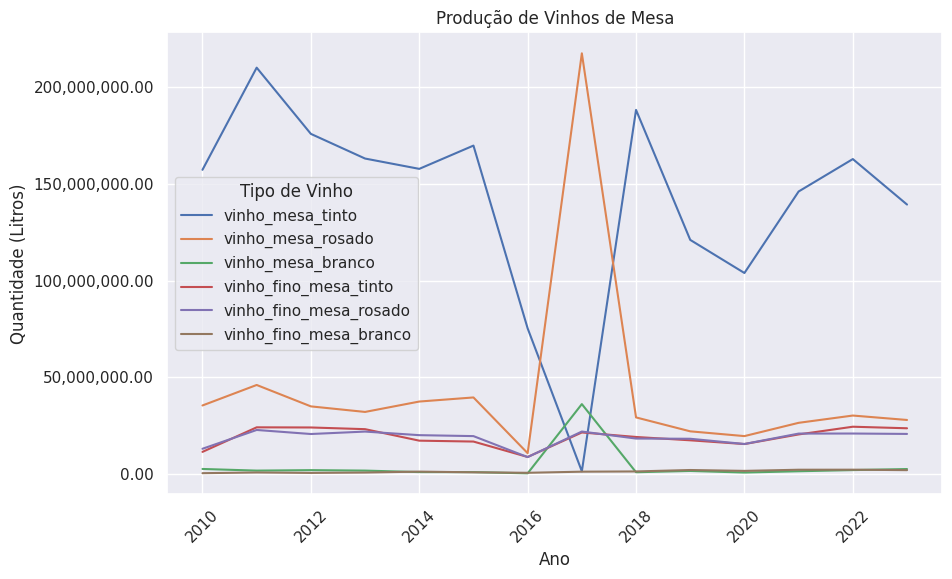

In [81]:
sns.set_theme()
#paleta = sns.color_palette("rocket_r", 24)
plt.figure(figsize=(10, 6)) # Adjust figure size as needed

ax = sns.lineplot( # Using lineplot directly
    df_melted_producao_vinho_visual,
    x="ano", y="producao",
    hue="tipo_produto", # Setting hue for different wine types
    #palette=paleta,

)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=45)
plt.title('Produção de Vinhos de Mesa') # Add a title
plt.xlabel('Ano')
plt.ylabel('Quantidade (Litros)')
plt.legend(title='Tipo de Vinho') # Customize legend title

plt.show()

##Exploração bases importação espumantes

### Informações da Base

In [82]:
df_imp_espumantes.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Africa do Sul,0,0,0,0,0,0,0,0,...,3574,14542,6980,36677,9882,64582,7650,69382,2018,19706
1,2,Alemanha,0,0,25,36,2864,2479,2900,3130,...,21174,65359,19977,46237,12447,26877,322,5111,15168,46600
2,3,Argentina,4980,3836,8811,7543,35301,26909,39208,20230,...,469547,1304986,723847,2211657,1333420,4123623,839006,2765843,1171895,3786391
3,4,Austrália,0,0,0,0,0,0,0,0,...,7426,15190,8062,26208,0,0,3150,10474,15891,26618
4,5,Áustria,0,0,0,0,0,0,0,0,...,909,9399,90,1434,0,0,882,8833,0,0


In [83]:
df_imp_espumantes.columns

Index(['Id', 'País', '1970', '1970.1', '1971', '1971.1', '1972', '1972.1',
       '1973', '1973.1',
       ...
       '2020', '2020.1', '2021', '2021.1', '2022', '2022.1', '2023', '2023.1',
       '2024', '2024.1'],
      dtype='object', length=112)

In [84]:
print(f'Tamanho do dataset {nome_da_variavel(df_comercio)}: {df_imp_espumantes.shape}')

Tamanho do dataset df_comercio: (46, 112)


In [85]:
df_imp_espumantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Columns: 112 entries, Id to 2024.1
dtypes: int64(111), object(1)
memory usage: 40.4+ KB


### Valores nulos

In [86]:
#Quantidade de valores nulos
print(f'Quantidade de dados nulos: {df_imp_espumantes.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [87]:
# Chama funcao para buscar as colunas com valores nulos
null_cols = get_null_columns(df_imp_espumantes)
print(f"Columns with null values: {null_cols}")

Columns with null values: []


In [88]:
# Select rows with null values in specific columns
null_rows = df_imp_espumantes[df_imp_espumantes[null_cols].isnull().any(axis=1)]
print(null_rows)

Empty DataFrame
Columns: [Id, País, 1970, 1970.1, 1971, 1971.1, 1972, 1972.1, 1973, 1973.1, 1974, 1974.1, 1975, 1975.1, 1976, 1976.1, 1977, 1977.1, 1978, 1978.1, 1979, 1979.1, 1980, 1980.1, 1981, 1981.1, 1982, 1982.1, 1983, 1983.1, 1984, 1984.1, 1985, 1985.1, 1986, 1986.1, 1987, 1987.1, 1988, 1988.1, 1989, 1989.1, 1990, 1990.1, 1991, 1991.1, 1992, 1992.1, 1993, 1993.1, 1994, 1994.1, 1995, 1995.1, 1996, 1996.1, 1997, 1997.1, 1998, 1998.1, 1999, 1999.1, 2000, 2000.1, 2001, 2001.1, 2002, 2002.1, 2003, 2003.1, 2004, 2004.1, 2005, 2005.1, 2006, 2006.1, 2007, 2007.1, 2008, 2008.1, 2009, 2009.1, 2010, 2010.1, 2011, 2011.1, 2012, 2012.1, 2013, 2013.1, 2014, 2014.1, 2015, 2015.1, 2016, 2016.1, 2017, 2017.1, 2018, 2018.1, ...]
Index: []

[0 rows x 112 columns]


### Valores únicos

In [89]:
#valores únicos
df_imp_espumantes.nunique()

,0
Id,46
País,46
1970,6
1970.1,6
1971,9
...,...
2022.1,22
2023,22
2023.1,22
2024,23


### Estatistica Básica

In [90]:
df_imp_espumantes.describe().style.format("{:.2f}")

,Id,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,1974,1974.1,1975,1975.1,1976,1976.1,1977,1977.1,1978,1978.1,1979,1979.1,1980,1980.1,1981,1981.1,1982,1982.1,1983,1983.1,1984,1984.1,1985,1985.1,1986,1986.1,1987,1987.1,1988,1988.1,1989,1989.1,1990,1990.1,1991,1991.1,1992,1992.1,1993,1993.1,1994,1994.1,1995,1995.1,1996,1996.1,1997,1997.1,1998,1998.1,1999,1999.1,2000,2000.1,2001,2001.1,2002,2002.1,2003,2003.1,2004,2004.1,2005,2005.1,2006,2006.1,2007,2007.1,2008,2008.1,2009,2009.1,2010,2010.1,2011,2011.1,2012,2012.1,2013,2013.1,2014,2014.1,2015,2015.1,2016,2016.1,2017,2017.1,2018,2018.1,2019,2019.1,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
count,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00
mean,23.50,832.89,1354.37,1086.17,1994.26,2611.39,3675.07,3653.04,6383.46,3751.04,9459.80,2669.67,3926.59,1357.17,2516.59,1888.50,3854.13,2376.76,6843.00,2427.85,6202.78,1870.20,3893.65,7991.00,11283.83,10171.89,12181.96,10701.57,11935.91,3629.02,4624.22,6800.89,8970.02,12507.07,16072.11,6522.78,10608.33,7238.50,13162.28,3647.02,13742.39,4492.11,20793.39,4716.20,20155.26,2482.33,10191.52,9314.17,34830.22,15271.96,63006.78,19226.98,76581.78,16613.74,83446.85,27440.76,207718.61,29988.24,248178.65,44205.28,322086.13,40058.48,248068.07,43270.17,204001.98,51530.72,209612.87,55008.67,240341.20,67104.91,289078.50,74848.00,328126.83,99463.46,465531.15,70543.74,398334.96,76131.96,437916.87,69557.28,423328.02,93788.11,607850.26,107035.17,708817.26,115585.65,818821.72,92815.70,753315.72,93858.57,744805.15,89237.13,714420.07,81490.37,457561.37,162575.85,671702.65,199260.67,641966.37,133969.09,604269.13,107556.98,415150.43,115505.63,539471.74,141072.93,604122.24,159718.70,844059.50,155421.80,918893.65
std,13.42,3349.12,6847.02,4236.29,10743.54,8396.37,15134.88,11479.48,28172.16,14120.53,49792.06,9210.19,14263.57,4115.55,9780.34,6479.26,16521.60,9535.37,35488.03,8125.80,26374.10,7561.75,14728.24,42083.64,54903.20,39782.52,48407.93,46096.22,49061.06,18757.23,20727.72,36503.27,40280.58,64654.01,71656.35,34080.11,45058.90,34042.45,53859.33,12089.46,56945.19,18750.36,83625.28,15542.11,68810.57,9882.77,39285.60,32701.39,121823.11,52197.05,258563.82,61688.21,286540.81,56670.49,362373.57,119266.15,1162881.26,124087.45,1353859.72,186967.26,1729600.94,162714.71,1303957.40,181132.48,1004116.61,238498.16,974681.91,226246.92,1155292.61,234819.64,1136933.68,264172.80,1345158.38,357011.60,1852617.38,251376.99,1728256.00,255439.67,1753475.88,235287.03,1841142.43,311131.53,2629701.12,356238.29,3077695.51,369620.91,3489557.21,298958.31,3454906.00,292138.06,3195936.74,282039.34,3296359.30,264640.60,1881481.98,560249.83,2465390.74,654143.86,2200680.63,421790.58,2252790.85,344959.08,1488995.13,380579.68,2072637.02,446455.53,2201021.49,569316.86,3313567.24,488308.94,3774839.69
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,12.25,0.00,0.00,0.00,0

In [91]:
df_imp_espumantes.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Id,46.00,23.50,13.42,1.00,12.25,23.50,34.75,46.00
1970,46.00,832.89,3349.12,0.00,0.00,0.00,0.00,18458.00
1970.1,46.00,1354.37,6847.02,0.00,0.00,0.00,0.00,45798.00
1971,46.00,1086.17,4236.29,0.00,0.00,0.00,0.00,26523.00
1971.1,46.00,1994.26,10743.54,0.00,0.00,0.00,0.00,72645.00
1972,46.00,2611.39,8396.37,0.00,0.00,0.00,0.00,35899.00
1972.1,46.00,3675.07,15134.88,0.00,0.00,0.00,0.00,97186.00
1973,46.00,3653.04,11479.48,0.00,0.00,0.00,0.00,49453.00
1973.1,46.00,6383.46,28172.16,0.00,0.00,0.00,0.00,186096.00
1974,46.00,3751.04,14120.53,0.00,0.00,0.00,0.00,83575.00


##Exploração bases exportação espumante

### Informações da Base

In [92]:
df_exp_espumantes.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,África do Sul,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,44,78,1353
1,2,Alemanha,0,0,0,0,0,0,0,0,...,2388,14767,142,265,1164,6560,162,1542,22542,77981
2,3,Angola,0,0,0,0,0,0,0,0,...,24,38,0,0,26383,141588,56242,315073,0,0
3,4,Antigua e Barbuda,0,0,0,0,0,0,0,0,...,32,328,10,82,65,146,24,100,23,100
4,5,Antilhas Holandesas,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [93]:
df_exp_espumantes.columns

Index(['Id', 'País', '1970', '1970.1', '1971', '1971.1', '1972', '1972.1',
       '1973', '1973.1',
       ...
       '2020', '2020.1', '2021', '2021.1', '2022', '2022.1', '2023', '2023.1',
       '2024', '2024.1'],
      dtype='object', length=112)

In [94]:
print(f'Tamanho do dataset {nome_da_variavel(df_exp_espumantes)}: {df_exp_espumantes.shape}')

Tamanho do dataset df_exp_espumantes: (107, 112)


In [95]:
df_exp_espumantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Columns: 112 entries, Id to 2024.1
dtypes: int64(111), object(1)
memory usage: 93.8+ KB


### Valores nulos

In [96]:
#Quantidade de valores nulos
print(f'Quantidade de dados nulos: {df_exp_espumantes.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [97]:
# Chama funcao para buscar as colunas com valores nulos
null_cols = get_null_columns(df_exp_espumantes)
print(f"Columns with null values: {null_cols}")

Columns with null values: []


In [98]:
# Select rows with null values in specific columns
null_rows = df_exp_espumantes[df_exp_espumantes[null_cols].isnull().any(axis=1)]
print(null_rows)

Empty DataFrame
Columns: [Id, País, 1970, 1970.1, 1971, 1971.1, 1972, 1972.1, 1973, 1973.1, 1974, 1974.1, 1975, 1975.1, 1976, 1976.1, 1977, 1977.1, 1978, 1978.1, 1979, 1979.1, 1980, 1980.1, 1981, 1981.1, 1982, 1982.1, 1983, 1983.1, 1984, 1984.1, 1985, 1985.1, 1986, 1986.1, 1987, 1987.1, 1988, 1988.1, 1989, 1989.1, 1990, 1990.1, 1991, 1991.1, 1992, 1992.1, 1993, 1993.1, 1994, 1994.1, 1995, 1995.1, 1996, 1996.1, 1997, 1997.1, 1998, 1998.1, 1999, 1999.1, 2000, 2000.1, 2001, 2001.1, 2002, 2002.1, 2003, 2003.1, 2004, 2004.1, 2005, 2005.1, 2006, 2006.1, 2007, 2007.1, 2008, 2008.1, 2009, 2009.1, 2010, 2010.1, 2011, 2011.1, 2012, 2012.1, 2013, 2013.1, 2014, 2014.1, 2015, 2015.1, 2016, 2016.1, 2017, 2017.1, 2018, 2018.1, ...]
Index: []

[0 rows x 112 columns]


### Valores únicos

In [99]:
#valores únicos
df_exp_espumantes.nunique()

,0
Id,107
País,107
1970,4
1970.1,4
1971,3
...,...
2022.1,51
2023,52
2023.1,54
2024,49


### Estatistica Básica

In [100]:
df_exp_espumantes.describe().style.format("{:.2f}")

,Id,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,1974,1974.1,1975,1975.1,1976,1976.1,1977,1977.1,1978,1978.1,1979,1979.1,1980,1980.1,1981,1981.1,1982,1982.1,1983,1983.1,1984,1984.1,1985,1985.1,1986,1986.1,1987,1987.1,1988,1988.1,1989,1989.1,1990,1990.1,1991,1991.1,1992,1992.1,1993,1993.1,1994,1994.1,1995,1995.1,1996,1996.1,1997,1997.1,1998,1998.1,1999,1999.1,2000,2000.1,2001,2001.1,2002,2002.1,2003,2003.1,2004,2004.1,2005,2005.1,2006,2006.1,2007,2007.1,2008,2008.1,2009,2009.1,2010,2010.1,2011,2011.1,2012,2012.1,2013,2013.1,2014,2014.1,2015,2015.1,2016,2016.1,2017,2017.1,2018,2018.1,2019,2019.1,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
count,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00,107.00
mean,54.00,52.18,31.63,4.77,2.75,32.40,14.78,710.50,469.68,77.06,62.50,188.44,133.31,77.64,87.85,201.08,187.09,102.15,122.21,39.12,39.70,168.56,184.27,653.12,767.35,732.67,1150.50,190.22,323.07,22.83,46.58,96.02,181.41,113.45,182.82,160.24,200.40,256.75,585.01,291.36,516.42,15.42,19.55,377.98,328.88,245.56,328.51,445.66,913.35,470.79,478.34,35.56,80.94,171.26,391.66,35.45,73.27,29.07,60.43,7453.58,3084.75,2483.80,2224.21,765.54,1352.23,431.87,576.42,706.94,1086.25,1858.93,2219.51,1041.17,2193.34,1499.93,2688.05,480.22,1807.38,3319.81,5127.57,840.94,3238.79,3618.32,10239.55,1045.63,5312.06,1615.18,7606.63,2006.55,8678.75,4227.43,19714.17,1357.78,6659.21,1626.63,6654.12,2399.50,11023.09,3250.21,10952.60,6413.74,16834.82,7206.22,20075.90,8740.59,24260.47,8690.33,26783.03,4696.31,17988.08,4291.36,17361.79
std,31.03,497.35,310.32,37.07,21.69,222.21,91.67,7312.00,4829.11,764.14,617.58,1843.85,1302.80,434.19,477.94,1818.07,1596.30,793.81,922.16,168.10,171.37,984.79,996.92,4214.38,4613.28,4711.39,6045.85,1904.86,3209.42,137.93,319.88,609.63,1097.31,726.43,1016.57,1441.35,1744.15,1865.30,4890.26,1532.54,3517.76,159.51,202.24,3421.13,2547.14,2225.44,2904.74,2536.15,4767.57,3920.00,2950.95,304.19,680.96,1616.16,3700.65,253.19,491.80,187.32,437.87,71976.03,26806.75,15832.93,11554.59,4812.65,6104.90,3865.67,4096.48,4777.67,6607.15,15774.09,15524.73,5245.51,11473.22,11383.41,15550.49,2239.22,8959.82,27506.40,32302.22,4129.49,19928.76,17978.96,67207.37,6604.25,32850.58,12243.96,50160.98,9627.49,38272.68,17207.25,79560.21,4883.49,25619.43,7137.74,28577.96,10007.23,40402.43,11777.15,36397.22,39280.90,101990.48,61337.31,159453.45,77494.34,205533.97,70869.22,190903.03,25931.17,79194.04,15874.95,57003.09
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,27.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,

In [101]:
df_exp_espumantes.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Id,107.00,54.00,31.03,1.00,27.50,54.00,80.50,107.00
1970,107.00,52.18,497.35,0.00,0.00,0.00,0.00,5132.00
1970.1,107.00,31.63,310.32,0.00,0.00,0.00,0.00,3208.00
1971,107.00,4.77,37.07,0.00,0.00,0.00,0.00,350.00
1971.1,107.00,2.75,21.69,0.00,0.00,0.00,0.00,208.00
1972,107.00,32.40,222.21,0.00,0.00,0.00,0.00,1951.00
1972.1,107.00,14.78,91.67,0.00,0.00,0.00,0.00,697.00
1973,107.00,710.50,7312.00,0.00,0.00,0.00,0.00,75639.00
1973.1,107.00,469.68,4829.11,0.00,0.00,0.00,0.00,49955.00
1974,107.00,77.06,764.14,0.00,0.00,0.00,0.00,7900.00


##Exploração bases exportação vinho

### Informações da Base

In [102]:
df_imp_vinhos.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Africa do Sul,0,0,0,0,0,0,0,0,...,627150,1701072,859169,2508140,738116,2266827,522733,1732850,658238,2133775
1,2,Alemanha,52297,30498,34606,26027,134438,92103,111523,98638,...,136992,504168,106541,546967,92600,438595,102456,557947,121002,805466
2,3,Argélia,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,Arábia Saudita,0,0,0,0,0,0,0,0,...,0,0,2510,8761,0,0,8,161,0,0
4,5,Argentina,19525,12260,24942,15022,104906,58137,116887,76121,...,22610267,66322932,26869241,79527959,27980574,87519642,25276991,83918138,26272478,93869579


In [103]:
df_imp_vinhos.columns

Index(['Id', 'País', '1970', '1970.1', '1971', '1971.1', '1972', '1972.1',
       '1973', '1973.1',
       ...
       '2020', '2020.1', '2021', '2021.1', '2022', '2022.1', '2023', '2023.1',
       '2024', '2024.1'],
      dtype='object', length=112)

In [104]:
print(f'Tamanho do dataset {nome_da_variavel(df_comercio)}: {df_imp_vinhos.shape}')

Tamanho do dataset df_comercio: (69, 112)


In [105]:
df_imp_vinhos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Columns: 112 entries, Id to 2024.1
dtypes: int64(111), object(1)
memory usage: 60.5+ KB


### Valores nulos

In [106]:
#Quantidade de valores nulos
print(f'Quantidade de dados nulos: {df_imp_vinhos.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [107]:
# Chama funcao para buscar as colunas com valores nulos
null_cols = get_null_columns(df_imp_vinhos)
print(f"Columns with null values: {null_cols}")

Columns with null values: []


In [108]:
# Select rows with null values in specific columns
null_rows = df_imp_vinhos[df_imp_vinhos[null_cols].isnull().any(axis=1)]
print(null_rows)

Empty DataFrame
Columns: [Id, País, 1970, 1970.1, 1971, 1971.1, 1972, 1972.1, 1973, 1973.1, 1974, 1974.1, 1975, 1975.1, 1976, 1976.1, 1977, 1977.1, 1978, 1978.1, 1979, 1979.1, 1980, 1980.1, 1981, 1981.1, 1982, 1982.1, 1983, 1983.1, 1984, 1984.1, 1985, 1985.1, 1986, 1986.1, 1987, 1987.1, 1988, 1988.1, 1989, 1989.1, 1990, 1990.1, 1991, 1991.1, 1992, 1992.1, 1993, 1993.1, 1994, 1994.1, 1995, 1995.1, 1996, 1996.1, 1997, 1997.1, 1998, 1998.1, 1999, 1999.1, 2000, 2000.1, 2001, 2001.1, 2002, 2002.1, 2003, 2003.1, 2004, 2004.1, 2005, 2005.1, 2006, 2006.1, 2007, 2007.1, 2008, 2008.1, 2009, 2009.1, 2010, 2010.1, 2011, 2011.1, 2012, 2012.1, 2013, 2013.1, 2014, 2014.1, 2015, 2015.1, 2016, 2016.1, 2017, 2017.1, 2018, 2018.1, ...]
Index: []

[0 rows x 112 columns]


### Valores únicos

In [109]:
#valores únicos
df_imp_vinhos.nunique()

,0
Id,69
País,69
1970,12
1970.1,12
1971,12
...,...
2022.1,35
2023,39
2023.1,40
2024,35


### Estatistica Básica

In [110]:
df_imp_vinhos.describe().style.format("{:.2f}")

,Id,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,1974,1974.1,1975,1975.1,1976,1976.1,1977,1977.1,1978,1978.1,1979,1979.1,1980,1980.1,1981,1981.1,1982,1982.1,1983,1983.1,1984,1984.1,1985,1985.1,1986,1986.1,1987,1987.1,1988,1988.1,1989,1989.1,1990,1990.1,1991,1991.1,1992,1992.1,1993,1993.1,1994,1994.1,1995,1995.1,1996,1996.1,1997,1997.1,1998,1998.1,1999,1999.1,2000,2000.1,2001,2001.1,2002,2002.1,2003,2003.1,2004,2004.1,2005,2005.1,2006,2006.1,2007,2007.1,2008,2008.1,2009,2009.1,2010,2010.1,2011,2011.1,2012,2012.1,2013,2013.1,2014,2014.1,2015,2015.1,2016,2016.1,2017,2017.1,2018,2018.1,2019,2019.1,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
count,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00
mean,35.00,20935.91,12809.94,21016.74,13577.59,40029.74,27384.74,59431.52,48888.62,61526.49,53817.43,59087.10,51000.19,81629.33,67384.35,88408.51,77849.01,120955.17,124372.42,132813.86,158071.13,80533.00,108714.19,58031.77,79599.61,55537.70,68286.67,49378.20,57281.78,28102.96,29126.09,68934.48,74128.64,105468.46,124652.74,65994.01,85251.38,88122.26,119949.57,128421.96,200257.32,115854.84,222479.39,116126.32,204089.62,88632.38,147846.22,173482.94,272772.46,310940.90,508179.78,407226.20,735153.91,327862.01,567341.17,347878.90,698577.00,329569.55,788588.30,382796.19,902681.55,424290.06,946417.74,406521.94,920232.90,350395.93,727100.74,388248.26,831127.71,522639.00,1095233.97,543231.78,1239060.14,671954.64,1716550.86,835213.39,2273760.61,788551.83,2401337.71,810535.61,2556461.12,1025186.49,3233053.55,1053698.91,3797957.51,1075499.13,3807909.32,984846.90,3703857.61,1114639.93,4206569.74,1125890.93,3753330.03,1280363.30,3780340.41,1714938.33,4916105.97,1593782.62,5015972.36,1654716.28,4982857.03,2132393.29,5836133.10,2241892.04,6546827.39,2139139.93,6260566.84,1995838.71,6207139.88,2219162.75,6972217.03
std,20.06,101206.60,66188.25,110311.36,75642.57,203559.24,149828.27,343035.36,275076.69,284494.30,244723.98,288006.99,241593.69,379988.65,297942.63,405191.12,329980.55,561061.93,533547.69,614704.69,678760.56,366554.63,471361.48,242546.08,337261.99,202459.33,247525.72,191464.28,218402.09,111921.49,112758.79,262366.93,271410.60,426508.17,492203.04,261577.96,326697.54,338036.13,449147.62,480468.88,714630.03,474705.46,846968.96,451390.98,719691.46,356235.71,544975.31,756707.66,1032980.34,1427233.79,2158599.19,1664328.75,2899910.82,1274028.16,2014312.01,1172376.67,2385229.94,1088078.84,2684778.90,1181906.50,2847545.18,1418032.33,3117494.81,1377041.75,3029760.42,1192475.59,2409254.50,1381726.40,2852552.79,1993584.81,3946178.45,2098870.21,4560895.67,2571226.14,6178733.66,3198980.66,8166085.71,3102573.70,8615407.28,3356113.89,9569985.53,4076438.87,11796049.66,4106843.25,13752915.92,4327584.45,14192919.57,3970462.35,13634152.23,4766714.51,16210987.92,4860802.18,14954279.02,5669437.97,16287702.64,6933227.00,19743323.62,6803303.24,19938821.28,7041995.05,19981069.63,9578459.68,24191613.94,9511474.25,25919623.77,9365458.50,25818337.83,8607244.61,24598639.97,9870920.18,28418060.61
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

In [111]:
df_imp_vinhos.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Id,69.00,35.00,20.06,1.00,18.00,35.00,52.00,69.00
1970,69.00,20935.91,101206.60,0.00,0.00,0.00,0.00,785609.00
1970.1,69.00,12809.94,66188.25,0.00,0.00,0.00,0.00,531480.00
1971,69.00,21016.74,110311.36,0.00,0.00,0.00,0.00,897310.00
1971.1,69.00,13577.59,75642.57,0.00,0.00,0.00,0.00,620790.00
1972,69.00,40029.74,203559.24,0.00,0.00,0.00,0.00,1650727.00
1972.1,69.00,27384.74,149828.27,0.00,0.00,0.00,0.00,1226232.00
1973,69.00,59431.52,343035.36,0.00,0.00,0.00,0.00,2818320.00
1973.1,69.00,48888.62,275076.69,0.00,0.00,0.00,0.00,2238637.00
1974,69.00,61526.49,284494.30,0.00,0.00,0.00,0.00,2245288.00


##Exploração bases importação vinhos

### Informações da Base

In [112]:
df_imp_vinhos.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Africa do Sul,0,0,0,0,0,0,0,0,...,627150,1701072,859169,2508140,738116,2266827,522733,1732850,658238,2133775
1,2,Alemanha,52297,30498,34606,26027,134438,92103,111523,98638,...,136992,504168,106541,546967,92600,438595,102456,557947,121002,805466
2,3,Argélia,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,Arábia Saudita,0,0,0,0,0,0,0,0,...,0,0,2510,8761,0,0,8,161,0,0
4,5,Argentina,19525,12260,24942,15022,104906,58137,116887,76121,...,22610267,66322932,26869241,79527959,27980574,87519642,25276991,83918138,26272478,93869579


In [113]:
df_imp_vinhos.columns

Index(['Id', 'País', '1970', '1970.1', '1971', '1971.1', '1972', '1972.1',
       '1973', '1973.1',
       ...
       '2020', '2020.1', '2021', '2021.1', '2022', '2022.1', '2023', '2023.1',
       '2024', '2024.1'],
      dtype='object', length=112)

In [114]:
print(f'Tamanho do dataset {nome_da_variavel(df_imp_vinhos)}: {df_imp_vinhos.shape}')

Tamanho do dataset df_imp_vinhos: (69, 112)


In [115]:
df_imp_vinhos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Columns: 112 entries, Id to 2024.1
dtypes: int64(111), object(1)
memory usage: 60.5+ KB


### Valores nulos

In [116]:
#Quantidade de valores nulos
print(f'Quantidade de dados nulos: {df_imp_vinhos.isnull().sum().sum()}')

Quantidade de dados nulos: 0


In [117]:
# Chama funcao para buscar as colunas com valores nulos
null_cols = get_null_columns(df_imp_vinhos)
print(f"Columns with null values: {null_cols}")

Columns with null values: []


In [118]:
# Select rows with null values in specific columns
null_rows = df_comercio[df_comercio[null_cols].isnull().any(axis=1)]
print(null_rows)

Empty DataFrame
Columns: [id, control, Produto, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Index: []

[0 rows x 57 columns]


### Valores únicos

In [119]:
#valores únicos
df_imp_vinhos.nunique()

,0
Id,69
País,69
1970,12
1970.1,12
1971,12
...,...
2022.1,35
2023,39
2023.1,40
2024,35


### Estatistica Básica

In [120]:
df_imp_vinhos.describe().style.format("{:.2f}")

,Id,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,1974,1974.1,1975,1975.1,1976,1976.1,1977,1977.1,1978,1978.1,1979,1979.1,1980,1980.1,1981,1981.1,1982,1982.1,1983,1983.1,1984,1984.1,1985,1985.1,1986,1986.1,1987,1987.1,1988,1988.1,1989,1989.1,1990,1990.1,1991,1991.1,1992,1992.1,1993,1993.1,1994,1994.1,1995,1995.1,1996,1996.1,1997,1997.1,1998,1998.1,1999,1999.1,2000,2000.1,2001,2001.1,2002,2002.1,2003,2003.1,2004,2004.1,2005,2005.1,2006,2006.1,2007,2007.1,2008,2008.1,2009,2009.1,2010,2010.1,2011,2011.1,2012,2012.1,2013,2013.1,2014,2014.1,2015,2015.1,2016,2016.1,2017,2017.1,2018,2018.1,2019,2019.1,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
count,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00,69.00
mean,35.00,20935.91,12809.94,21016.74,13577.59,40029.74,27384.74,59431.52,48888.62,61526.49,53817.43,59087.10,51000.19,81629.33,67384.35,88408.51,77849.01,120955.17,124372.42,132813.86,158071.13,80533.00,108714.19,58031.77,79599.61,55537.70,68286.67,49378.20,57281.78,28102.96,29126.09,68934.48,74128.64,105468.46,124652.74,65994.01,85251.38,88122.26,119949.57,128421.96,200257.32,115854.84,222479.39,116126.32,204089.62,88632.38,147846.22,173482.94,272772.46,310940.90,508179.78,407226.20,735153.91,327862.01,567341.17,347878.90,698577.00,329569.55,788588.30,382796.19,902681.55,424290.06,946417.74,406521.94,920232.90,350395.93,727100.74,388248.26,831127.71,522639.00,1095233.97,543231.78,1239060.14,671954.64,1716550.86,835213.39,2273760.61,788551.83,2401337.71,810535.61,2556461.12,1025186.49,3233053.55,1053698.91,3797957.51,1075499.13,3807909.32,984846.90,3703857.61,1114639.93,4206569.74,1125890.93,3753330.03,1280363.30,3780340.41,1714938.33,4916105.97,1593782.62,5015972.36,1654716.28,4982857.03,2132393.29,5836133.10,2241892.04,6546827.39,2139139.93,6260566.84,1995838.71,6207139.88,2219162.75,6972217.03
std,20.06,101206.60,66188.25,110311.36,75642.57,203559.24,149828.27,343035.36,275076.69,284494.30,244723.98,288006.99,241593.69,379988.65,297942.63,405191.12,329980.55,561061.93,533547.69,614704.69,678760.56,366554.63,471361.48,242546.08,337261.99,202459.33,247525.72,191464.28,218402.09,111921.49,112758.79,262366.93,271410.60,426508.17,492203.04,261577.96,326697.54,338036.13,449147.62,480468.88,714630.03,474705.46,846968.96,451390.98,719691.46,356235.71,544975.31,756707.66,1032980.34,1427233.79,2158599.19,1664328.75,2899910.82,1274028.16,2014312.01,1172376.67,2385229.94,1088078.84,2684778.90,1181906.50,2847545.18,1418032.33,3117494.81,1377041.75,3029760.42,1192475.59,2409254.50,1381726.40,2852552.79,1993584.81,3946178.45,2098870.21,4560895.67,2571226.14,6178733.66,3198980.66,8166085.71,3102573.70,8615407.28,3356113.89,9569985.53,4076438.87,11796049.66,4106843.25,13752915.92,4327584.45,14192919.57,3970462.35,13634152.23,4766714.51,16210987.92,4860802.18,14954279.02,5669437.97,16287702.64,6933227.00,19743323.62,6803303.24,19938821.28,7041995.05,19981069.63,9578459.68,24191613.94,9511474.25,25919623.77,9365458.50,25818337.83,8607244.61,24598639.97,9870920.18,28418060.61
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

In [121]:
df_imp_vinhos.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Id,69.00,35.00,20.06,1.00,18.00,35.00,52.00,69.00
1970,69.00,20935.91,101206.60,0.00,0.00,0.00,0.00,785609.00
1970.1,69.00,12809.94,66188.25,0.00,0.00,0.00,0.00,531480.00
1971,69.00,21016.74,110311.36,0.00,0.00,0.00,0.00,897310.00
1971.1,69.00,13577.59,75642.57,0.00,0.00,0.00,0.00,620790.00
1972,69.00,40029.74,203559.24,0.00,0.00,0.00,0.00,1650727.00
1972.1,69.00,27384.74,149828.27,0.00,0.00,0.00,0.00,1226232.00
1973,69.00,59431.52,343035.36,0.00,0.00,0.00,0.00,2818320.00
1973.1,69.00,48888.62,275076.69,0.00,0.00,0.00,0.00,2238637.00
1974,69.00,61526.49,284494.30,0.00,0.00,0.00,0.00,2245288.00


### Transformação

In [122]:
df_exp_vinhos.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [123]:
# Pega as últimas 30 colunas
ultimas_30_cols = df_exp_vinhos.columns[-30:]
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_15_anos = df_exp_vinhos[['Id', 'País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_15_anos = pd.concat([df_exp_vinhos_15_anos, df_exp_vinhos[ultimas_30_cols]], axis=1)

#renomeia coluna pais
df_exp_vinhos_15_anos.rename(columns={'País': 'pais'}, inplace=True)

#deletando a coluna id
df_exp_vinhos_15_anos.drop("Id", axis=1, inplace = True)

#renomeando alemanha
df_exp_vinhos_15_anos['pais'].replace('Alemanha, República Democrática', 'Alemanha', inplace = True)


<ipython-input-123-e7aebf5da68c>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_exp_vinhos_15_anos['pais'].replace('Alemanha, República Democrática', 'Alemanha', inplace = True)


In [124]:
df_exp_vinhos_15_anos.shape

(141, 31)

In [125]:
df_exp_vinhos_15_anos.columns

Index(['pais', '2010', '2010.1', '2011', '2011.1', '2012', '2012.1', '2013',
       '2013.1', '2014', '2014.1', '2015', '2015.1', '2016', '2016.1', '2017',
       '2017.1', '2018', '2018.1', '2019', '2019.1', '2020', '2020.1', '2021',
       '2021.1', '2022', '2022.1', '2023', '2023.1', '2024', '2024.1'],
      dtype='object')

In [126]:
# Renomeando as colunas
new_columns = []

for col in df_exp_vinhos_15_anos.columns:
    if col == 'Id' or col == 'pais':
        new_columns.append(col)
    elif '.' in col:
        new_columns.append(col.split('.')[0] + '_valor')
    else:
        new_columns.append(col + '_quant')

df_exp_vinhos_15_anos.columns = new_columns


In [127]:
df_exp_vinhos_15_anos.columns

Index(['pais', '2010_quant', '2010_valor', '2011_quant', '2011_valor',
       '2012_quant', '2012_valor', '2013_quant', '2013_valor', '2014_quant',
       '2014_valor', '2015_quant', '2015_valor', '2016_quant', '2016_valor',
       '2017_quant', '2017_valor', '2018_quant', '2018_valor', '2019_quant',
       '2019_valor', '2020_quant', '2020_valor', '2021_quant', '2021_valor',
       '2022_quant', '2022_valor', '2023_quant', '2023_valor', '2024_quant',
       '2024_valor'],
      dtype='object')

In [128]:
df_exp_vinhos_15_anos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   pais        141 non-null    object
 1   2010_quant  141 non-null    int64 
 2   2010_valor  141 non-null    int64 
 3   2011_quant  141 non-null    int64 
 4   2011_valor  141 non-null    int64 
 5   2012_quant  141 non-null    int64 
 6   2012_valor  141 non-null    int64 
 7   2013_quant  141 non-null    int64 
 8   2013_valor  141 non-null    int64 
 9   2014_quant  141 non-null    int64 
 10  2014_valor  141 non-null    int64 
 11  2015_quant  141 non-null    int64 
 12  2015_valor  141 non-null    int64 
 13  2016_quant  141 non-null    int64 
 14  2016_valor  141 non-null    int64 
 15  2017_quant  141 non-null    int64 
 16  2017_valor  141 non-null    int64 
 17  2018_quant  141 non-null    int64 
 18  2018_valor  141 non-null    int64 
 19  2019_quant  141 non-null    int64 
 20  2019_valor

In [129]:
# Calculo para as colunas de quantidade total e valor total
quant_cols = [col for col in df_exp_vinhos_15_anos.columns if '_quant' in col]
valor_cols = [col for col in df_exp_vinhos_15_anos.columns if '_valor' in col]

df_exp_vinhos_15_anos['quant_total'] = df_exp_vinhos_15_anos[quant_cols].sum(axis=1)
df_exp_vinhos_15_anos['valor_total'] = df_exp_vinhos_15_anos[valor_cols].sum(axis=1)



In [130]:
df_exp_vinhos_15_anos['valor_total'].describe()

,valor_total
count,141.00
mean,810351.62
std,4359841.68
min,0.00
25%,85.00
50%,11039.00
75%,211007.00
max,47591976.00


## Dataframe quantida total países por ano

df_exp_vinhos_15_litro

In [131]:
filtro_litro = []
litro_columns = []
for col in df_exp_vinhos_15_anos.columns:
    if col == 'pais':
        filtro_litro.append(col)
        litro_columns.append(col)
    elif '_quant' in col:
        filtro_litro.append(col)
        litro_columns.append(col.split('_')[0])


df_exp_vinhos_15_litro = df_exp_vinhos_15_anos[filtro_litro]



In [132]:
df_exp_vinhos_15_litro.columns = litro_columns

In [133]:
df_exp_vinhos_15_litro.head()

,pais,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afeganistão,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0
1,África do Sul,0,0,0,0,0,0,0,0,0,26,4,0,0,117,103
2,Alemanha,27715,36070,8189,61699,213348,10680,14012,15467,10794,3660,6261,2698,7630,4806,6666
3,Angola,33557,13889,2833,1573,12182,1908,7359,10170,477,345,0,0,4068,0,0
4,Anguilla,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [134]:
# Set 'pais' column como índice
df_exp_vinhos_15_litro = df_exp_vinhos_15_litro.set_index('pais')


### Dataset Melted de exportação de vinhos (quantidade)



dataset base:

df_exp_vinhos_15_litro

In [135]:
# Melt the DataFrame
df_melted_exp_vinhos_15_litro = df_exp_vinhos_15_litro.reset_index().melt(id_vars='pais', var_name='ano', value_name='quantidade')

df_melted_exp_vinhos_15_litro


,pais,ano,quantidade
0,Afeganistão,2010,0
1,África do Sul,2010,0
2,Alemanha,2010,27715
3,Angola,2010,33557
4,Anguilla,2010,0
...,...,...,...
2110,Tuvalu,2024,0
2111,Uruguai,2024,36729
2112,Vanuatu,2024,0
2113,Venezuela,2024,122922


### DataFrame Quantidade de exportação geral

In [136]:
# Reset the index to make 'pais' a column again
df_exp_vinhos_15_a_litro = df_exp_vinhos_15_litro.reset_index()
# Now you can drop 'pais' as a regular column
df_exp_vinhos_15_a_litro = df_exp_vinhos_15_a_litro.drop('pais', axis=1)

In [137]:
df_exp_vinhos_15_a_litro = pd.DataFrame(df_exp_vinhos_15_a_litro.sum())
# Renomeando o índice e a quantidade
df_exp_vinhos_15_a_litro.index.name = 'ano'  # Rename index to 'ano'
df_exp_vinhos_15_a_litro.columns = ['litro']  # Rename column to 'quantidade'

In [138]:
df_exp_vinhos_15_a_litro.head(2)

,litro
ano,
2010,1280574
2011,1214834


<ipython-input-139-2b3418903995>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_15_a_litro, x='ano', y="litro",palette=paleta, dodge=False, legend=False)
<ipython-input-139-2b3418903995>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_15_a_litro, x='ano', y="litro",palette=paleta, dodge=False, legend=False)


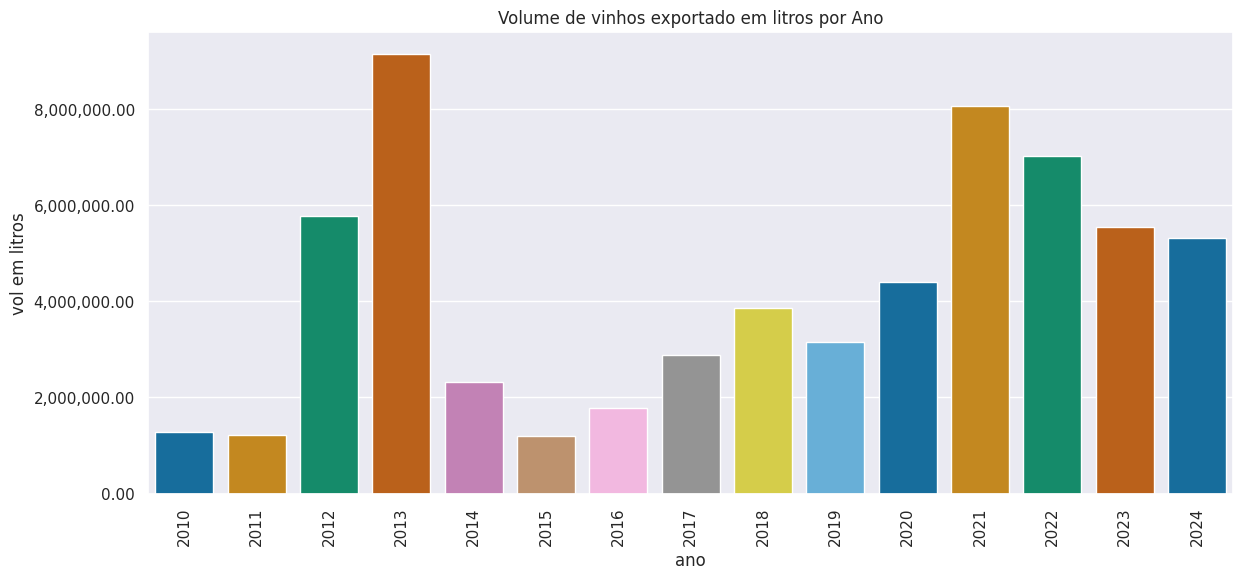

In [139]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_15_a_litro, x='ano', y="litro",palette=paleta, dodge=False, legend=False)
plt.title('Volume de vinhos exportado em litros por Ano')
plt.ylabel('vol em litros')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

## Dataframe valor total por ano

In [140]:
filtro_valor = []
valor_columns = []
for col in df_exp_vinhos_15_anos.columns:
    if col == 'pais':
        filtro_valor.append(col)
        valor_columns.append(col)
    elif '_valor' in col:
        filtro_valor.append(col)
        valor_columns.append(col.split('_')[0])


df_exp_vinhos_15_a_valor = df_exp_vinhos_15_anos[filtro_valor]

In [141]:
df_exp_vinhos_15_a_valor.columns = valor_columns

In [142]:
df_exp_vinhos_15_a_valor.head()

,pais,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afeganistão,0,0,0,0,0,0,0,0,0,0,0,46,0,0,0
1,África do Sul,0,0,0,0,0,0,0,0,0,95,21,0,0,698,1783
2,Alemanha,138666,144150,56342,265978,761653,44780,68109,87702,45382,25467,32605,6741,45367,31853,48095
3,Angola,189891,69001,8861,9300,23124,17089,35390,61680,709,1065,0,0,4761,0,0
4,Anguilla,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [143]:
df_exp_vinhos_15_a_valor = df_exp_vinhos_15_a_valor.drop('pais', axis = 1)

In [144]:
df_exp_vinhos_15_a_valor = pd.DataFrame(df_exp_vinhos_15_a_valor.sum())
# Renomeando o índice e a quantidade
df_exp_vinhos_15_a_valor.index.name = 'ano'  # Rename index to 'ano'
df_exp_vinhos_15_a_valor.columns = ['valor']  # Rename column to 'valor'

In [145]:
df_exp_vinhos_15_a_valor.head(2)

,valor
ano,
2010,2595303
2011,3615120


<ipython-input-146-b7cb30f325ff>:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(data=df_exp_vinhos_15_a_valor, x='ano', y="valor",palette=paleta, label="Valor")
<ipython-input-146-b7cb30f325ff>:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax2 = sns.lineplot(data=df_exp_vinhos_15_a_litro, x='ano', y="litro",palette=paleta, label="Litro")


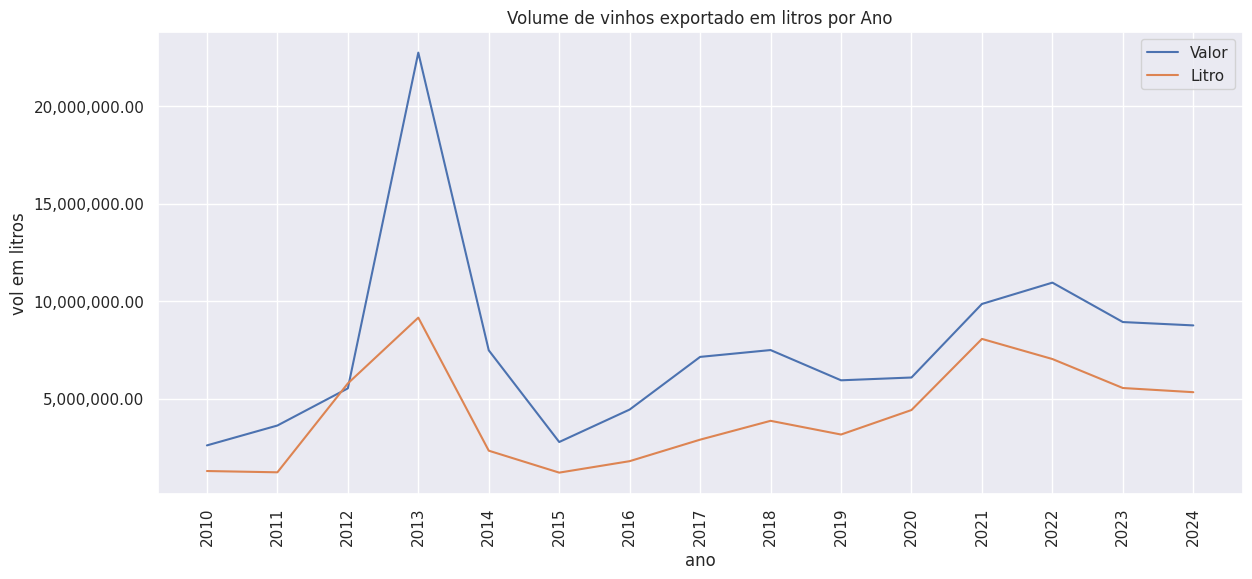

In [146]:
sns.set_theme()

paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))

ax = sns.lineplot(data=df_exp_vinhos_15_a_valor, x='ano', y="valor",palette=paleta, label="Valor")
plt.title('Valor de vinhos exportado por Ano')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))


ax2 = sns.lineplot(data=df_exp_vinhos_15_a_litro, x='ano', y="litro",palette=paleta, label="Litro")
plt.title('Volume de vinhos exportado em litros por Ano')
plt.ylabel('vol em litros')
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))

plt.xticks(rotation=90)
plt.legend()


plt.show()

## Gráfico litros por valor

**concatenando do os datasets:**

df_exp_vinhos_15_a_valor

df_exp_vinhos_15_a_litro

<ipython-input-147-f1231453bf41>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_15_a_valor, x='ano', y="valor",palette=paleta, dodge=False, legend=False)
<ipython-input-147-f1231453bf41>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_15_a_valor, x='ano', y="valor",palette=paleta, dodge=False, legend=False)


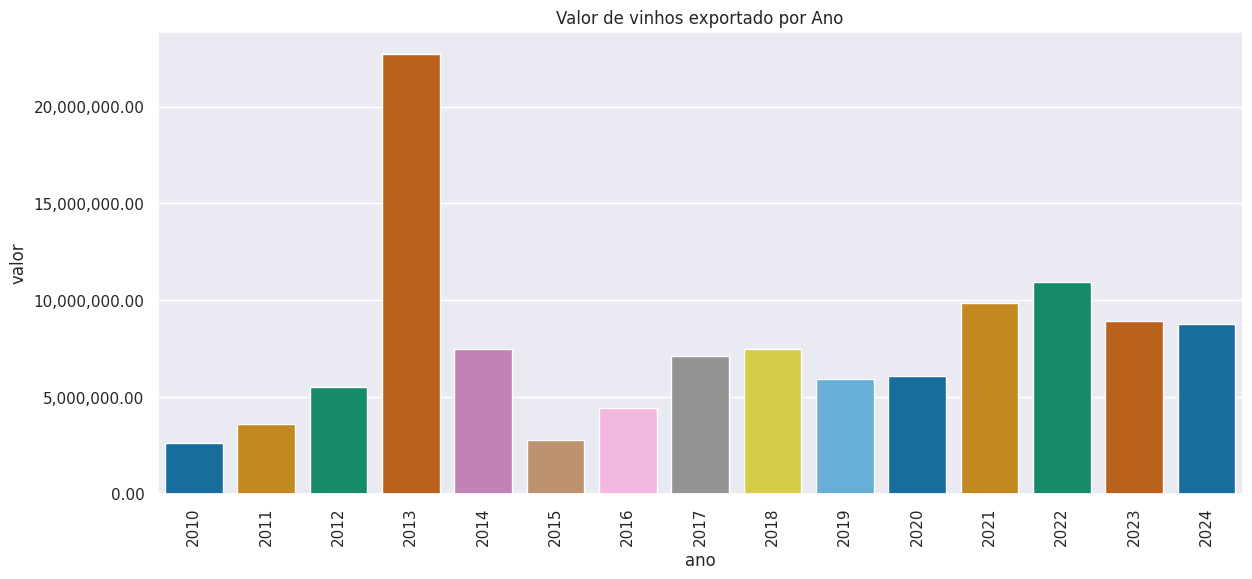

In [147]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_15_a_valor, x='ano', y="valor",palette=paleta, dodge=False, legend=False)
plt.title('Valor de vinhos exportado por Ano')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

## dataframe valor/quantidade total por ano

dataframe:

df_exp_vinhos_15_a_valor

df_exp_vinhos_15_a_litro

In [148]:
#df_exp_vinhos_15_a_valor
#df_exp_vinhos_15_a_quant_total
df_exp_vinhos_15_total = pd.concat([df_exp_vinhos_15_a_valor, df_exp_vinhos_15_a_litro], axis=1)

In [149]:
df_exp_vinhos_15_total.head()

,valor,litro
ano,,
2010,2595303,1280574
2011,3615120,1214834
2012,5521293,5775376
2013,22744845,9149059
2014,7472795,2324029


In [150]:
df_exp_vinhos_15_total.columns

Index(['valor', 'litro'], dtype='object')

In [151]:
# Reset the index before converting to datetime
df_exp_vinhos_15_total = df_exp_vinhos_15_total.reset_index()
# Now convert the 'ano' column to datetime
df_exp_vinhos_15_total['ano'] = pd.to_datetime(df_exp_vinhos_15_total['ano'], format='%Y')
# Format the 'ano' column to display only the year
df_exp_vinhos_15_total['ano'] = df_exp_vinhos_15_total['ano'].dt.strftime('%Y')
# Set the 'ano' column as the index again
df_exp_vinhos_15_total = df_exp_vinhos_15_total.set_index('ano')

In [152]:
df_exp_vinhos_15_total['valor_litro'] = df_exp_vinhos_15_total['valor'] / df_exp_vinhos_15_total['litro']

In [153]:
df_exp_vinhos_15_total.head()

,valor,litro,valor_litro
ano,,,
2010,2595303,1280574,2.03
2011,3615120,1214834,2.98
2012,5521293,5775376,0.96
2013,22744845,9149059,2.49
2014,7472795,2324029,3.22


In [154]:
# exportando o df_exp_vinhos_15_total para csv

df_exp_vinhos_15_total.to_csv('df_exp_vinhos_15_total.csv')


### **Gráficos valor por litro**

<ipython-input-155-dfa3c4205a05>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_15_total, x='ano', y="valor_litro",palette=paleta, dodge=False, legend=False)
<ipython-input-155-dfa3c4205a05>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_15_total, x='ano', y="valor_litro",palette=paleta, dodge=False, legend=False)


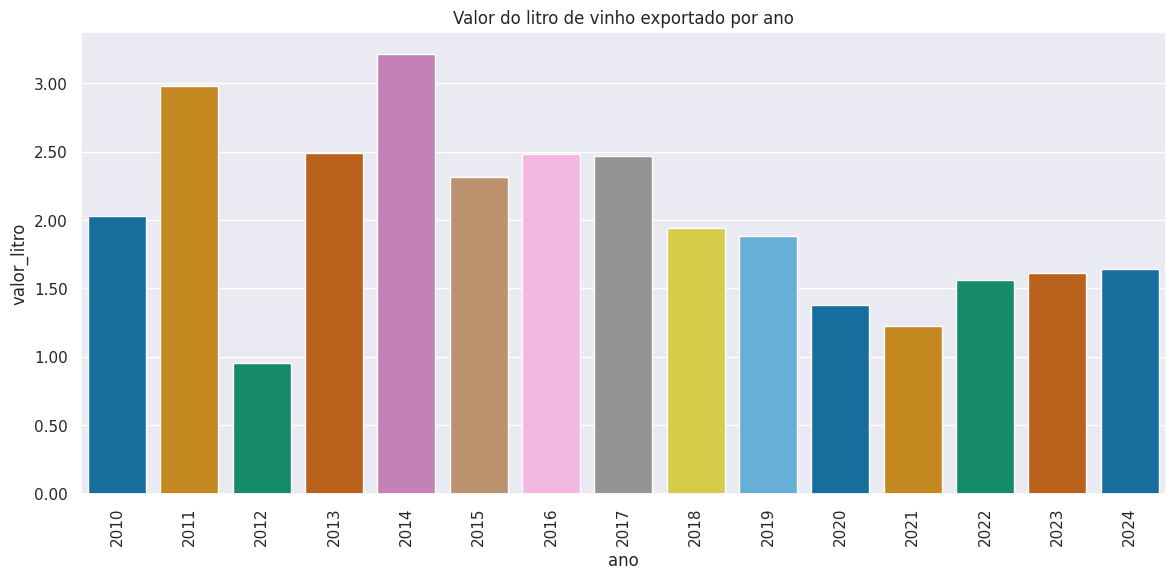

In [155]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_15_total, x='ano', y="valor_litro",palette=paleta, dodge=False, legend=False)
plt.title('Valor do litro de vinho exportado por ano')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

<ipython-input-156-041dafc2e3c2>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_15_total.sort_values(by='valor_litro', ascending=False), x='ano', y="valor_litro",palette=paleta, dodge=False, legend=False)
<ipython-input-156-041dafc2e3c2>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_15_total.sort_values(by='valor_litro', ascending=False), x='ano', y="valor_litro",palette=paleta, dodge=False, legend=False)


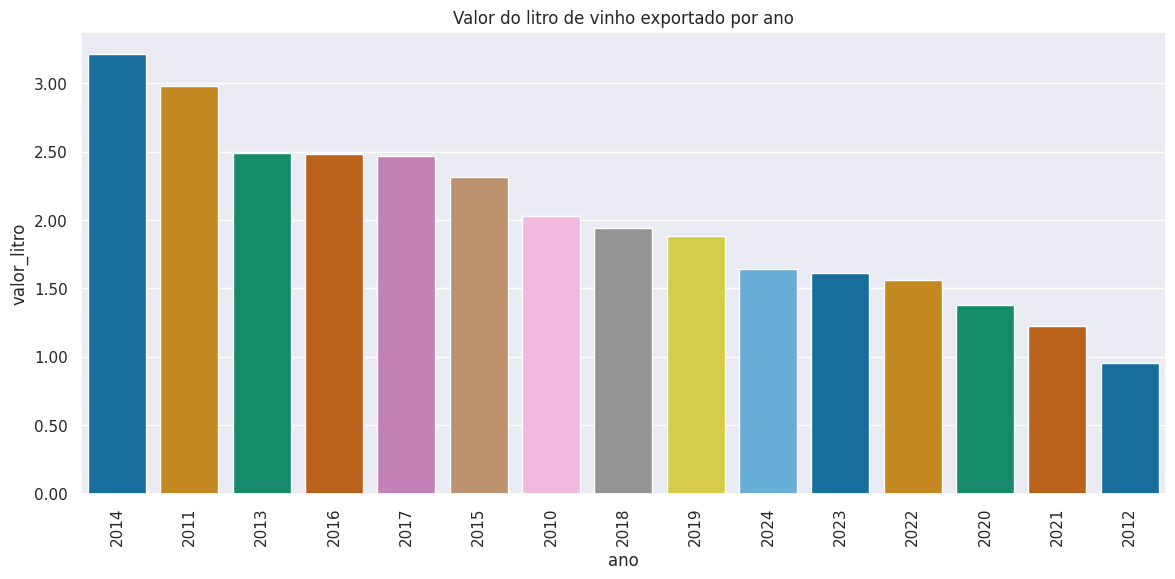

In [156]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_15_total.sort_values(by='valor_litro', ascending=False), x='ano', y="valor_litro",palette=paleta, dodge=False, legend=False)
plt.title('Valor do litro de vinho exportado por ano')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

## Exportação total 15 anos

## dataframe quantida total por ano

In [157]:
filtro_quant = []
quant_columns = []
for col in df_exp_vinhos_15_anos.columns:
    if col == 'pais':
        filtro_quant.append(col)
        quant_columns.append(col)
    elif '_quant' in col:
        filtro_quant.append(col)
        quant_columns.append(col.split('_')[0])


df_exp_vinhos_15_a_quant = df_exp_vinhos_15_anos[filtro_quant]



In [158]:
df_exp_vinhos_15_a_quant.columns = quant_columns

In [159]:
df_exp_vinhos_15_a_quant.head()

,pais,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afeganistão,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0
1,África do Sul,0,0,0,0,0,0,0,0,0,26,4,0,0,117,103
2,Alemanha,27715,36070,8189,61699,213348,10680,14012,15467,10794,3660,6261,2698,7630,4806,6666
3,Angola,33557,13889,2833,1573,12182,1908,7359,10170,477,345,0,0,4068,0,0
4,Anguilla,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [160]:
df_exp_vinhos_15_a_quant_total = df_exp_vinhos_15_a_quant.drop('pais', axis = 1)

In [161]:
df_exp_vinhos_15_a_quant_total = pd.DataFrame(df_exp_vinhos_15_a_quant_total.sum())
# Renomeando o índice e a quantidade
df_exp_vinhos_15_a_quant_total.index.name = 'ano'  # Rename index to 'ano'
df_exp_vinhos_15_a_quant_total.columns = ['quantidade']  # Rename column to 'quantidade'

In [162]:
df_exp_vinhos_15_a_quant_total.head(2)

,quantidade
ano,
2010,1280574
2011,1214834


<ipython-input-163-dc14bbb2b686>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_15_a_quant_total, x='ano', y="quantidade",palette=paleta, dodge=False, legend=False)
<ipython-input-163-dc14bbb2b686>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_15_a_quant_total, x='ano', y="quantidade",palette=paleta, dodge=False, legend=False)


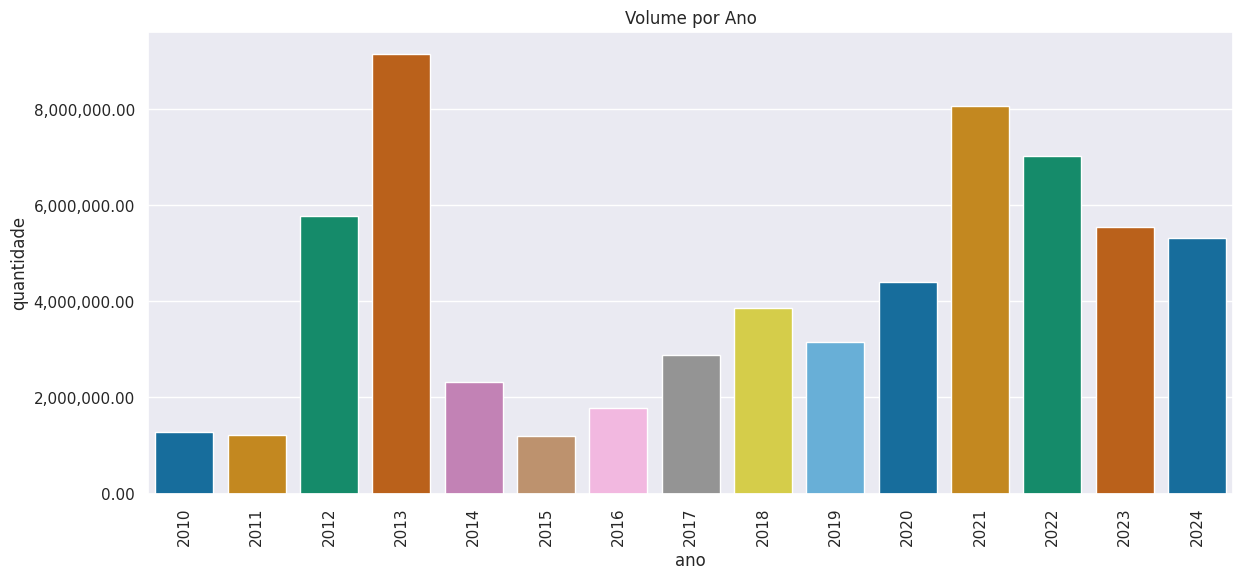

In [163]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_15_a_quant_total, x='ano', y="quantidade",palette=paleta, dodge=False, legend=False)
plt.title('Volume por Ano')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [164]:
#quantidade de países sem exportação nos últimos 15 anos
quant_paises_sem_exp = df_exp_vinhos_15_anos.query("valor_total == 0")
print(f'Quantidade de países que não tiveram importaram nenhum vinho nos último 15 anos: {quant_paises_sem_exp.shape[0]}/{df_exp_vinhos_15_anos.shape[0]}')

Quantidade de países que não tiveram importaram nenhum vinho nos último 15 anos: 16/141


In [165]:
#ordenando por valor_total
df_exp_vinhos_15_anos_ord = df_exp_vinhos_15_anos.sort_values(by="valor_total", ascending=False, ignore_index=True)

In [166]:
df_exp_vinhos_15_anos_ord.head()

,pais,2010_quant,2010_valor,2011_quant,2011_valor,2012_quant,2012_valor,2013_quant,2013_valor,2014_quant,...,2021_quant,2021_valor,2022_quant,2022_valor,2023_quant,2023_valor,2024_quant,2024_valor,quant_total,valor_total
0,Paraguai,510989,449197,240168,276281,354824,428279,481564,680828,521847,...,6522527,7192362,5076670,7156293,3780378,5517263,3705268,5121857,34021588,47591976
1,Rússia,0,0,0,0,4528176,2103968,5893291,14795694,190656,...,181931,312926,66046,118618,0,0,56,338,10909283,17419774
2,Estados Unidos,228968,478630,306787,1030254,146585,303986,245368,786556,222267,...,111085,203554,220373,447893,229839,429091,310410,648724,3287390,9297709
3,Reino Unido,123624,295690,122629,285642,82937,334856,59161,305005,305807,...,25316,122394,18835,138154,11326,84547,14780,106713,1135468,4678860
4,China,795,2358,54156,334867,87905,642177,40929,279956,64040,...,61884,264116,105395,404647,73917,183096,34231,182595,1055501,4603890


<ipython-input-167-986e81ccafc8>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_15_anos_ord[:15], x='pais', y="valor_total",palette=paleta, dodge=False, legend=False)
<ipython-input-167-986e81ccafc8>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_15_anos_ord[:15], x='pais', y="valor_total",palette=paleta, dodge=False, legend=False)


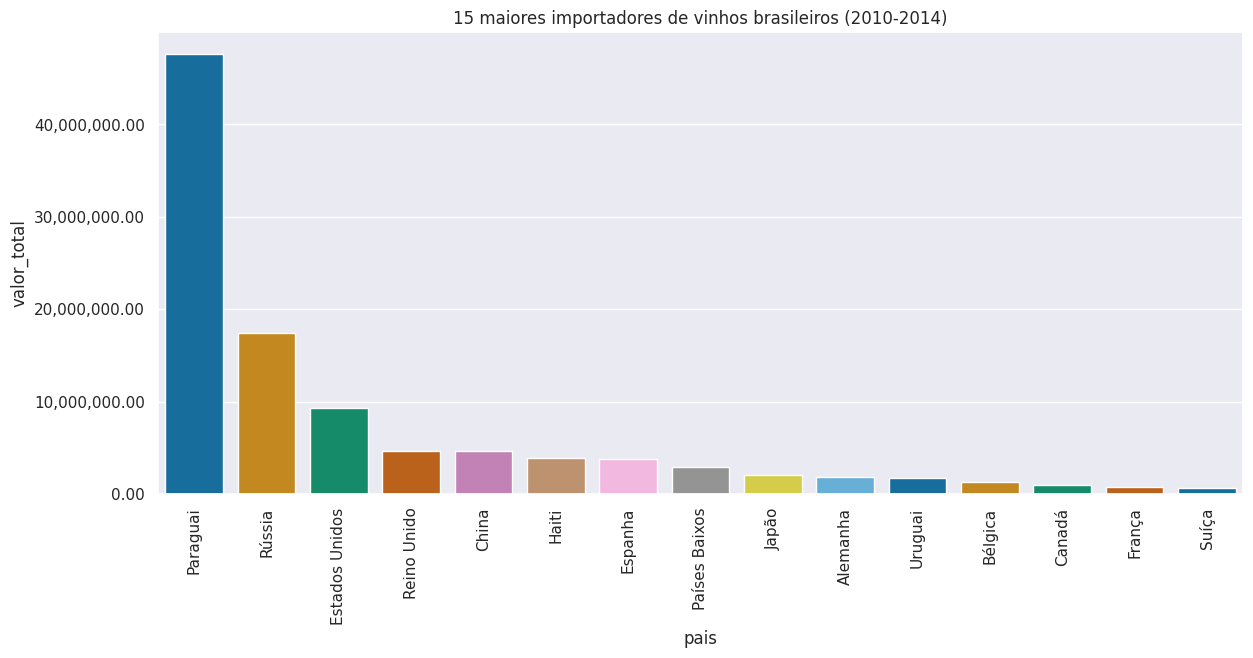

In [167]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_15_anos_ord[:15], x='pais', y="valor_total",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2010-2014)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [168]:
df_exp_vinhos_15_anos.head()

,pais,2010_quant,2010_valor,2011_quant,2011_valor,2012_quant,2012_valor,2013_quant,2013_valor,2014_quant,...,2021_quant,2021_valor,2022_quant,2022_valor,2023_quant,2023_valor,2024_quant,2024_valor,quant_total,valor_total
0,Afeganistão,0,0,0,0,0,0,0,0,0,...,11,46,0,0,0,0,0,0,11,46
1,África do Sul,0,0,0,0,0,0,0,0,0,...,0,0,0,0,117,698,103,1783,250,2597
2,Alemanha,27715,138666,36070,144150,8189,56342,61699,265978,213348,...,2698,6741,7630,45367,4806,31853,6666,48095,429695,1802890
3,Angola,33557,189891,13889,69001,2833,8861,1573,9300,12182,...,0,0,4068,4761,0,0,0,0,88361,420871
4,Anguilla,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Exportação por ano

In [169]:
# Pega as últimas 30 colunas
coluna = ['2010', '2010.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2010 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2010 = pd.concat([df_exp_vinhos_2010, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2010_ord = df_exp_vinhos_2010.sort_values(by="2010.1", ascending=False, ignore_index=True)

<ipython-input-170-0c18a1cbfee9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2010_ord[:15], x='País', y="2010.1",palette=paleta, dodge=False, legend=False)
<ipython-input-170-0c18a1cbfee9>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2010_ord[:15], x='País', y="2010.1",palette=paleta, dodge=False, legend=False)


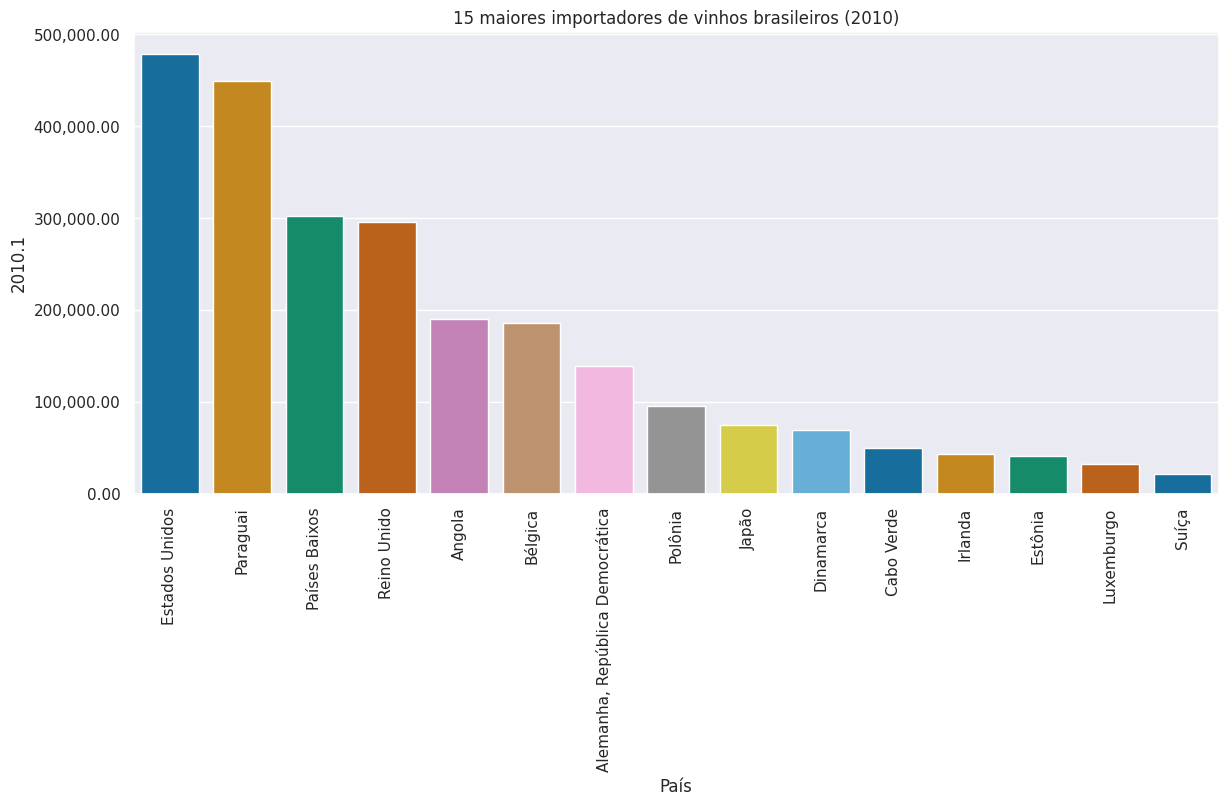

In [170]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2010_ord[:15], x='País', y="2010.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2010)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [171]:
# Pega as últimas 30 colunas
coluna = ['2011', '2011.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2011 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2011 = pd.concat([df_exp_vinhos_2011, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2011_ord = df_exp_vinhos_2011.sort_values(by="2011.1", ascending=False, ignore_index=True)

<ipython-input-172-3b66f131d22e>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2011_ord[:15], x='País', y="2011.1",palette=paleta, dodge=False, legend=False)
<ipython-input-172-3b66f131d22e>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2011_ord[:15], x='País', y="2011.1",palette=paleta, dodge=False, legend=False)


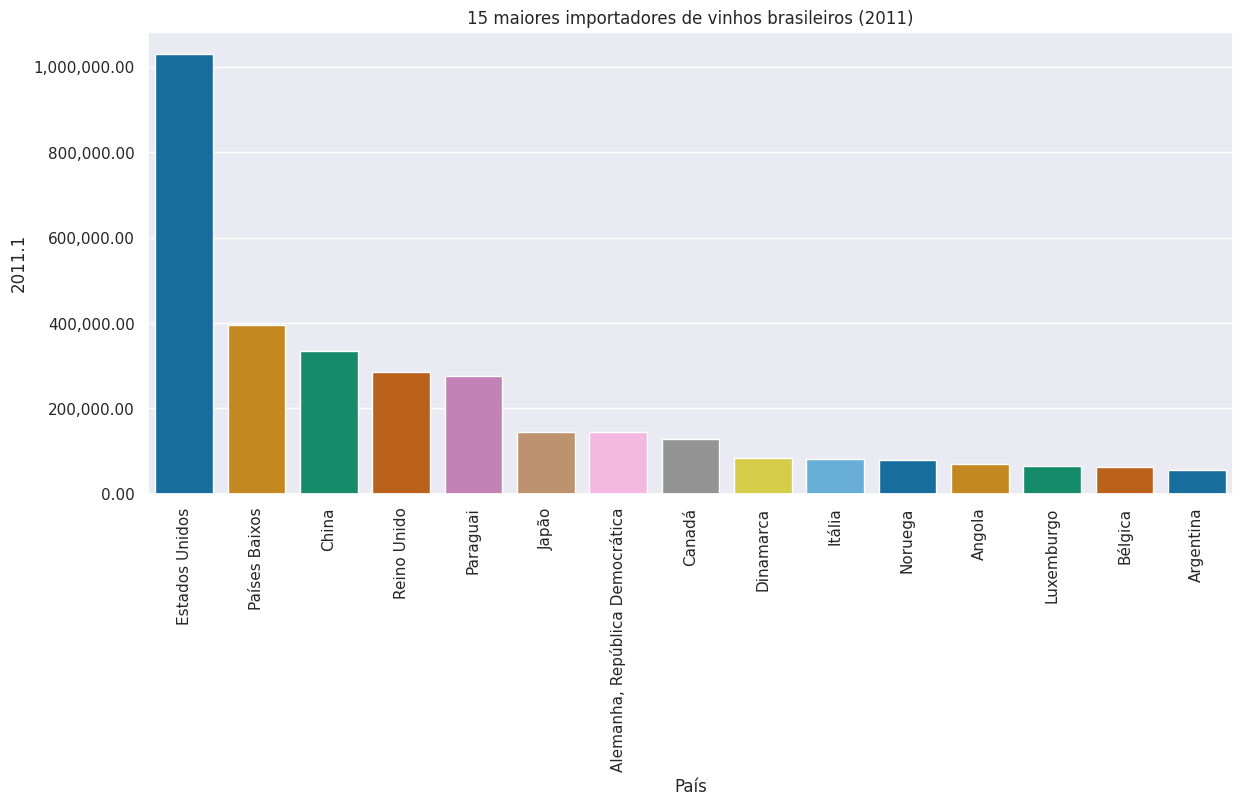

In [172]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2011_ord[:15], x='País', y="2011.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2011)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [173]:
# Pega as últimas 30 colunas
coluna = ['2012', '2012.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2012 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2012 = pd.concat([df_exp_vinhos_2012, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2012_ord = df_exp_vinhos_2012.sort_values(by="2012.1", ascending=False, ignore_index=True)

<ipython-input-174-7ac2fbc81983>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2012_ord[:15], x='País', y="2012.1",palette=paleta, dodge=False, legend=False)
<ipython-input-174-7ac2fbc81983>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2012_ord[:15], x='País', y="2012.1",palette=paleta, dodge=False, legend=False)


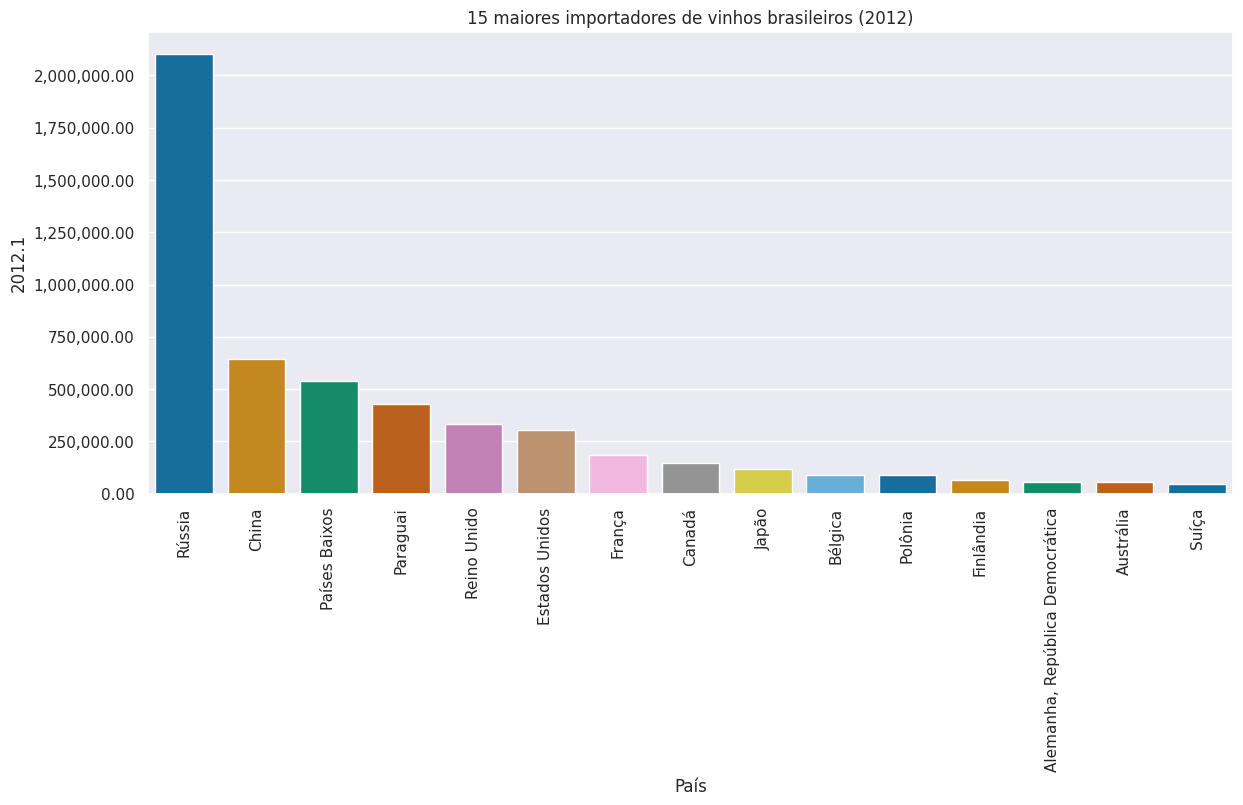

In [174]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2012_ord[:15], x='País', y="2012.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2012)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [175]:
# Pega as últimas 30 colunas
coluna = ['2013', '2013.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2013 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2013 = pd.concat([df_exp_vinhos_2013, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2013_ord = df_exp_vinhos_2013.sort_values(by="2013.1", ascending=False, ignore_index=True)

<ipython-input-176-be81adf8da79>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2013_ord[:15], x='País', y="2013.1",palette=paleta, dodge=False, legend=False)
<ipython-input-176-be81adf8da79>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2013_ord[:15], x='País', y="2013.1",palette=paleta, dodge=False, legend=False)


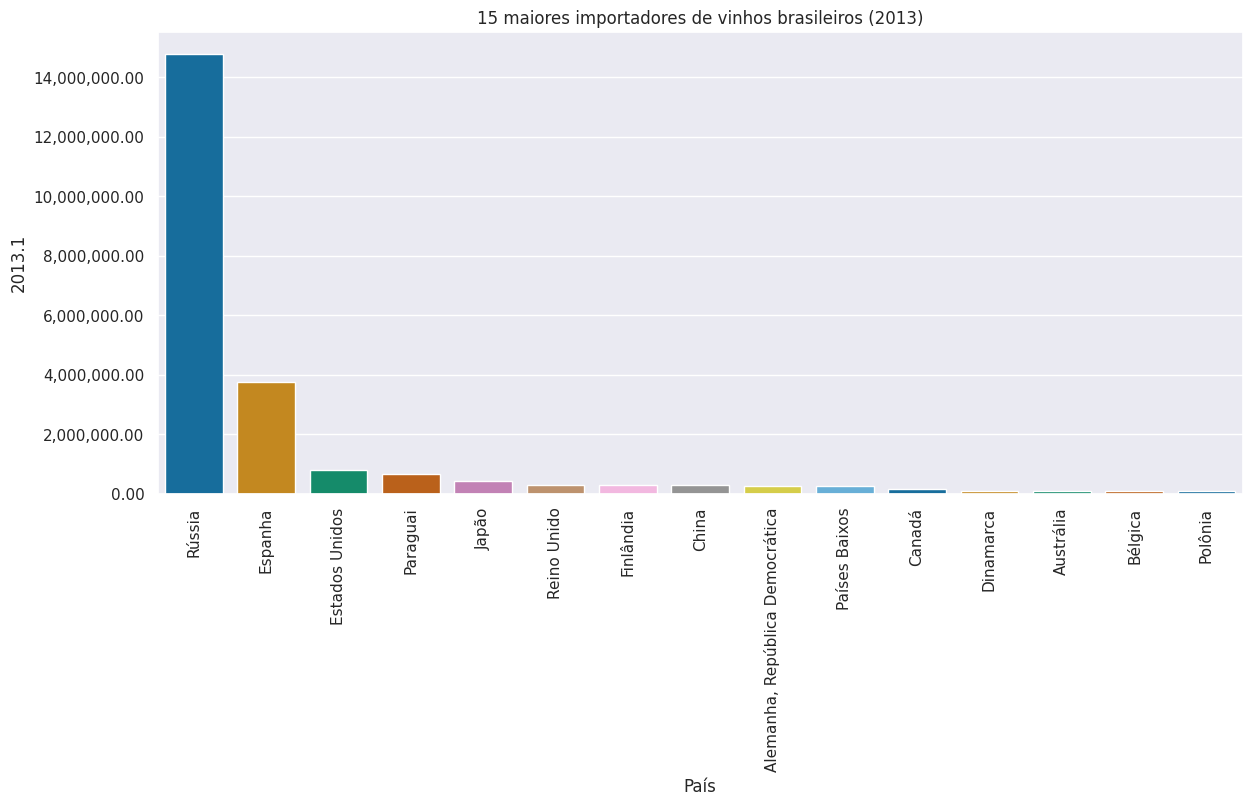

In [176]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2013_ord[:15], x='País', y="2013.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2013)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [177]:
# Pega as últimas 30 colunas
coluna = ['2014', '2014.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2014 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2014 = pd.concat([df_exp_vinhos_2014, df_exp_vinhos[coluna]], axis=1)

In [178]:
df_exp_vinhos_2014_ord = df_exp_vinhos_2014.sort_values(by="2014.1", ascending=False, ignore_index=True)

<ipython-input-179-efc85e71a718>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2014_ord[:15], x='País', y="2014.1",palette=paleta, dodge=False, legend=False)
<ipython-input-179-efc85e71a718>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2014_ord[:15], x='País', y="2014.1",palette=paleta, dodge=False, legend=False)


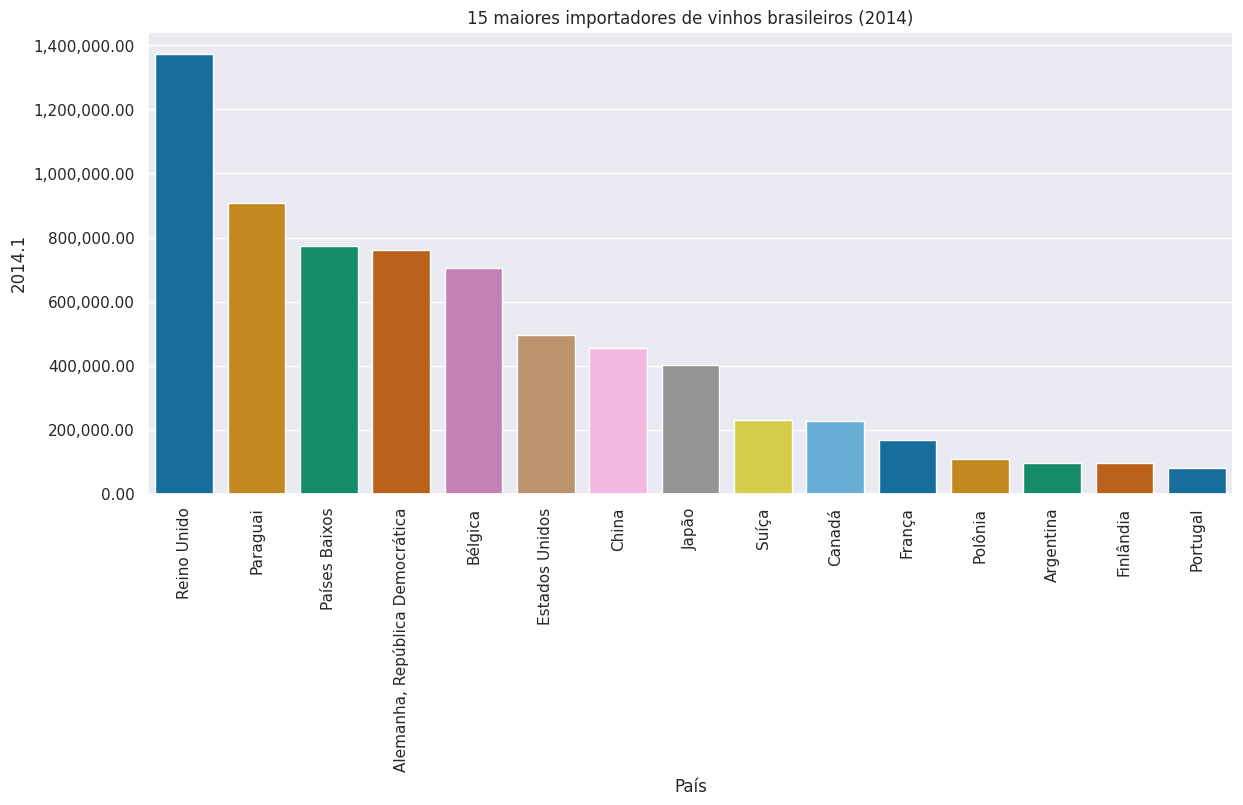

In [179]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2014_ord[:15], x='País', y="2014.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2014)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [180]:
# Pega as últimas 30 colunas
coluna = ['2015', '2015.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2015 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2015 = pd.concat([df_exp_vinhos_2015, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2015_ord = df_exp_vinhos_2015.sort_values(by="2015.1", ascending=False, ignore_index=True)

<ipython-input-181-088f855da57a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2015_ord[:15], x='País', y="2015.1",palette=paleta, dodge=False, legend=False)
<ipython-input-181-088f855da57a>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2015_ord[:15], x='País', y="2015.1",palette=paleta, dodge=False, legend=False)


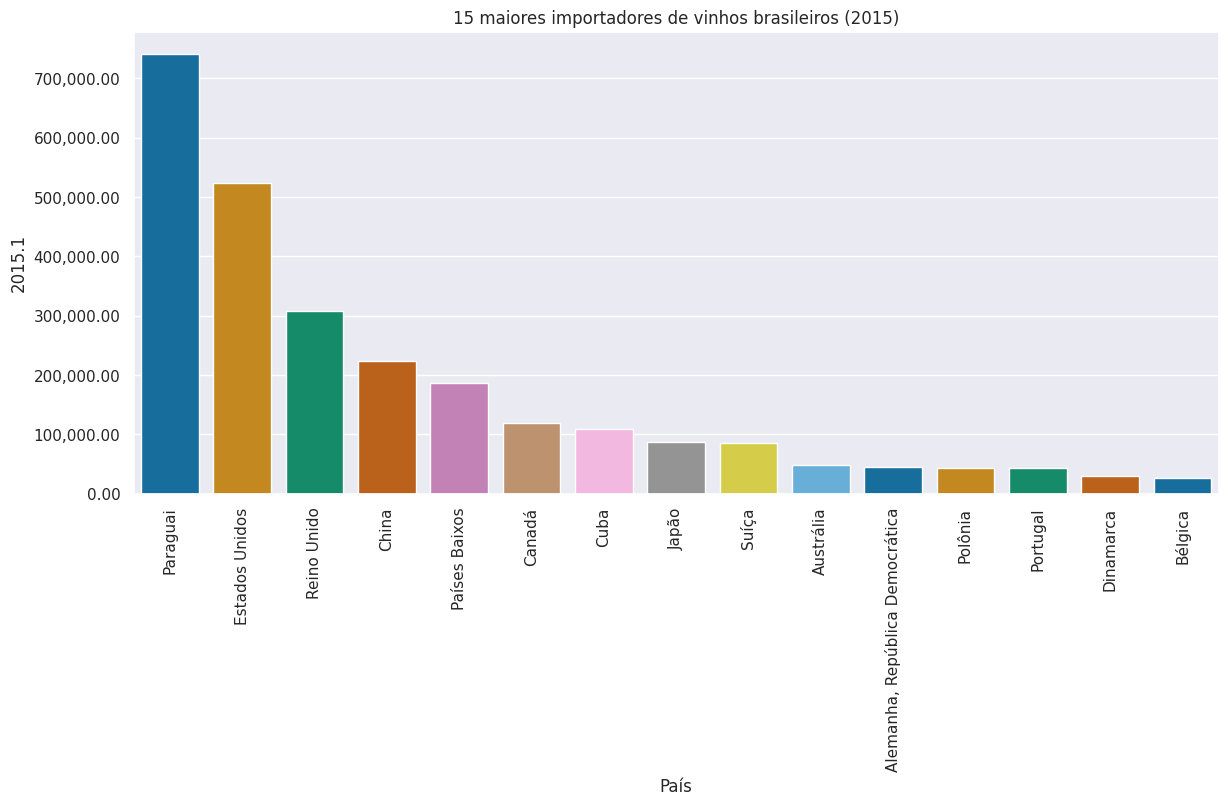

In [181]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2015_ord[:15], x='País', y="2015.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2015)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [182]:
# Pega as últimas 30 colunas
coluna = ['2016', '2016.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2016 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2016 = pd.concat([df_exp_vinhos_2016, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2016_ord = df_exp_vinhos_2016.sort_values(by="2016.1", ascending=False, ignore_index=True)

<ipython-input-183-eaa3415ed6cc>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2016_ord[:15], x='País', y="2016.1",palette=paleta, dodge=False, legend=False)
<ipython-input-183-eaa3415ed6cc>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2016_ord[:15], x='País', y="2016.1",palette=paleta, dodge=False, legend=False)


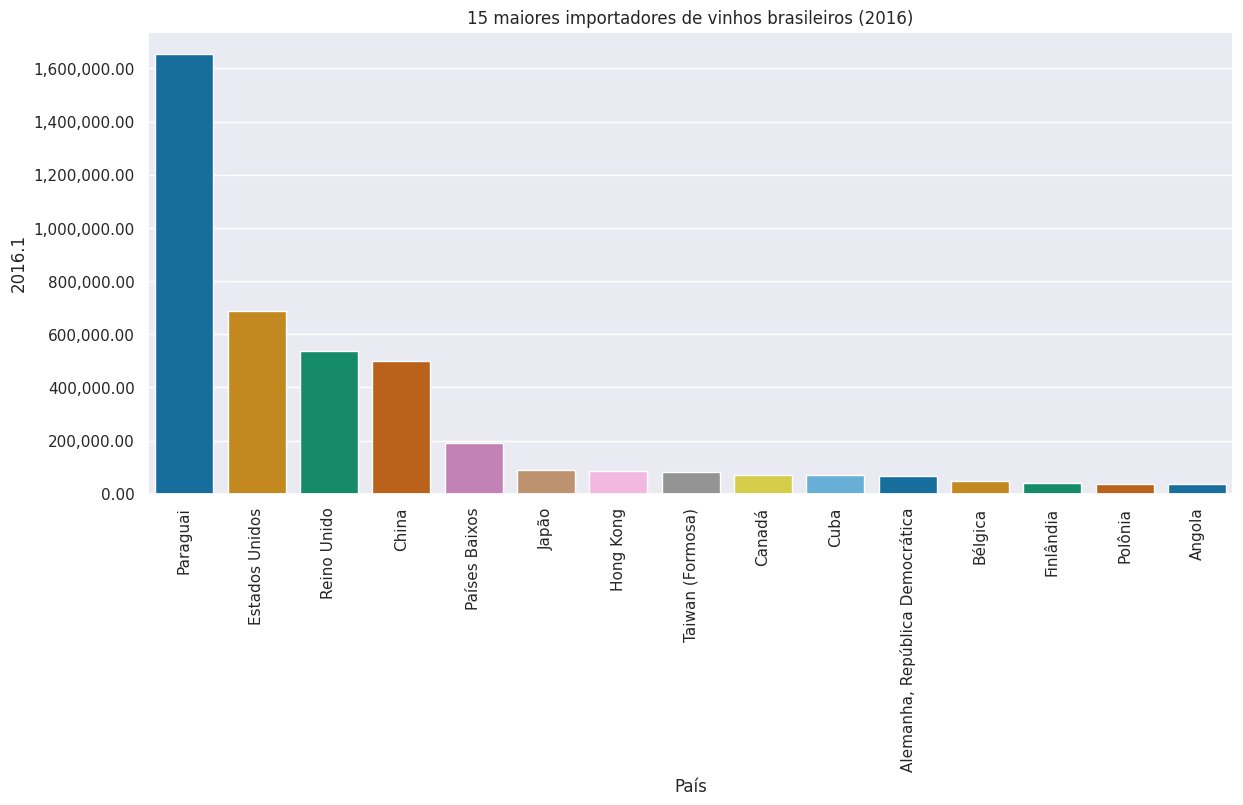

In [183]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2016_ord[:15], x='País', y="2016.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2016)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [184]:
# Pega as últimas 30 colunas
coluna = ['2017', '2017.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2017 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2017 = pd.concat([df_exp_vinhos_2016, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2017_ord = df_exp_vinhos_2017.sort_values(by="2017.1", ascending=False, ignore_index=True)

<ipython-input-185-7c8d166cdff1>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2017_ord[:15], x='País', y="2017.1",palette=paleta, dodge=False, legend=False)
<ipython-input-185-7c8d166cdff1>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2017_ord[:15], x='País', y="2017.1",palette=paleta, dodge=False, legend=False)


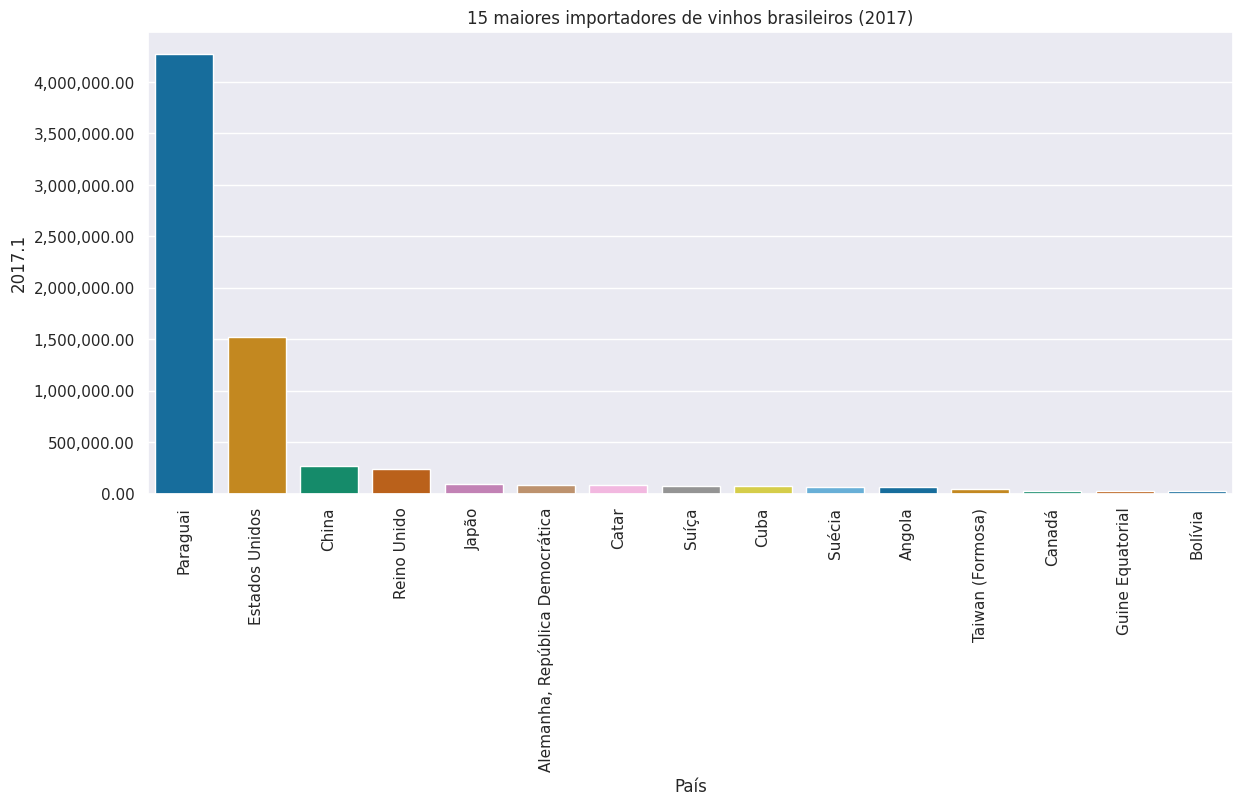

In [185]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2017_ord[:15], x='País', y="2017.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2017)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [186]:
# Pega as últimas 30 colunas
coluna = ['2018', '2018.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2018 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2018 = pd.concat([df_exp_vinhos_2018, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2018_ord = df_exp_vinhos_2018.sort_values(by="2018.1", ascending=False, ignore_index=True)

<ipython-input-187-71d4f2625f8d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)
<ipython-input-187-71d4f2625f8d>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)


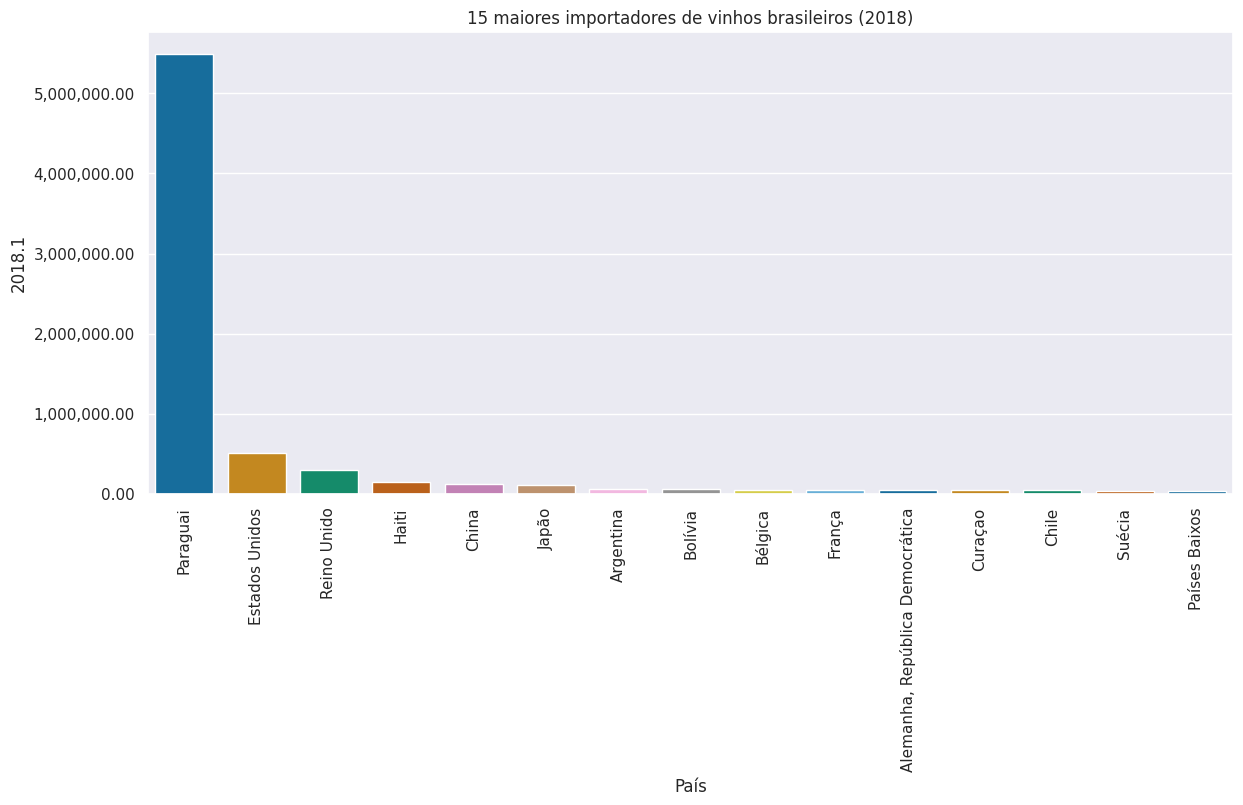

In [187]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2018)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [188]:
# Pega as últimas 30 colunas
coluna = ['2019', '2019.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2019 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2019 = pd.concat([df_exp_vinhos_2018, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2019_ord = df_exp_vinhos_2019.sort_values(by="2019.1", ascending=False, ignore_index=True)

<ipython-input-189-71d4f2625f8d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)
<ipython-input-189-71d4f2625f8d>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)


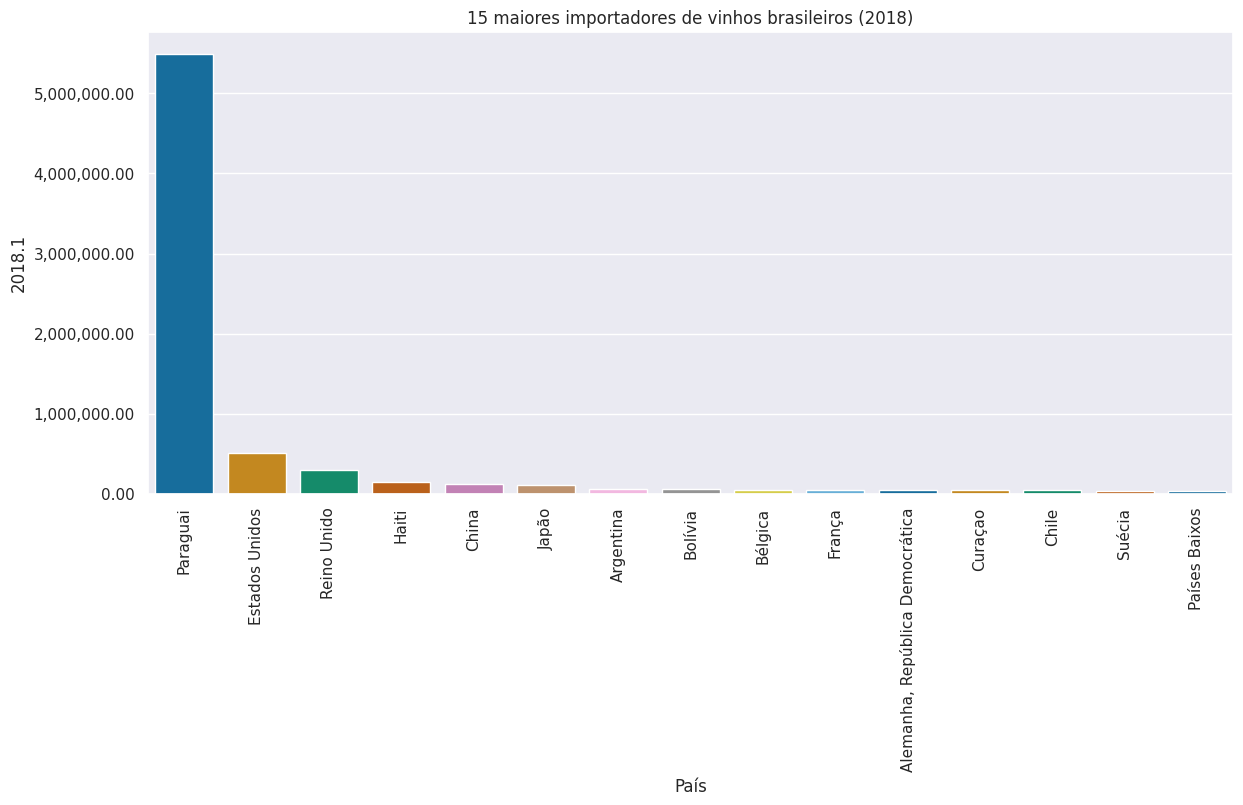

In [189]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2018)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [190]:
# Pega as últimas 30 colunas
coluna = ['2020', '2020.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2020 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2020 = pd.concat([df_exp_vinhos_2020, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2020_ord = df_exp_vinhos_2020.sort_values(by="2020.1", ascending=False, ignore_index=True)

<ipython-input-191-71d4f2625f8d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)
<ipython-input-191-71d4f2625f8d>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)


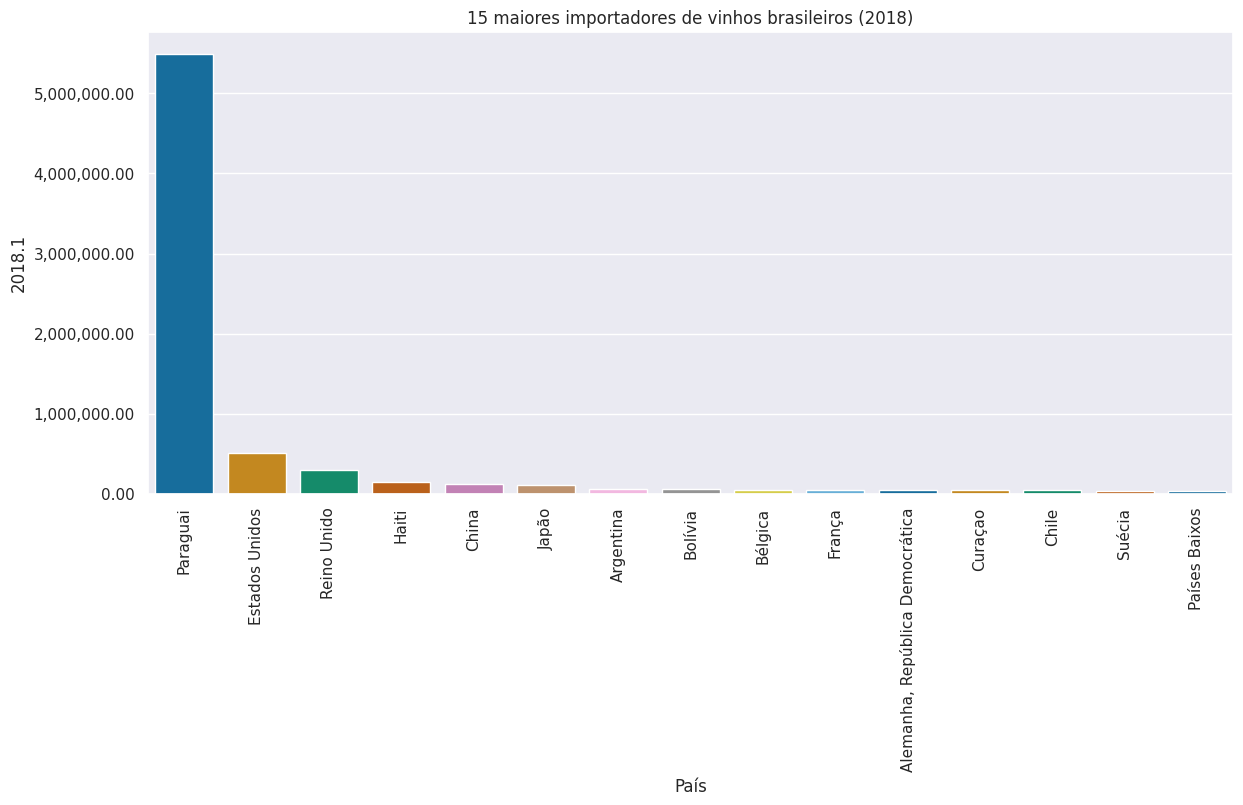

In [191]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2018_ord[:15], x='País', y="2018.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2018)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [192]:
# Pega as últimas 30 colunas
coluna = ['2021', '2021.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2021 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2021 = pd.concat([df_exp_vinhos_2020, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2021_ord = df_exp_vinhos_2021.sort_values(by="2021.1", ascending=False, ignore_index=True)

<ipython-input-193-e19ef5dd0901>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2021_ord[:15], x='País', y="2021.1",palette=paleta, dodge=False, legend=False)
<ipython-input-193-e19ef5dd0901>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2021_ord[:15], x='País', y="2021.1",palette=paleta, dodge=False, legend=False)


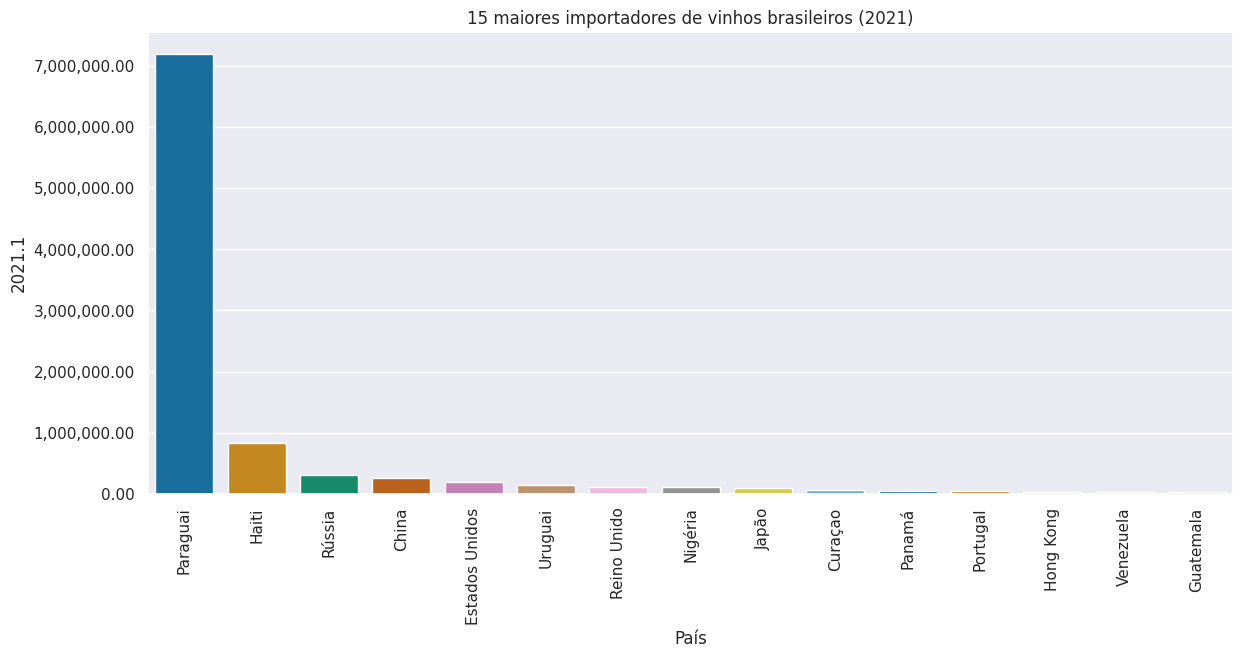

In [193]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2021_ord[:15], x='País', y="2021.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2021)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [194]:
# Pega as últimas 30 colunas
coluna = ['2022', '2022.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2022 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2022 = pd.concat([df_exp_vinhos_2022, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2022_ord = df_exp_vinhos_2022.sort_values(by="2022.1", ascending=False, ignore_index=True)

<ipython-input-195-be142abf60cc>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2022_ord[:15], x='País', y="2022.1",palette=paleta, dodge=False, legend=False)
<ipython-input-195-be142abf60cc>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2022_ord[:15], x='País', y="2022.1",palette=paleta, dodge=False, legend=False)


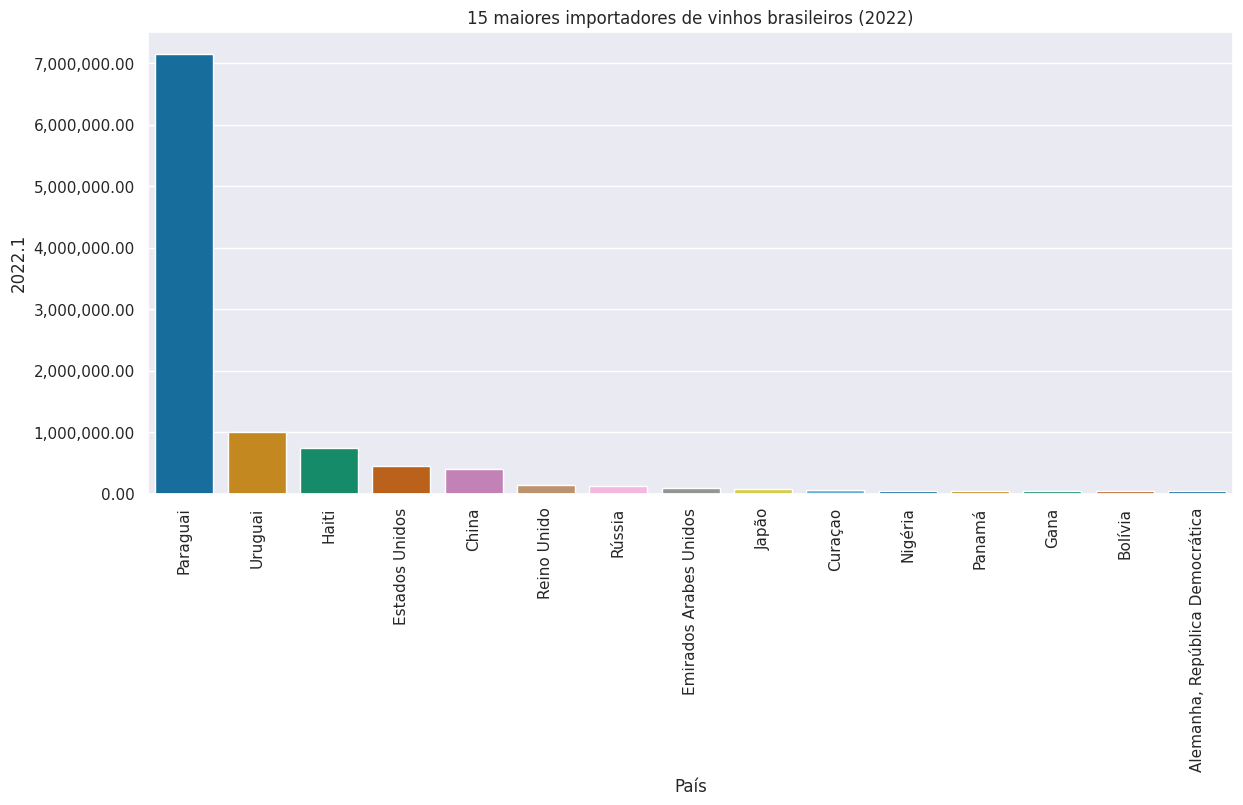

In [195]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2022_ord[:15], x='País', y="2022.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2022)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [196]:
# Pega as últimas 30 colunas
coluna = ['2023', '2023.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2023 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2023 = pd.concat([df_exp_vinhos_2023, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2023_ord = df_exp_vinhos_2023.sort_values(by="2023.1", ascending=False, ignore_index=True)

<ipython-input-197-00a74e573000>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2023_ord[:15], x='País', y="2023.1",palette=paleta, dodge=False, legend=False)
<ipython-input-197-00a74e573000>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2023_ord[:15], x='País', y="2023.1",palette=paleta, dodge=False, legend=False)


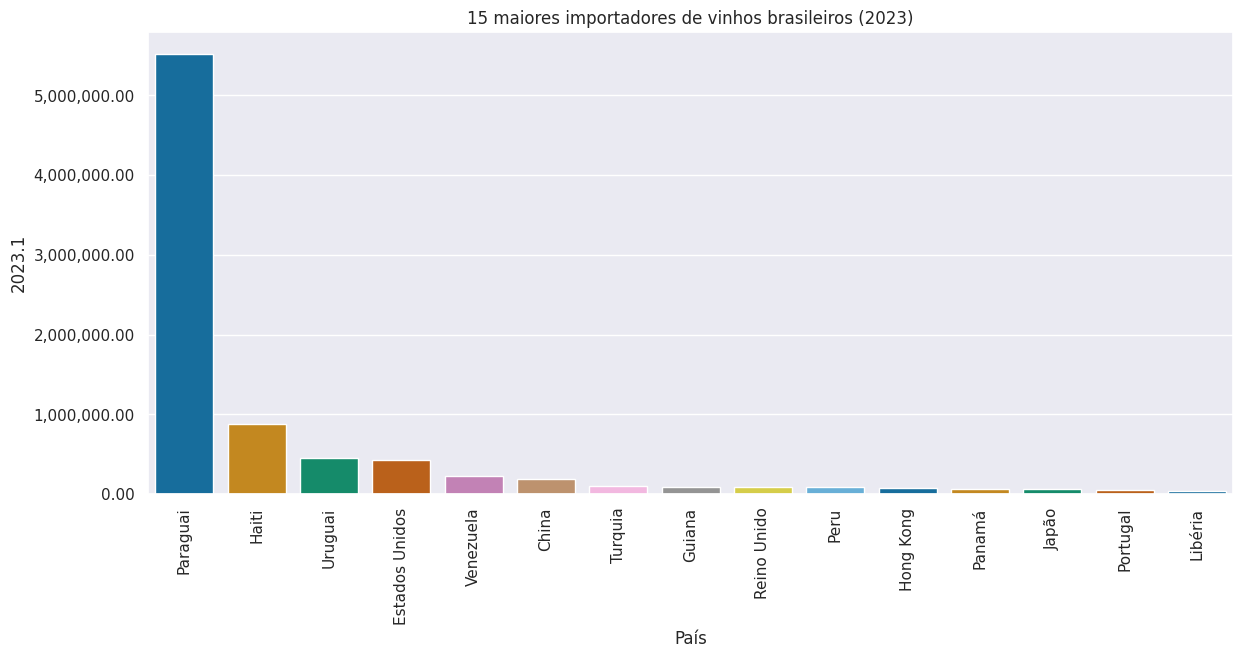

In [197]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2023_ord[:15], x='País', y="2023.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2023)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [198]:
# Pega as últimas 30 colunas
coluna = ['2024', '2024.1']
# Cria o novo dataframe
#seleciona as duas primeiras colunas
df_exp_vinhos_2024 = df_exp_vinhos[['País']].copy() #evita SettingWithCopyWarning
#concatena as 30 últimas
df_exp_vinhos_2024 = pd.concat([df_exp_vinhos_2024, df_exp_vinhos[coluna]], axis=1)
df_exp_vinhos_2024_ord = df_exp_vinhos_2024.sort_values(by="2024.1", ascending=False, ignore_index=True)

<ipython-input-199-e95c79a5154b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_exp_vinhos_2024_ord[:15], x='País', y="2024.1",palette=paleta, dodge=False, legend=False)
<ipython-input-199-e95c79a5154b>:4: UserWarning: 
The palette list has fewer values (14) than needed (15) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_exp_vinhos_2024_ord[:15], x='País', y="2024.1",palette=paleta, dodge=False, legend=False)


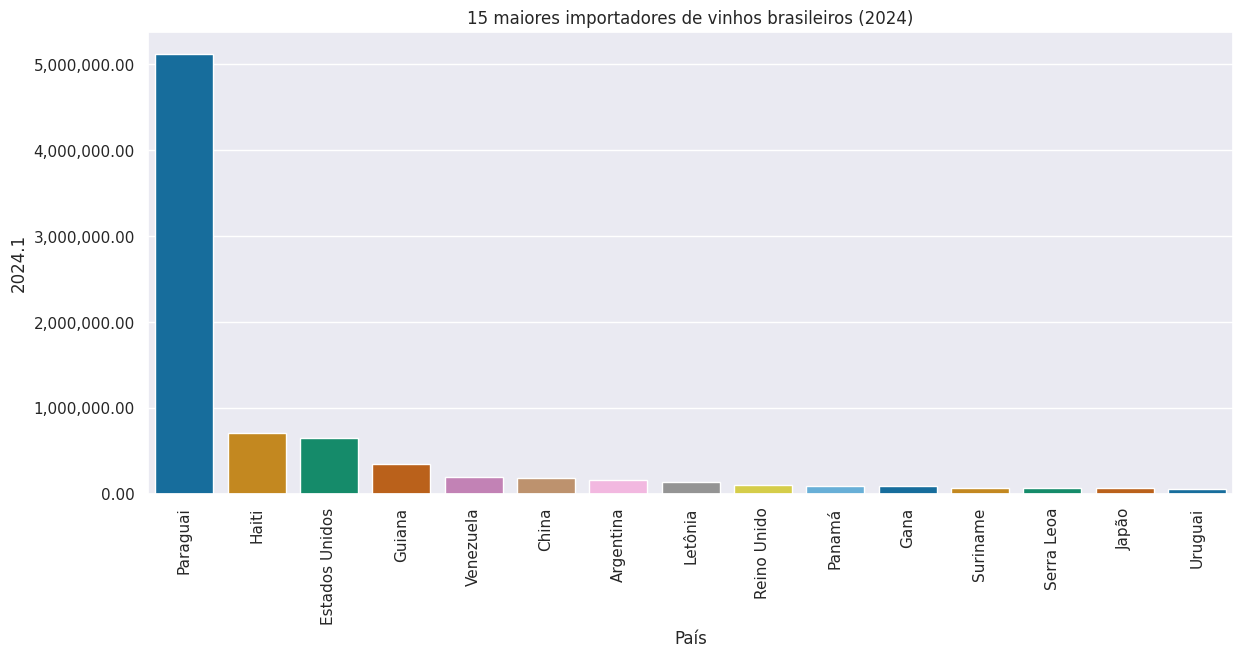

In [199]:
sns.set_theme()
paleta = sns.color_palette("colorblind", 14)
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_exp_vinhos_2024_ord[:15], x='País', y="2024.1",palette=paleta, dodge=False, legend=False)
plt.title('15 maiores importadores de vinhos brasileiros (2024)')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
plt.xticks(rotation=90)
plt.show()

In [200]:
df_comercio.head()

,id,control,Produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,98327606,114399031,118377367,116617910,94173324,108031792,139238614,...,206404427,209198468,166769622,176059959,177186273,180446489,215557931,210012238,187939996,187016848
1,2,vm_Tinto,Tinto,83300735,98522869,101167932,98196747,77167303,91528090,116407222,...,178250072,182028785,146646365,154309442,155115499,158519218,189573423,185653678,165067340,165097539
2,3,vm_Rosado,Rosado,107681,542274,7770851,8425617,8891367,7261777,11748047,...,1419855,1409002,1391942,1097426,1972944,1265435,1394901,1931606,2213723,2520748
3,4,vm_Branco,Branco,14919190,15333888,9438584,9995546,8114654,9241925,11083345,...,26734500,25760681,18731315,20653091,20097830,20661836,24589607,22426954,20658933,19398561
4,5,VINHO FINO DE MESA,VINHO FINO DE MESA,4430629,4840369,5602091,7202830,7571802,8848303,14095648,...,20424983,20141631,19630158,15874354,14826143,15684588,24310834,27080445,21533487,18589310


In [201]:
print(f'Tamanho do dataset {nome_da_variavel(df_comercio)}: {df_comercio.shape}')

Tamanho do dataset df_comercio: (62, 57)


df_producao.head()

In [202]:
df_producao.head()

,id,control,produto,1970,1971,1972,1973,1974,1975,1976,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,VINHO DE MESA,VINHO DE MESA,217208604,154264651,146953297,116710345,193875345,177401209,144565438,...,196173123,210308560,86319015,255015187,218375636,144629737,124200414,173899995,195031611,169762429
1,2,vm_Tinto,Tinto,174224052,121133369,118180926,88589019,146544484,144274134,118360170,...,157776363,169811472,75279191,1365957,188270142,121045115,103916391,146075996,162844214,139320884
2,3,vm_Branco,Branco,748400,1160500,1812367,243900,4138768,1441507,1871473,...,37438069,39557250,10727099,217527985,29229970,22032828,19568734,26432799,30198430,27910299
3,4,vm_Rosado,Rosado,42236152,31970782,26960004,27877426,43192093,31685568,24333795,...,958691,939838,312725,36121245,875524,1551794,715289,1391200,1988968,2531246
4,5,VINHO FINO DE MESA (VINIFERA),VINHO FINO DE MESA (VINIFERA),23899346,23586062,21078771,12368410,31644124,39424590,34500590,...,38464314,37148982,18070626,44537870,38707220,37615422,32516686,43474998,47511796,46268556


## Concatenando os DataFrames

Dataframe base

df_melted_comercio_vinho

df_melted_producao_vinho

Dataframe novo

df_melted_producao_comercio

In [203]:
print(df_melted_comercio_vinho.shape)
print(df_melted_producao_vinho.shape)


(84, 3)
(84, 3)


In [204]:
df_melted_comercio_vinho.tail()

,tipo_produto,ano,comercio_valor
261,vinho_mesa_rosado,2023,2520748
262,vinho_mesa_branco,2023,19398561
263,vinho_fino_mesa_tinto,2023,12450606
264,vinho_fino_mesa_rosado,2023,1214583
265,vinho_fino_mesa_branco,2023,4924121


In [205]:
df_melted_producao_vinho.tipo_produto.unique()

array(['vinho_mesa_tinto', 'vinho_mesa_rosado', 'vinho_mesa_branco',
       'vinho_fino_mesa_tinto', 'vinho_fino_mesa_rosado',
       'vinho_fino_mesa_branco'], dtype=object)

In [206]:
df_melted_comercio_vinho.tipo_produto.unique()

array(['vinho_mesa_tinto', 'vinho_mesa_rosado', 'vinho_mesa_branco',
       'vinho_fino_mesa_tinto', 'vinho_fino_mesa_rosado',
       'vinho_fino_mesa_branco'], dtype=object)

In [207]:
# Merge the two dataframes
df_melted_producao_comercio = pd.merge(df_melted_producao_vinho, df_melted_comercio_vinho, on=['tipo_produto', 'ano'], how='outer')

# Display the merged dataframe
print(df_melted_producao_comercio.head())


             tipo_produto   ano  producao  comercio_valor
0  vinho_fino_mesa_branco  2010    391280         5968959
1  vinho_fino_mesa_branco  2011    754305         4878930
2  vinho_fino_mesa_branco  2012    525903         6876128
3  vinho_fino_mesa_branco  2013    719723         8576915
4  vinho_fino_mesa_branco  2014   1200514         4905826


In [208]:
dados_safra = pd.read_csv('/content/drive/MyDrive/Documentos Pós Tech/Safra arrumada.csv')
dados_safra

,Safra,Cultura,UF,Solo,Outros manejos,Clima
0,PERENE,Uva Industrial,AL,Arenoso,Irrigado,Tropical
1,PERENE,Uva Industrial,AL,Argiloso,Irrigado,Tropical
2,PERENE,Uva Industrial,AL,Textura Média,Irrigado,Tropical
3,PERENE,Uva Industrial,BA,Arenoso,Irrigado,Tropical
4,PERENE,Uva Industrial,BA,Argiloso,Irrigado,Tropical
...,...,...,...,...,...,...
76,PERENE,Uva Industrial,SP,Textura Média,Irrigado,Tropical
77,PERENE,Uva Industrial,SP,Textura Média,Sequeiro,Subtropical Ameno
78,PERENE,Uva Industrial,TO,Arenoso,Irrigado,Tropical
79,PERENE,Uva Industrial,TO,Argiloso,Irrigado,Tropical


In [209]:
# Verifica as primeiras linhas do DataFrame
print(dados_safra.head())

# Lista todas as colunas
print(dados_safra.columns)

    Safra         Cultura  UF           Solo Outros manejos     Clima
0  PERENE  Uva Industrial  AL        Arenoso       Irrigado  Tropical
1  PERENE  Uva Industrial  AL       Argiloso       Irrigado  Tropical
2  PERENE  Uva Industrial  AL  Textura Média       Irrigado  Tropical
3  PERENE  Uva Industrial  BA        Arenoso       Irrigado  Tropical
4  PERENE  Uva Industrial  BA       Argiloso       Irrigado  Tropical
Index(['Safra', 'Cultura', 'UF', 'Solo', 'Outros manejos', 'Clima'], dtype='object')


In [210]:



# Contagem dos tipos de solo
solo_freq = dados_safra['Solo'].value_counts()

# Contagem dos Outros Manejos
manejos_freq = dados_safra['Outros manejos'].value_counts()


# Contagem dos tipos do clima
clima_freq = dados_safra['Clima'].value_counts()

# Exibe os resultados
print("\nFrequência por tipo de solo:\n", solo_freq)
print("\nFrequência por tipo de clima:\n", clima_freq)
print("\nFrequência por outros manejos:\n", manejos_freq)


Frequência por tipo de solo:
 Solo
Arenoso          27
Argiloso         27
Textura Média    27
Name: count, dtype: int64

Frequência por tipo de clima:
 Clima
Tropical             54
Subtropical Ameno    18
Subtropical Frio      9
Name: count, dtype: int64

Frequência por outros manejos:
 Outros manejos
Irrigado    54
Sequeiro    27
Name: count, dtype: int64


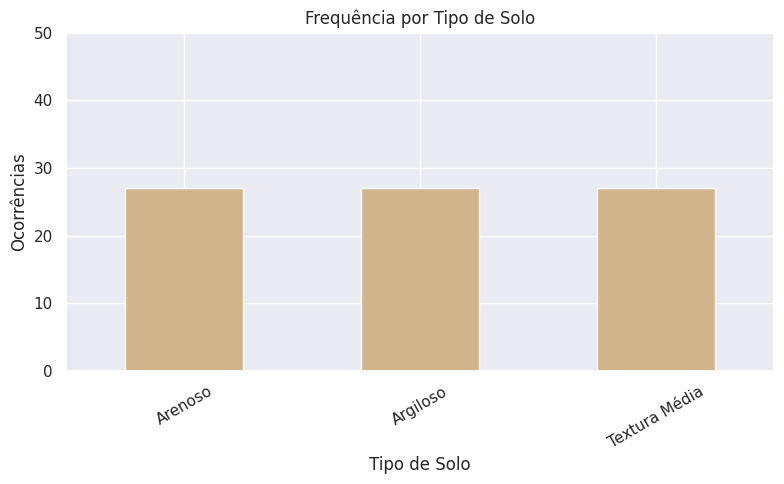

In [211]:
# Gráfico de frequência por tipo de solo
plt.figure(figsize=(8, 5))
solo_freq.plot(kind='bar', color='tan')
plt.title('Frequência por Tipo de Solo')
plt.xlabel('Tipo de Solo')
plt.ylabel('Ocorrências')
plt.xticks(rotation=30)
plt.tight_layout()
plt.ylim(0, 50)
plt.show()

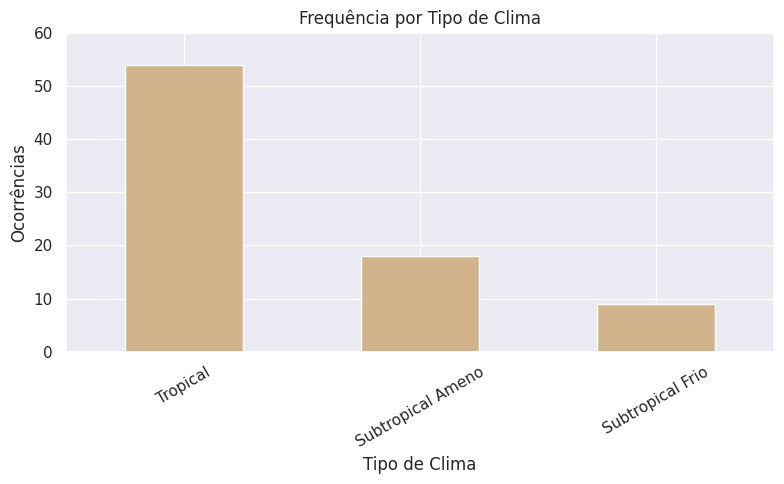

In [212]:
# Gráfico de frequência por tipo de Clima
plt.figure(figsize=(8, 5))
clima_freq.plot(kind='bar', color='tan')
plt.title('Frequência por Tipo de Clima')
plt.xlabel('Tipo de Clima')
plt.ylabel('Ocorrências')
plt.xticks(rotation=30)
plt.tight_layout()
plt.ylim(0, 60)
plt.show()

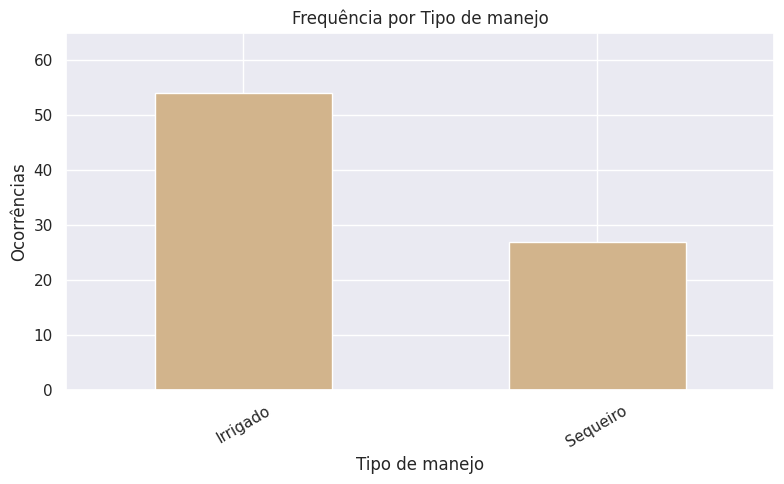

In [213]:
# Gráfico de frequência por tipo de Manejo
plt.figure(figsize=(8, 5))
manejos_freq.plot(kind='bar', color='tan')
plt.title('Frequência por Tipo de manejo')
plt.xlabel('Tipo de manejo')
plt.ylabel('Ocorrências')
plt.xticks(rotation=30)
plt.tight_layout()
plt.ylim(0, 65)
plt.show()

# **Manejo de Cultura Irrigada**:

### **Definição:**

A cultura irrigada é aquela que utiliza sistemas artificiais para fornecer água às plantas, garantindo um suprimento hídrico contínuo e controlado.

### **Objetivo:**

O objetivo principal é garantir a disponibilidade de água para as plantas em diferentes fases de desenvolvimento, mesmo em períodos de seca ou baixa pluviosidade.

### **Manejo:**

O manejo da irrigação envolve a seleção do sistema de irrigação mais adequado, a determinação da quantidade e frequência de irrigação, e o monitoramento do sistema para evitar perdas de água e garantir a eficiência.

### **Vantagens:**

Maior produtividade, menor impacto da seca, possibilidade de cultivo em áreas com menor disponibilidade de água, e maior controle sobre o desenvolvimento da planta.

### **Desvantagens:**

Maior custo de implementação e manutenção do sistema de irrigação, necessidade de disponibilidade de água (geralmente proveniente de recursos hídricos), e maior consumo de energia elétrica.

# Manejo de Cultura de Sequeiro:

### **Definição:**

A cultura de sequeiro é aquela que depende exclusivamente das chuvas para fornecer água às plantas, sem o uso de sistemas artificiais de irrigação.

### **Objetivo:**

O objetivo principal é adaptar o cultivo às condições climáticas locais, aproveitando ao máximo a água da chuva e minimizando os riscos de seca.

### **Manejo:**

O manejo da cultura de sequeiro envolve a escolha de culturas e variedades adaptadas às condições climáticas, a gestão do solo para aumentar a capacidade de retenção de água, e o planejamento da semeadura e colheita para aproveitar ao máximo as chuvas.

### **Vantagens:**

Menor custo de produção, menor consumo de energia, e maior adaptação às condições climáticas locais.

### **Desvantagens:**

Maior dependência das chuvas, maior risco de seca, menor produtividade em comparação com a cultura irrigada, e maior dificuldade em controlar o desenvolvimento da planta.

In [214]:
dados_propriedade = pd.read_excel('/content/drive/MyDrive/Documentos Pós Tech/Propriedades.xlsx', sheet_name='Sheet1')
# Verificar as primeiras linhas
print(dados_propriedade.head())

# Verificar informações básicas
print(dados_propriedade.info())

# Verificar valores únicos nas colunas importantes
print(dados_propriedade['UF'].unique())
print(dados_propriedade['Cultivar / Variedade'].unique())

   Ano (Safra)  Nº Colheita  UF Cultivar / Variedade  \
0         2025            1  MG           Chardonnay   
1         2025            1  MG           Vermentino   
2         2025            1  PR                Bordô   
3         2025            1  PR           BRS Carmem   
4         2025            1  PR   Cabernet Sauvignon   

   Área total das propriedades (ha)  Área total dos parreirais (ha)  \
0                             18.80                            0.52   
1                             18.80                            0.46   
2                            488.18                           14.52   
3                             41.30                            0.50   
4                             76.00                            0.02   

   Produção (Kg)  
0        1248.00  
1        1885.00  
2      315105.00  
3       11800.00  
4         850.00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38675 entries, 0 to 38674
Data columns (total 7 columns):
 #   Column   

In [215]:
# Contagem de ocorrências por estado
contagem_uf = dados_propriedade['UF'].value_counts()

# Média de área total por estado
media_area_uf = dados_propriedade.groupby('UF')['Área total das propriedades (ha)'].mean()

# Média de produção por estado
media_producao_uf = dados_propriedade.groupby('UF')['Produção (Kg)'].mean()

print("\nContagem por estado:")
print(contagem_uf)

print("\nMédia de área por estado:")
print(media_area_uf)

print("\nMédia de produção por estado:")
print(media_producao_uf)


Contagem por estado:
UF
RS    36911
SC      804
PR      309
BA      160
PE      159
SP      147
MG      115
GO       31
ES       22
DF       17
Name: count, dtype: int64

Média de área por estado:
UF
BA      479.61
DF     1710.38
ES       68.76
GO   609133.07
MG     3499.84
PE      454.58
PR       59.54
RS      444.98
SC    14927.37
SP      297.80
Name: Área total das propriedades (ha), dtype: float64

Média de produção por estado:
UF
BA    88143.00
DF     2710.29
ES     9198.59
GO     2692.81
MG     3349.82
PE   157971.09
PR    17259.83
RS   283849.12
SC    49940.33
SP     8512.37
Name: Produção (Kg), dtype: float64


In [216]:
# Contagem de ocorrências por cultivar
contagem_cultivar = dados_propriedade['Cultivar / Variedade'].value_counts()

# Top 10 cultivares mais comuns
top_cultivares = contagem_cultivar.head(10)

print("\nTop 10 cultivares mais comuns:")
print(top_cultivares)

# Média de área por cultivar
media_area_cultivar = dados_propriedade.groupby('Cultivar / Variedade')['Área total das propriedades (ha)'].mean().sort_values(ascending=False)

print("\nMédia de área por cultivar (top 10):")
print(media_area_cultivar.head(10))


Top 10 cultivares mais comuns:
Cultivar / Variedade
Bordô                 2252
Niágara Branca        1814
Niágara Rosada        1729
Isabel                1591
Cabernet Sauvignon    1115
Concord               1103
Isabel Precoce        1005
Merlot                1002
Chardonnay             954
Seibel 1077            811
Name: count, dtype: int64

Média de área por cultivar (top 10):
Cultivar / Variedade
Crimson Seedless     1887697.40
Syrah                  12829.42
Cabernet Franc          6974.75
Pinot Noir              5433.59
Isabel                  5280.58
Cabernet Sauvignon      4099.09
Lambrusco               3637.13
Montepulciano           3484.77
Coleções                3183.78
Albarossa               3132.29
Name: Área total das propriedades (ha), dtype: float64


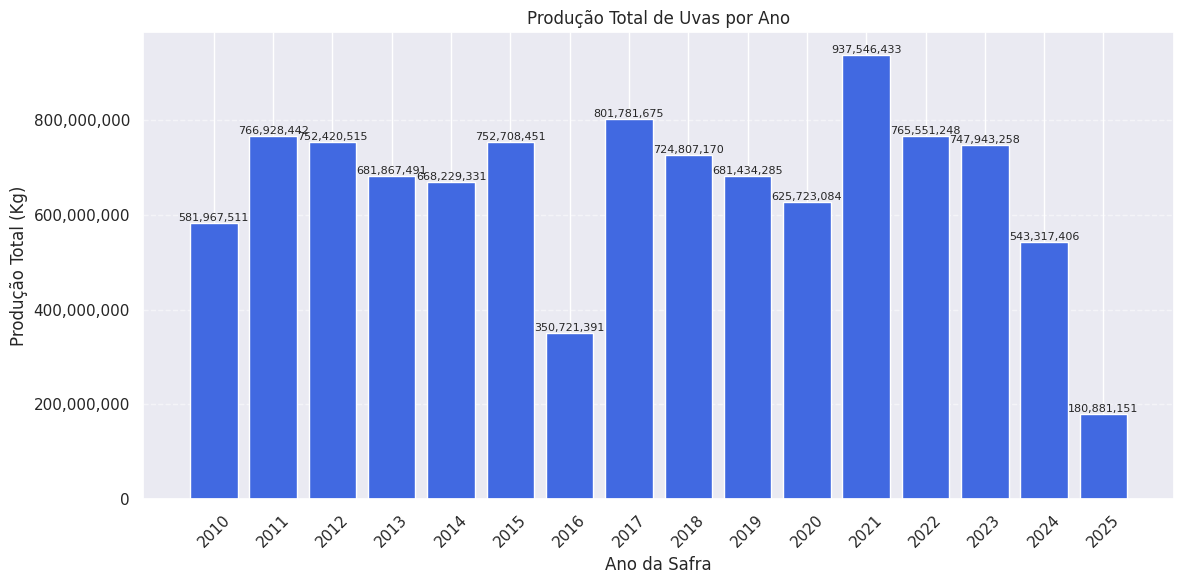

In [226]:
# Carregar o arquivo Excel
df = pd.read_excel("/content/drive/MyDrive/Documentos Pós Tech/Propriedades.xlsx", sheet_name="Sheet1")

# Agrupar por ano e somar a produção total
producao_anual = df.groupby("Ano (Safra)")["Produção (Kg)"].sum().reset_index()

# Plotar o gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(producao_anual["Ano (Safra)"], producao_anual["Produção (Kg)"], color='royalblue')

# Adicionar rótulos com os valores em cada barra (com separador de milhar)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:,.0f}',
             ha='center', va='bottom', fontsize=8)

# Configurações visuais
plt.title("Produção Total de Uvas por Ano")
plt.xlabel("Ano da Safra")
plt.ylabel("Produção Total (Kg)")
plt.xticks(producao_anual["Ano (Safra)"], rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

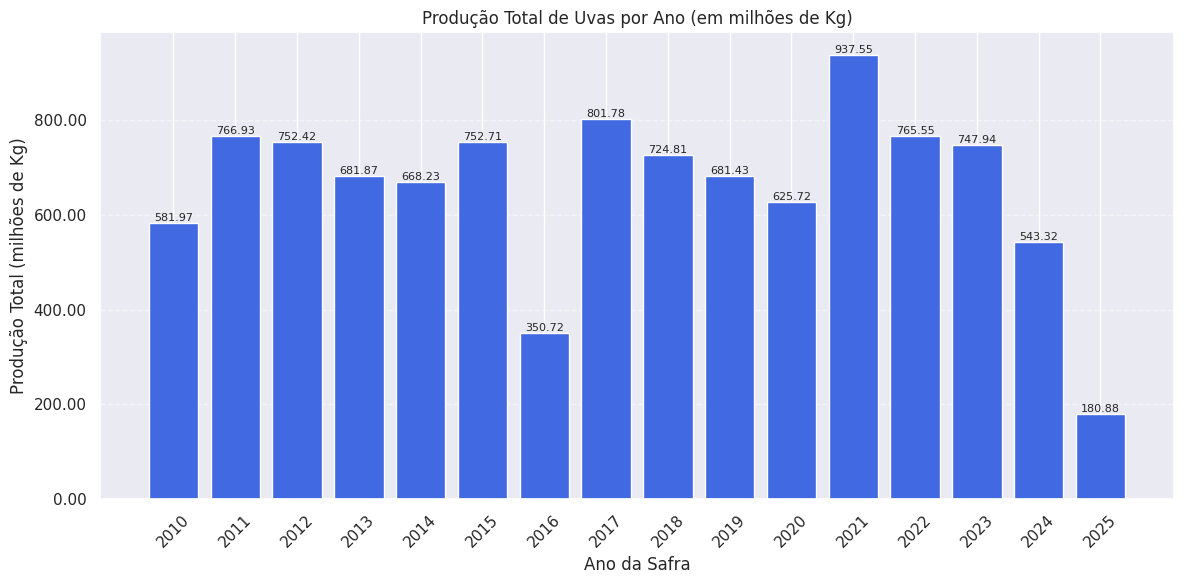

In [227]:
# Carregar o arquivo Excel
df = pd.read_excel("/content/drive/MyDrive/Documentos Pós Tech/Propriedades.xlsx", sheet_name="Sheet1")

# Agrupar por ano e somar a produção total
producao_anual = df.groupby("Ano (Safra)")["Produção (Kg)"].sum().reset_index()

# Converter a produção para milhões de Kg
producao_anual["Produção (Milhões Kg)"] = producao_anual["Produção (Kg)"] / 1_000_000

# Plotar o gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(producao_anual["Ano (Safra)"], producao_anual["Produção (Milhões Kg)"], color='royalblue')

# Adicionar rótulos com os valores em cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:,.2f}',
             ha='center', va='bottom', fontsize=8)

# Configurações visuais
plt.title("Produção Total de Uvas por Ano (em milhões de Kg)")
plt.xlabel("Ano da Safra")
plt.ylabel("Produção Total (milhões de Kg)")
plt.xticks(producao_anual["Ano (Safra)"], rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.2f}'))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

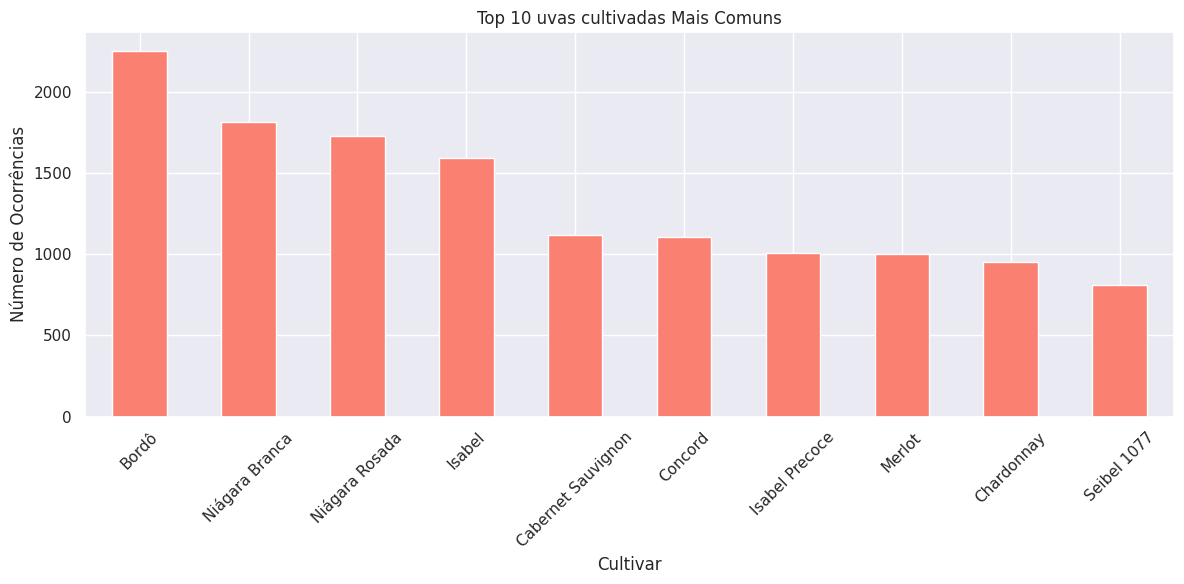

In [218]:
# Gráfico 2: Top 10 uvas cultivadas mais comuns
plt.figure(figsize=(12, 6))
top_cultivares.plot(kind='bar', color='salmon')
plt.title('Top 10 uvas cultivadas Mais Comuns')
plt.xlabel('Cultivar')
plt.ylabel('Número de Ocorrências')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



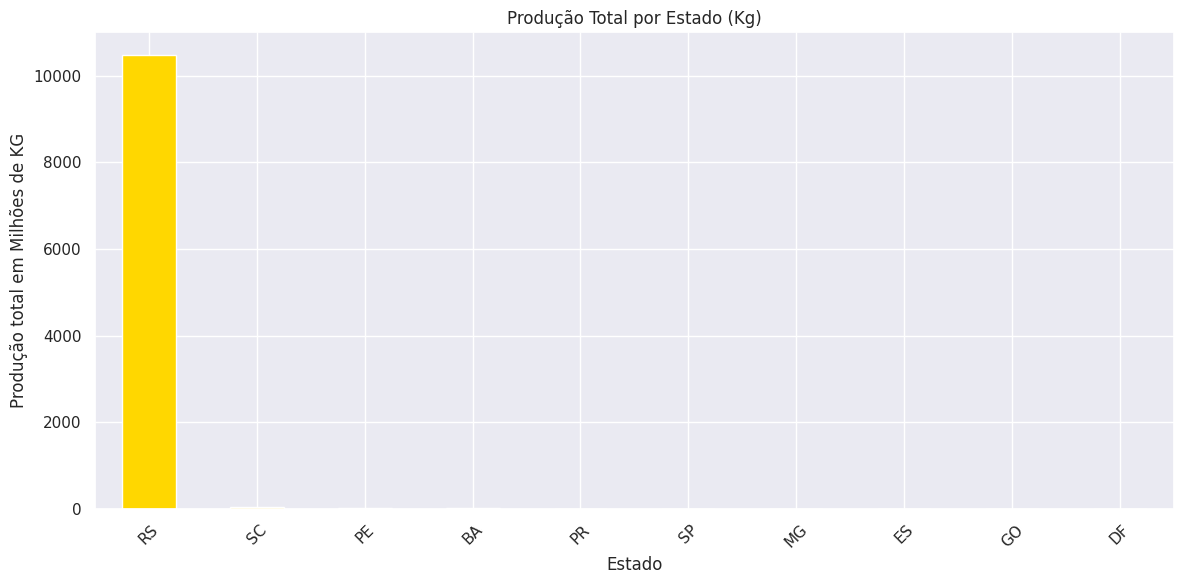

In [219]:

# Gráfico 3: Produção total por estado
producao_total_uf = dados_propriedade.groupby('UF')['Produção (Kg)'].sum().sort_values(ascending=False) / 1_000_000
plt.figure(figsize=(12, 6))
producao_total_uf.plot(kind='bar', color='gold')
plt.title('Produção Total por Estado (Kg)')
plt.xlabel('Estado')
plt.ylabel('Produção total em Milhões de KG')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [220]:
producao_total_uf_sem_rs = dados_propriedade[dados_propriedade['UF'] != 'RS']


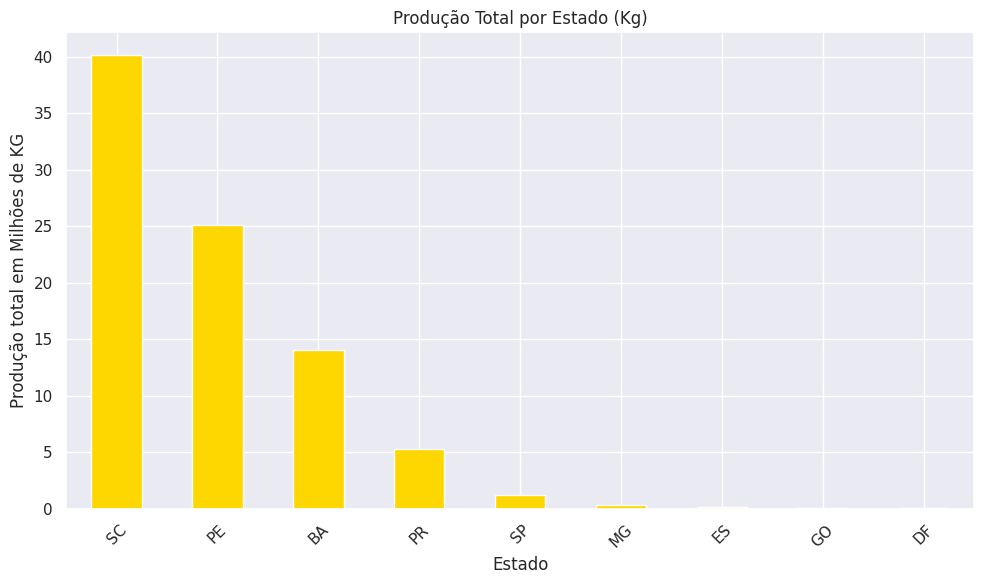

In [221]:
#produção total sem RS
producao_total_uf_sem_rs = dados_propriedade[dados_propriedade['UF'] != 'RS'].groupby('UF')['Produção (Kg)'].sum().sort_values(ascending=False) / 1_000_000
plt.figure(figsize=(10, 6))
producao_total_uf_sem_rs.plot(kind='bar', color='gold')
plt.title('Produção Total por Estado (Kg)')
plt.xlabel('Estado')
plt.ylabel('Produção total em Milhões de KG')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [222]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
